# Forecasting Philippine Employment Conditions as a Planning Signal for Clinics Offering Pre-Employment Medical Examination Services

**MBAN625 — Enterprise Data Analytics — Final Project**

**Group members**

- Amiel Emilio Verzola
- Ashley P. Esteban
- Karisse Joey P. Pabalan

---

## Research question

> What is the expected future trend in the Philippine employment rate, and how can that forecast
> support operational planning attention for clinics offering PEME services?

## Scope and analytical framing

PEME means Pre-Employment Medical Examination, a medical examination service offered by clinics.
This analysis does **not** forecast PEME demand, patient volume, or clinic revenue. It forecasts a
national macroeconomic indicator — the Philippine Employment Rate from the Philippine Statistics
Authority (PSA) — and translates that forecast into an **Employment Condition** reading and an
**Operational Attention** signal.

The link is indirect. Stronger national employment conditions are consistent with more hiring
activity in the economy, and PEME is often required before a new engagement. Employment conditions
can therefore serve as an external planning cue. They do not measure how many examinations any
clinic will perform.

**Conceptual chain used in this notebook**

```
Forecasted Employment Rate
 -> Employment Condition (statistical position vs recent norms)
 -> Operational Attention Signal (planning cue for the clinic)
 -> Management reviews actual clinic conditions
 -> Management decides whether action is required
```

Working rule: **the forecast supports attention; clinic records support action.**

## Analytical pathway

```
PSA Employment Rate
 -> data audit and frequency assessment
 -> modelling windows
 -> time-series structure assessment
 -> forecast models and validation
 -> residual diagnostics and uncertainty
 -> future forecast
 -> robustness and sensitivity checks
 -> employment condition + operational attention signal
```

## How to read this notebook

Each major step states **what** is examined and **why**, shows the executed result, then explains
**what it means** and **what it implies** for the next decision. Tables and figures are exported to
`outputs/`. The notebook remains the full analysis.


---

# 1. Environment and Reproducibility

#### Objective:

Set up the analytical environment, resolve file paths relative to the project root, and create the
output folders used later.

#### Rationale:

Reproducibility matters for this project. The notebook should run completely under
`Restart Kernel → Run All` without path edits or manual folder creation. Export helpers are kept
quiet during the analysis so artifact management does not interrupt the narrative; all generated
files are listed once at the end.


In [401]:
from pathlib import Path
import sys
import warnings

import numpy as np
import pandas as pd
import matplotlib
import matplotlib.pyplot as plt
import matplotlib.dates as mdates
from IPython.display import display

warnings.filterwarnings("ignore", category=FutureWarning)

pd.set_option("display.width", 160)
pd.set_option("display.max_columns", 60)
pd.set_option("display.float_format", lambda v: f"{v:,.4f}")

plt.rcParams.update({
    "figure.dpi": 110,
    "savefig.dpi": 200,
    "savefig.bbox": "tight",
    "font.size": 10,
    "axes.grid": True,
    "grid.alpha": 0.3,
    "axes.spines.top": False,
    "axes.spines.right": False,
})

ENV = pd.DataFrame(
    [
        ("Python", sys.version.split()[0]),
        ("pandas", pd.__version__),
        ("numpy", np.__version__),
        ("matplotlib", matplotlib.__version__),
    ],
    columns=["Component", "Version"],
)
print("Analytical environment")
display(ENV)

Analytical environment


,Component,Version
0,Python,3.13.0
1,pandas,2.3.3
2,numpy,2.3.5
3,matplotlib,3.10.8


In [402]:
# ---- Paths (relative to the project root; nothing machine-specific) ----------
DATA_DIR = Path("data")
RESULTS_DIR = Path("outputs") / "results"
FIGURES_DIR = Path("outputs") / "figures"
DOCS_DIR = Path("outputs") / "documentation"

for d in (DATA_DIR, RESULTS_DIR, FIGURES_DIR, DOCS_DIR):
    d.mkdir(parents=True, exist_ok=True)

DATA_FILE = DATA_DIR / "Rates Key Employment Indicators- April 2005 to June 2026.csv"

if not DATA_FILE.exists():
    raise FileNotFoundError(
        f"Expected dataset at '{DATA_FILE}'. Run this notebook from the project root "
        f"(the folder containing 'data/' and 'outputs/'). Current folder: {Path.cwd()}"
    )


def save_fig(fig, filename):
    """Save a figure already displayed above. Silent: artifacts are listed at the end."""
    fig.savefig(FIGURES_DIR / filename)


def save_table(df, filename, index=False):
    """Export a computed table. The object passed here is the same one displayed in the
    notebook, so the file can never disagree with the analysis."""
    df.to_csv(RESULTS_DIR / filename, index=index)


# ---- Shared accumulators ----------------------------------------------------
# Stages append to these as they run, and each export rewrites the file in full, so
# the CSVs always mirror exactly what the notebook computed.
DESCRIPTIVE_ROWS = []
ASSUMPTION_TESTS = []


def describe_scope(label, series, note=""):
    """Standard descriptive set for one series, recorded for later export."""
    s = pd.Series(series).dropna()
    row = {
        "Scope": label, "N": int(s.size), "Mean": s.mean(), "Median": s.median(),
        "Std_Dev": s.std(ddof=1), "Min": s.min(), "Q1": s.quantile(0.25),
        "Q3": s.quantile(0.75), "Max": s.max(), "Range": s.max() - s.min(),
        "IQR": s.quantile(0.75) - s.quantile(0.25), "Note": note,
    }
    DESCRIPTIVE_ROWS.append(row)
    return row


def record_test(stage, model, test, purpose, null_hypothesis, alt_hypothesis,
                statistic, p_value, alpha, conclusion, interpretation):
    """Record a formal test in the shared assumption-test register."""
    ASSUMPTION_TESTS.append({
        "Stage": stage, "Model": model, "Test": test, "Purpose": purpose,
        "Null_Hypothesis": null_hypothesis, "Alternative_Hypothesis": alt_hypothesis,
        "Statistic": statistic, "P_Value": p_value, "Significance_Level": alpha,
        "Conclusion": conclusion, "Interpretation": interpretation,
    })


print(f"Dataset: {DATA_FILE.as_posix()}")
print("Output directories ready.")

Dataset: data/Rates Key Employment Indicators- April 2005 to June 2026.csv
Output directories ready.


---

# 2. Data Provenance

#### Objective:

Document the source of the dataset and inspect the raw file before parsing.

#### Rationale:

Two file features can break the analysis if ignored. The first line is a title rather than the
column header, so a normal read would treat the header as data. Missing values are stored as a
literal full stop (`.`) rather than blank fields, which would force indicator columns to text and
block numerical work. Checking the raw lines first identifies both issues before parsing.


In [403]:
SOURCE_ORGANISATION = "Philippine Statistics Authority (PSA)"
SOURCE_DATABASE = "OpenSTAT - Labor Force Survey (LFS)"
SOURCE_TABLE = "Rates Key Employment Indicators: April 2005 to June 2026"
RETRIEVAL_DATE = "2026-09-05"
TARGET = "Employment Rate Both sexes"

data_source = pd.DataFrame(
    [
        ("Source organisation", SOURCE_ORGANISATION),
        ("Source database", SOURCE_DATABASE),
        ("Dataset / table", SOURCE_TABLE),
        ("Local filename", DATA_FILE.name),
        ("Relative path", DATA_FILE.as_posix()),
        ("Retrieval date", RETRIEVAL_DATE),
        ("Target variable", TARGET),
        ("Unit of measurement", "Percent of the labour force that is employed"),
        ("Geographic scope", "Philippines (national)"),
    ],
    columns=["Attribute", "Value"],
)
display(data_source)

,Attribute,Value
0,Source organisation,Philippine Statistics Authority (PSA)
1,Source database,OpenSTAT - Labor Force Survey (LFS)
2,Dataset / table,Rates Key Employment Indicators: April 2005 to...
3,Local filename,Rates Key Employment Indicators- April 2005 to...
4,Relative path,data/Rates Key Employment Indicators- April 20...
5,Retrieval date,2026-09-05
6,Target variable,Employment Rate Both sexes
7,Unit of measurement,Percent of the labour force that is employed
8,Geographic scope,Philippines (national)


In [404]:
# Inspect the physical file before parsing it.
raw_lines = DATA_FILE.read_text(encoding="utf-8-sig").splitlines()

print(f"Total physical lines in file : {len(raw_lines)}")
print()
print("Line 1 (title banner) :", raw_lines[0])
print("Line 2 (true header)  :", raw_lines[1][:110], "...")
print("Line 3 (first data)   :", raw_lines[2])
print("Last line             :", raw_lines[-1])
print()
print("Note: the '.' entries above are the source's missing-value code.")

Total physical lines in file : 288

Line 1 (title banner) : "Rates Key Employment Indicators: April 2005 to June 2026"
Line 2 (true header)  : "Year","Month","Labor Force Participation Rate Both sexes","Labor Force Participation Rate Male","Labor Force  ...
Line 3 (first data)   : "2005","January",.,.,.,.,.,.,.,.,.,.,.,.
Last line             : "2026","Annual",.,.,.,.,.,.,.,.,.,.,.,.

Note: the '.' entries above are the source's missing-value code.


The title line and the full-stop missing-value markers are shown above. The parsing step below
addresses both: `skiprows=1` drops the title line so the true header is used, and
`na_values=["."]` treats the full stop as missing.


In [405]:
# skiprows=1 discards the title banner; na_values='.' decodes the missing marker.
raw = pd.read_csv(DATA_FILE, skiprows=1, na_values=["."], encoding="utf-8-sig")

print(f"Parsed shape: {raw.shape[0]} rows x {raw.shape[1]} columns")
display(raw.head(6))

Parsed shape: 286 rows x 14 columns


,Year,Month,Labor Force Participation Rate Both sexes,Labor Force Participation Rate Male,Labor Force Participation Rate Female,Employment Rate Both sexes,Employment Rate Male,Employment Rate Female,Unemployment Rate Both sexes,Unemployment Rate Male,Unemployment Rate Female,Underemployment Rate Both sexes,Underemployment Rate Male,Underemployment Rate Female
0,2005,January,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
1,2005,February,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
2,2005,March,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
3,2005,April,64.8210,79.5170,50.2010,91.7200,91.6640,91.8080,8.2800,8.3360,8.1920,26.1350,28.8630,21.8440
4,2005,May,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
5,2005,June,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN


#### Findings:

The file has **286 rows and 14 columns**, covering four indicator families — labour force
participation, employment, unemployment, and underemployment — each by both sexes, male, and
female. The target variable is **`Employment Rate Both sexes`**.

Many `NaN` entries already appear in the early rows. The next section examines what those blanks
represent.


---

# 3. Data Audit

#### Objective:

Establish what the dataset contains and whether it is reliable enough for modelling.

#### Rationale:

Claims about missing data, duplication, validity, or outliers should come from executed checks, not
assumptions. The audit is therefore split into separate tests, each with its own result.


## 3.1 Structure, data types and completeness

#### Objective:

List each column with its data type and the count of non-missing values.

#### Rationale:

If the full-stop markers were not decoded correctly, indicator columns would appear as `object`
rather than `float64`. This check confirms that numerical parsing worked.


In [406]:
structure = pd.DataFrame({
    "Column": raw.columns,
    "Dtype": [str(t) for t in raw.dtypes],
    "Non_Null": raw.notna().sum().values,
    "Null": raw.isna().sum().values,
})
print(f"Rows: {len(raw)}   Columns: {raw.shape[1]}")
display(structure)

Rows: 286   Columns: 14


,Column,Dtype,Non_Null,Null
0,Year,int64,286,0
1,Month,object,286,0
2,Labor Force Participation Rate Both sexes,float64,150,136
3,Labor Force Participation Rate Male,float64,150,136
4,Labor Force Participation Rate Female,float64,150,136
5,Employment Rate Both sexes,float64,150,136
6,Employment Rate Male,float64,150,136
7,Employment Rate Female,float64,150,136
8,Unemployment Rate Both sexes,float64,150,136
9,Unemployment Rate Male,float64,150,136


#### Findings:

All twelve indicator columns are `float64`, so numerical parsing succeeded. Each column has
**151 populated values and 135 null values**. That is a large share of blanks, so their source needs
to be identified rather than assumed to be a defect.


## 3.2 Separation of aggregate rows from survey observations

#### Objective:

List the distinct values in the `Month` column and separate aggregate rows from survey months.

#### Rationale:

The file mixes two different record types. Most rows are calendar months, but each year also has a
row labelled `"Annual"` with a yearly summary. An annual total is not a survey observation. Keeping
those rows would insert artificial points between December and January and distort later
time-series calculations.


In [407]:
row_types = raw["Month"].value_counts().rename_axis("Month_label").to_frame("Rows")
display(row_types)

is_annual = raw["Month"].str.strip().str.lower() == "annual"
annual_rows = raw.loc[is_annual].copy()
calendar = raw.loc[~is_annual].copy()

print(f"'Annual' aggregate rows (excluded from the time series) : {is_annual.sum()}")
print(f"Calendar-month rows (retained)                          : {(~is_annual).sum()}")
print(f"Years spanned by the file                               : "
      f"{raw['Year'].min()} to {raw['Year'].max()}")

,Rows
Month_label,
January,22
February,22
March,22
April,22
May,22
June,22
July,22
August,22
September,22


'Annual' aggregate rows (excluded from the time series) : 22
Calendar-month rows (retained)                          : 264
Years spanned by the file                               : 2005 to 2026


#### Findings:

The dataset contains **22 `"Annual"` aggregate rows** — one for each year from 2005 to 2026 —
alongside **264 calendar-month rows**.

#### Implication for the next step:

The aggregate rows are excluded from the time series and are not used later. All following work
uses the calendar-month subset only.


## 3.3 Construction of the date index

#### Objective:

Combine `Year` and `Month` into a monthly date and check that the resulting dates form a complete
calendar.

#### Rationale:

Time is stored as an integer year and an English month name, which is hard to order or plot. Also,
observation frequency changes partway through the record, so each observation needs a real calendar
position. Plotting by row number would compress fifteen sparse years into the same width as five
dense years and misrepresent the history.

An assertion is included as a safeguard: if any month label fails to convert, execution stops rather
than silently dropping observations.


In [408]:
MONTH_TO_NUM = {
    "January": 1, "February": 2, "March": 3, "April": 4, "May": 5, "June": 6,
    "July": 7, "August": 8, "September": 9, "October": 10, "November": 11, "December": 12,
}

calendar["Month_Num"] = calendar["Month"].str.strip().map(MONTH_TO_NUM)
unmapped = int(calendar["Month_Num"].isna().sum())
assert unmapped == 0, f"{unmapped} month labels could not be mapped to a month number"

calendar["Date"] = pd.to_datetime(
    dict(year=calendar["Year"], month=calendar["Month_Num"], day=1)
)
calendar = calendar.sort_values("Date").reset_index(drop=True)

grid_start, grid_end = calendar["Date"].min(), calendar["Date"].max()
expected_grid = pd.date_range(grid_start, grid_end, freq="MS")

print(f"Calendar grid spans          : {grid_start:%b %Y} to {grid_end:%b %Y}")
print(f"Months expected in that span : {len(expected_grid)}")
print(f"Calendar-month rows present  : {len(calendar)}")
print(f"Calendar grid is complete    : {len(expected_grid) == len(calendar)}")
print("Month labels mapped without error.")

Calendar grid spans          : Jan 2005 to Dec 2026
Months expected in that span : 264
Calendar-month rows present  : 264
Calendar grid is complete    : True
Month labels mapped without error.


#### Findings:

All month labels converted without error. The rows span **January 2005 to December 2026**, and the
file has **264 rows for 264 possible months**, so the calendar scaffold is complete.

#### Interpretation:

Every calendar month has a row, but many of those rows have no measurement. The blanks are not
missing *rows*; they are **rows without measurements**. Section 3.5 examines why.


## 3.4 The target variable and the observed series

#### Objective:

Isolate months with an employment-rate measurement and inspect the start and end of that series.

#### Rationale:

The full calendar must be separated from the observed series — the months when the Labour Force
Survey actually reported a value. The frequency assessment in Section 4 depends on that distinction.

The target, `Employment Rate Both sexes`, is the percentage of the labour force that is employed.
Higher values mean a larger share of the workforce is employed.


In [409]:
observed = calendar.loc[calendar[TARGET].notna()].copy().reset_index(drop=True)

print(f"Target variable : {TARGET!r}")
print(f"Calendar-month rows        : {len(calendar)}")
print(f"Rows with an OBSERVED value: {len(observed)}")
print(f"Rows that are blank        : {int(calendar[TARGET].isna().sum())}")
print()
print(f"First observation : {observed['Date'].min():%B %Y}  =  "
      f"{observed[TARGET].iloc[0]:.3f}%")
print(f"Last  observation : {observed['Date'].max():%B %Y}  =  "
      f"{observed[TARGET].iloc[-1]:.3f}%")

print("\nFirst 8 observed values:")
display(observed[["Year", "Month", TARGET]].head(8))
print("Last 8 observed values:")
display(observed[["Year", "Month", TARGET]].tail(8))

Target variable : 'Employment Rate Both sexes'
Calendar-month rows        : 264
Rows with an OBSERVED value: 129
Rows that are blank        : 135

First observation : April 2005  =  91.720%
Last  observation : June 2026  =  95.140%

First 8 observed values:


,Year,Month,Employment Rate Both sexes
0,2005,April,91.7200
1,2005,July,92.2960
2,2005,October,92.6220
3,2006,January,91.8630
4,2006,April,91.7650
5,2006,July,91.8590
6,2006,October,92.6080
7,2007,January,92.1700


Last 8 observed values:


,Year,Month,Employment Rate Both sexes
121,2025,November,95.6280
122,2025,December,95.6280
123,2026,January,94.1940
124,2026,February,94.8920
125,2026,March,95.0110
126,2026,April,95.2940
127,2026,May,95.2070
128,2026,June,95.1400


#### Findings:

Of 264 calendar months, **129 contain a measurement** and **135 are empty**. The observed series
runs from **April 2005 (91.720%)** to **June 2026 (95.140%)**.

The early observations fall in April, July, and October, then January, April, July, and October —
a **quarterly** pattern. The recent observations run month after month — a **monthly** pattern.

#### Implication for the next step:

Observation frequency is not constant. That is an important structural feature of the data, and
Section 4 examines it systematically.


## 3.5 Missing values: defect or design characteristic

#### Objective:

Count absent values across columns and check whether blanks line up across every indicator.

#### Rationale:

Before treating the blank values as missing data, their source was examined. The two explanations
need opposite treatments. A failed measurement is a data-quality problem, and substitution might be
appropriate. A month with no survey reflects how the data were collected; filling those months in
would create observations that were never surveyed.

These explanations can be distinguished. If blanks line up across all twelve indicators, whole
months are missing at once, which happens when no survey was run. Scattered blanks in single
variables would instead suggest measurement failure.


In [410]:
indicator_cols = [c for c in raw.columns if c not in ("Year", "Month")]

missing_by_col = pd.DataFrame({
    "Variable": indicator_cols,
    "N_Missing": [int(calendar[c].isna().sum()) for c in indicator_cols],
    "N_Present": [int(calendar[c].notna().sum()) for c in indicator_cols],
})
missing_by_col["Pct_Missing"] = (
    100 * missing_by_col["N_Missing"] / len(calendar)
).round(2)
display(missing_by_col)

identical_pattern = all(
    calendar[c].isna().equals(calendar[TARGET].isna()) for c in indicator_cols
)
print(f"All {len(indicator_cols)} indicators share an IDENTICAL missing pattern: "
      f"{identical_pattern}")
print("-> Missingness is row-level (month not surveyed), not variable-level.")

,Variable,N_Missing,N_Present,Pct_Missing
0,Labor Force Participation Rate Both sexes,135,129,51.1400
1,Labor Force Participation Rate Male,135,129,51.1400
2,Labor Force Participation Rate Female,135,129,51.1400
3,Employment Rate Both sexes,135,129,51.1400
4,Employment Rate Male,135,129,51.1400
5,Employment Rate Female,135,129,51.1400
6,Unemployment Rate Both sexes,135,129,51.1400
7,Unemployment Rate Male,135,129,51.1400
8,Unemployment Rate Female,135,129,51.1400
9,Underemployment Rate Both sexes,135,129,51.1400


All 12 indicators share an IDENTICAL missing pattern: True
-> Missingness is row-level (month not surveyed), not variable-level.


In [411]:
first_obs_date, last_obs_date = observed["Date"].min(), observed["Date"].max()

leading_blank = calendar[calendar["Date"] < first_obs_date]
trailing_blank = calendar[calendar["Date"] > last_obs_date]
interior = calendar[(calendar["Date"] >= first_obs_date) & (calendar["Date"] <= last_obs_date)]
n_interior_blank = int(interior[TARGET].isna().sum())

missing_breakdown = pd.DataFrame(
    [
        ("Leading (before series begins)",
         f"{calendar['Date'].min():%b %Y} - {first_obs_date - pd.DateOffset(months=1):%b %Y}",
         len(leading_blank), "Survey series had not started"),
        ("Interior (within observed span)",
         f"{first_obs_date:%b %Y} - {last_obs_date:%b %Y}",
         n_interior_blank, "Months in which the LFS was not conducted"),
        ("Trailing (after last observation)",
         f"{last_obs_date + pd.DateOffset(months=1):%b %Y} - {calendar['Date'].max():%b %Y}",
         len(trailing_blank), "Future months; not yet published"),
    ],
    columns=["Blank_Type", "Period", "N_Months", "Explanation"],
)
display(missing_breakdown)

print("None of these categories represents a failed or corrupted measurement.")
print("Decision: retain as unobserved. NO imputation of the target series.")

,Blank_Type,Period,N_Months,Explanation
0,Leading (before series begins),Jan 2005 - Mar 2005,3,Survey series had not started
1,Interior (within observed span),Apr 2005 - Jun 2026,126,Months in which the LFS was not conducted
2,Trailing (after last observation),Jul 2026 - Dec 2026,6,Future months; not yet published


None of these categories represents a failed or corrupted measurement.
Decision: retain as unobserved. NO imputation of the target series.


#### Findings:

All twelve indicators show the **same** blank pattern: every empty month is empty for every
variable. The 135 blanks break down as follows.

| Category | Count | Explanation |
|---|---|---|
| Leading (January–March 2005) | 3 | The survey series had not started |
| Interior | **126** | Months when the survey was not conducted |
| Trailing (July–December 2026) | 6 | Future months, not yet published |

#### Interpretation:

The dataset contains **no true missing values** in the usual sense. The blanks reflect survey
timing, not failed measurements.

#### Implication for the next step:

The target series is not imputed. Interpolating the 126 interior blanks would invent more than a
decade of unsurveyed months and distort autocorrelation, variance, and stationarity results used
later for model choice. The trade-off is a smaller set of evenly spaced monthly observations for
modelling.


## 3.6 Duplication

#### Objective:

Check for duplication at four levels of strictness.

#### Rationale:

The four checks answer different questions. A duplicated row is a file defect and should be removed.
The same employment rate in two different months is ordinary and should not trigger deletion.


In [412]:
dup_full = int(raw.duplicated().sum())
dup_key = int(raw.duplicated(subset=["Year", "Month"]).sum())
dup_date = int(observed["Date"].duplicated().sum())
dup_date_val = int(observed.duplicated(subset=["Date", TARGET]).sum())

duplicate_checks = pd.DataFrame(
    [
        ("Fully duplicated rows (all 14 columns)", dup_full),
        ("Duplicated (Year, Month) keys", dup_key),
        ("Duplicated observation dates", dup_date),
        ("Duplicated (Date, target) pairs", dup_date_val),
    ],
    columns=["Duplicate_Check", "Count"],
)
display(duplicate_checks)

repeated_value = observed[observed[TARGET].duplicated(keep=False)]
print(f"Distinct dates that happen to share the same target VALUE: {len(repeated_value)}")
if len(repeated_value):
    display(
        repeated_value[["Date", TARGET]]
        .assign(Date=lambda d: d["Date"].dt.strftime("%b %Y"))
        .reset_index(drop=True)
    )
    print("These are separate survey months whose rates coincide. They are genuine")
    print("observations, NOT duplicate records, and are retained.")

,Duplicate_Check,Count
0,Fully duplicated rows (all 14 columns),0
1,"Duplicated (Year, Month) keys",0
2,Duplicated observation dates,0
3,"Duplicated (Date, target) pairs",0


Distinct dates that happen to share the same target VALUE: 2


,Date,Employment Rate Both sexes
0,Nov 2025,95.6280
1,Dec 2025,95.6280


These are separate survey months whose rates coincide. They are genuine
observations, NOT duplicate records, and are retained.


#### Findings:

**No duplication appears under any definition tested** — no duplicated rows, no duplicated
year-and-month keys, and no duplicated dates.

Two months share the same value: November and December 2025 both record 95.628%. These are different
survey months with matching results, which is unsurprising for a series reported to three decimals.
Both are kept.

#### Implication for the next step:

No records need to be removed for duplication.


## 3.7 Validity and internal consistency

#### Objective:

Check that values are valid percentages, and check the arithmetic link between the Employment Rate
and the Unemployment Rate.

#### Rationale:

The second check is stronger. The two rates are complementary shares of the same labour force, so
they should sum to 100. Because the unemployment column is not used to build modelling objects, this
is an independent integrity check: a truncated download, column misalignment, or bad decimal parsing
would break the relationship.


In [413]:
target_values = observed[TARGET]

out_of_range = int(((target_values < 0) | (target_values > 100)).sum())
non_finite = int((~np.isfinite(target_values)).sum())

complement = observed[TARGET] + observed["Unemployment Rate Both sexes"]
max_deviation = float((complement - 100).abs().max())

validity_checks = pd.DataFrame(
    [
        ("Values outside the valid range [0, 100]", out_of_range),
        ("Non-finite values (inf / NaN)", non_finite),
    ],
    columns=["Validity_Check", "Count"],
)
display(validity_checks)

print(f"Observed range: {target_values.min():.3f}% to {target_values.max():.3f}%")
print(f"Employment Rate + Unemployment Rate: min={complement.min():.4f}, "
      f"max={complement.max():.4f}")
print(f"Maximum absolute deviation from 100: {max_deviation:.6f}")
print("-> The extract is internally consistent; no parsing or download corruption.")

,Validity_Check,Count
0,"Values outside the valid range [0, 100]",0
1,Non-finite values (inf / NaN),0


Observed range: 82.395% to 96.926%
Employment Rate + Unemployment Rate: min=100.0000, max=100.0000
Maximum absolute deviation from 100: 0.000000
-> The extract is internally consistent; no parsing or download corruption.


#### Findings:

No values fall outside [0, 100]. The observed range is **82.395% to 96.926%**. The Employment Rate
and Unemployment Rate sum to 100 across all 129 observations, with a **maximum absolute deviation of
0.000000**.

#### Interpretation:

The employment and unemployment rates summed to 100% for all observations. This provides an
additional check that the values were parsed correctly and are internally consistent.


## 3.8 Outlier assessment

#### Objective:

Flag unusual observations using two complementary rules.

#### Rationale:

Unusual points are identified, not automatically removed. In macroeconomic series an extreme value
is often a real event. An unusual employment rate is more likely to reflect an economic shock than a
typing error.

Two rules are used. The interquartile-range fence flags values far from the middle half of the data.
The modified z-score compares each point to the **median** and the **median absolute deviation**,
which is useful because one extreme point can inflate a standard deviation enough to hide itself.


In [414]:
q1, q3 = target_values.quantile([0.25, 0.75])
iqr = q3 - q1
fence_lo, fence_hi = q1 - 1.5 * iqr, q3 + 1.5 * iqr

median = target_values.median()
mad = (target_values - median).abs().median()
mod_z = 0.6745 * (target_values - median) / mad

print(f"Q1 = {q1:.3f}   Q3 = {q3:.3f}   IQR = {iqr:.3f}")
print(f"IQR fences: [{fence_lo:.3f}, {fence_hi:.3f}]")
print(f"Median = {median:.3f}   MAD = {mad:.3f}")

flagged = observed.assign(Modified_Z=mod_z).loc[
    (target_values < fence_lo) | (target_values > fence_hi) | (mod_z.abs() > 3.5)
]
outlier_screen = (
    flagged[["Date", TARGET, "Modified_Z"]]
    .assign(Date=lambda d: d["Date"].dt.strftime("%b %Y"))
    .rename(columns={TARGET: "Employment_Rate"})
    .reset_index(drop=True)
)
print(f"\nPoints flagged by IQR fence or |modified z| > 3.5: {len(outlier_screen)}")
display(outlier_screen)

Q1 = 92.718   Q3 = 95.412   IQR = 2.694
IQR fences: [88.677, 99.453]
Median = 94.228   MAD = 1.348

Points flagged by IQR fence or |modified z| > 3.5: 1


,Date,Employment_Rate,Modified_Z
0,Apr 2020,82.3950,-5.9209


#### Findings:

One point is flagged: **April 2020, at 82.395%**, with a modified z-score of **−5.92**. That places
the observation about six robust deviations below the typical value.

#### Interpretation:

April 2020 is the month of nationwide COVID-19 movement restrictions in the Philippines. The value
is a real survey outcome, not a recording error. It is the most extreme point because it is the most
severe labour-market shock in the record.

#### Implication for the next step:

The point is kept. Removing it would erase the largest labour-market event in the series and make
conditions look more stable than they were. Its influence is handled later through modelling-window
choice and sensitivity checks, not by deleting the pandemic.


## 3.9 Consolidated data-quality evidence

#### Objective:

Combine the earlier checks into one exported table.

#### Rationale:

A compact quality summary is useful for the report. Building it from variables already computed keeps
the export aligned with the executed analysis.


In [415]:
data_quality_summary = pd.DataFrame(
    [
        dict(Check="Aggregate rows excluded", Variable_or_Scope="Month == 'Annual'",
             Method="Label filter on the Month column",
             Result=f"{int(is_annual.sum())} annual summary rows separated from "
                    f"{int((~is_annual).sum())} calendar-month rows",
             Count=int(is_annual.sum()), Decision="Exclude from the time series",
             Reason="Annual figures are summaries, not survey observations"),
        dict(Check="Calendar grid completeness", Variable_or_Scope="Date index",
             Method="Compare row count with a complete monthly date range",
             Result=f"{len(calendar)} rows over a {len(expected_grid)}-month span; "
                    f"complete={len(expected_grid) == len(calendar)}",
             Count=len(calendar), Decision="Use as the calendar scaffold",
             Reason="Every calendar month is represented as a row"),
        dict(Check="Missing values (target)", Variable_or_Scope=TARGET,
             Method="Count NaN after decoding '.' as missing",
             Result=f"{int(calendar[TARGET].isna().sum())} blank of {len(calendar)} "
                    f"calendar-month rows",
             Count=int(calendar[TARGET].isna().sum()),
             Decision="Retain as unobserved; do not impute",
             Reason="Blanks reflect survey timing, not failed measurement"),
        dict(Check="Missing-value pattern", Variable_or_Scope="All 12 indicators",
             Method="Compare NaN masks across every indicator column",
             Result=f"Identical missing pattern across all indicators: {identical_pattern}",
             Count=len(indicator_cols), Decision="Treat missingness as row-level",
             Reason="Confirms 'month not surveyed' rather than variable-level failure"),
        dict(Check="Missing - leading", Variable_or_Scope="Before first observation",
             Method="Dates earlier than the first observed value",
             Result=f"{len(leading_blank)} months before {first_obs_date:%b %Y}",
             Count=len(leading_blank), Decision="Exclude from all analysis",
             Reason="Survey series had not yet begun"),
        dict(Check="Missing - interior", Variable_or_Scope="Within observed span",
             Method="Blank months between first and last observation",
             Result=f"{n_interior_blank} unsurveyed months inside the observed span",
             Count=n_interior_blank, Decision="Retain as unobserved; do not impute",
             Reason="Interpolation would fabricate never-surveyed observations"),
        dict(Check="Missing - trailing", Variable_or_Scope="After last observation",
             Method="Dates later than the last observed value",
             Result=f"{len(trailing_blank)} months after {last_obs_date:%b %Y}",
             Count=len(trailing_blank), Decision="Exclude; treat as future periods",
             Reason="Not yet published by the source"),
        dict(Check="Duplicate rows", Variable_or_Scope="All columns",
             Method="pandas duplicated() across the full row",
             Result=f"{dup_full} fully duplicated rows", Count=dup_full,
             Decision="No action required", Reason="No duplication detected"),
        dict(Check="Duplicate dates", Variable_or_Scope="Observation Date",
             Method="duplicated() on the constructed date index",
             Result=f"{dup_date} duplicated observation dates", Count=dup_date,
             Decision="No action required", Reason="Each date appears exactly once"),
        dict(Check="Duplicate date/value pairs", Variable_or_Scope=f"Date + {TARGET}",
             Method="duplicated() on the date/target pair",
             Result=f"{dup_date_val} duplicated pairs; {len(repeated_value)} distinct dates "
                    f"coincidentally share a value",
             Count=dup_date_val, Decision="Retain all observations",
             Reason="Equal values on different dates are genuine, not duplicates"),
        dict(Check="Invalid values", Variable_or_Scope=TARGET,
             Method="Range check against the valid interval [0, 100]",
             Result=f"{out_of_range} values out of range; observed range "
                    f"{target_values.min():.3f}-{target_values.max():.3f}",
             Count=out_of_range, Decision="No action required",
             Reason="All values are plausible percentages"),
        dict(Check="Internal consistency", Variable_or_Scope="Employment + Unemployment",
             Method="Verify the two rates sum to 100 for every observation",
             Result=f"Maximum absolute deviation from 100 = {max_deviation:.6f}",
             Count=len(observed), Decision="Accept the extract as correctly parsed",
             Reason="Independent confirmation of download and parsing integrity"),
        dict(Check="Outlier screen", Variable_or_Scope=f"{TARGET} (full history)",
             Method="IQR fence (1.5x) and modified z-score (MAD), threshold 3.5",
             Result=f"{len(outlier_screen)} point(s) flagged; most extreme = "
                    f"{target_values.min():.3f} in "
                    f"{observed.loc[target_values.idxmin(), 'Date']:%b %Y}",
             Count=len(outlier_screen), Decision="Retain; do not delete",
             Reason="Flagged points are genuine economic shocks, not errors"),
    ]
)

display(data_quality_summary)
save_table(data_quality_summary, "data_quality_summary.csv")

,Check,Variable_or_Scope,Method,Result,Count,Decision,Reason
0,Aggregate rows excluded,Month == 'Annual',Label filter on the Month column,22 annual summary rows separated from 264 cale...,22,Exclude from the time series,"Annual figures are summaries, not survey obser..."
1,Calendar grid completeness,Date index,Compare row count with a complete monthly date...,264 rows over a 264-month span; complete=True,264,Use as the calendar scaffold,Every calendar month is represented as a row
2,Missing values (target),Employment Rate Both sexes,Count NaN after decoding '.' as missing,135 blank of 264 calendar-month rows,135,Retain as unobserved; do not impute,"Blanks reflect survey timing, not failed measu..."
3,Missing-value pattern,All 12 indicators,Compare NaN masks across every indicator column,Identical missing pattern across all indicator...,12,Treat missingness as row-level,Confirms 'month not surveyed' rather than vari...
4,Missing - leading,Before first observation,Dates earlier than the first observed value,3 months before Apr 2005,3,Exclude from all analysis,Survey series had not yet begun
5,Missing - interior,Within observed span,Blank months between first and last observation,126 unsurveyed months inside the observed span,126,Retain as unobserved; do not impute,Interpolation would fabricate never-surveyed o...
6,Missing - trailing,After last observation,Dates later than the last observed value,6 months after Jun 2026,6,Exclude; treat as future periods,Not yet published by the source
7,Duplicate rows,All columns,pandas duplicated() across the full row,0 fully duplicated rows,0,No action required,No duplication detected
8,Duplicate dates,Observation Date,duplicated() on the constructed date index,0 duplicated observation dates,0,No action required,Each date appears exactly once
9,Duplicate date/value pairs,Date + Employment Rate Both sexes,duplicated() on the date/target pair,0 duplicated pairs; 2 distinct dates coinciden...,0,Retain all observations,"Equal values on different dates are genuine, n..."


#### Summary of the audit:

The dataset is high quality on the usual checks: no duplication, no invalid percentages, no true
missing measurements, and a consistency check that supports correct parsing. The main complication
is structural — **observation frequency changes partway through the record** — and that is examined
in Section 4.


---

# 4. Observation Frequency Assessment

#### Objective:

Establish, from the data, the precise point at which observation frequency changes,
and determine which consistently spaced series can be constructed.

#### Rationale:

Section 3.4 indicated that the early record is observed quarterly and the recent
record monthly. This is not a presentational detail but a feature that would make a single sequential forecast misleading if ignored.

Time-series models assume observations are **equally spaced in calendar time**. They generate
forecasts a fixed number of steps ahead without reference to the calendar duration a step
represents. Were all 129 observations arranged as a single sequence, one step would correspond to
**three months** in the early portion of the series and **one month** in the later portion. Every
lag, every autocorrelation coefficient and every forecast horizon would then be expressed in
inconsistent temporal units, and a six-step forecast would have no consistent time interpretation.


## 4.1 Intervals between consecutive observations

#### Objective:

Calculate the number of calendar months separating each observation from its
predecessor.

#### Rationale:

This converts a qualitative impression into a measurement. A consistently monthly
series exhibits intervals uniformly equal to one; a consistently quarterly series, intervals
uniformly equal to three. Any other value indicates irregular spacing.


In [416]:
# The four calendar months on which the historical PSA survey rounds fall.
# Used both to label each year's cadence and to build the View C series later.
ROUND_MONTHS = [1, 4, 7, 10]

month_ordinal = observed["Date"].dt.year * 12 + observed["Date"].dt.month
observed["Gap_Months"] = month_ordinal.diff()

gap_distribution = (
    observed["Gap_Months"].value_counts().sort_index()
    .rename_axis("Gap_In_Months").to_frame("Occurrences")
)
gap_distribution["Implied_Frequency"] = np.where(
    gap_distribution.index == 1, "Monthly",
    np.where(gap_distribution.index == 3, "Quarterly", "Irregular"),
)
display(gap_distribution)

print(f"Distinct interval lengths observed: "
      f"{sorted(observed['Gap_Months'].dropna().unique().astype(int).tolist())}")
print("-> Only two cadences occur, and no irregular intervals exist anywhere.")

,Occurrences,Implied_Frequency
Gap_In_Months,,
1.0000,65,Monthly
3.0000,63,Quarterly


Distinct interval lengths observed: [1, 3]
-> Only two cadences occur, and no irregular intervals exist anywhere.


#### Findings:

The results show only **two** interval lengths across the entire dataset. An interval of **one
month occurs 65 times** and an interval of **three months occurs 63 times**. No interval of two,
four, five or any other length appears at any point.

#### Interpretation:

The dataset is not irregularly sampled. It comprises two internally consistent
survey regimes — quarterly and monthly — joined sequentially. The analytical difficulty arises from
their juxtaposition, not from disorder within either.

#### Implication for the next step:

Because both regimes are internally regular, equally spaced windows
can be extracted without interpolation or approximation. The timing of the transition is
established next.


## 4.2 Annual observation profile

#### Objective:

Construct a year-by-year profile of observation counts, the specific months
surveyed, and the resulting cadence.

#### Rationale:

The interval distribution shows that two regimes exist but not when each
operated. Examining the months actually surveyed in each year renders the transition locatable.

The classifier identifies a year as monthly when its surveyed months form a **consecutive block**
rather than by counting observations alone. Absent this specification, 2026 — which contains January
through June solely because the record ends there — would be misclassified as a change in
cadence.


In [417]:
def classify_year(months_observed, n_obs):
    """Label a year's cadence from the calendar months actually surveyed.

    A year is monthly if its observed months form a consecutive block, and
    quarterly if they fall only on the Jan/Apr/Jul/Oct survey rounds. Years at
    the start and end of the record are incomplete and are flagged as partial
    rather than being misread as a change in cadence.
    """
    months = sorted(months_observed)
    consecutive = (
        len(months) >= 2 and months == list(range(months[0], months[0] + len(months)))
    )
    if consecutive:
        return "Monthly" if n_obs >= 11 else "Monthly (partial year)"
    if set(months).issubset(set(ROUND_MONTHS)):
        return ("Quarterly (Jan/Apr/Jul/Oct rounds)" if n_obs == 4
                else "Quarterly rounds (partial year)")
    return "Irregular"


rows = []
for year, grp in observed.groupby(observed["Date"].dt.year):
    months = grp["Date"].dt.month.tolist()
    gaps = grp["Gap_Months"].dropna().astype(int).tolist()
    in_span = calendar[
        (calendar["Date"].dt.year == year)
        & (calendar["Date"] >= first_obs_date)
        & (calendar["Date"] <= last_obs_date)
    ]
    rows.append(dict(
        Year=int(year),
        N_Observations=len(grp),
        Months_Observed=",".join(pd.Timestamp(2000, m, 1).strftime("%b") for m in months),
        Gaps_Months=",".join(str(g) for g in gaps) if gaps else "",
        Regime=classify_year(months, len(grp)),
        Unobserved_Months_In_Span=int(in_span[TARGET].isna().sum()),
    ))

frequency_audit = pd.DataFrame(rows)
display(frequency_audit)
save_table(frequency_audit, "frequency_audit.csv")

,Year,N_Observations,Months_Observed,Gaps_Months,Regime,Unobserved_Months_In_Span
0,2005,3,"Apr,Jul,Oct","3,3",Quarterly rounds (partial year),6
1,2006,4,"Jan,Apr,Jul,Oct","3,3,3,3",Quarterly (Jan/Apr/Jul/Oct rounds),8
2,2007,4,"Jan,Apr,Jul,Oct","3,3,3,3",Quarterly (Jan/Apr/Jul/Oct rounds),8
3,2008,4,"Jan,Apr,Jul,Oct","3,3,3,3",Quarterly (Jan/Apr/Jul/Oct rounds),8
4,2009,4,"Jan,Apr,Jul,Oct","3,3,3,3",Quarterly (Jan/Apr/Jul/Oct rounds),8
5,2010,4,"Jan,Apr,Jul,Oct","3,3,3,3",Quarterly (Jan/Apr/Jul/Oct rounds),8
6,2011,4,"Jan,Apr,Jul,Oct","3,3,3,3",Quarterly (Jan/Apr/Jul/Oct rounds),8
7,2012,4,"Jan,Apr,Jul,Oct","3,3,3,3",Quarterly (Jan/Apr/Jul/Oct rounds),8
8,2013,4,"Jan,Apr,Jul,Oct","3,3,3,3",Quarterly (Jan/Apr/Jul/Oct rounds),8
9,2014,4,"Jan,Apr,Jul,Oct","3,3,3,3",Quarterly (Jan/Apr/Jul/Oct rounds),8


#### Findings:

The results show a clear pattern.

- **2005:** three observations (April, July, October); the series starts in April.
- **2006–2020:** exactly **four observations annually**, consistently **January, April, July and
 October**.
- **2021–2025:** all **twelve** months.
- **2026:** January to June, monthly, incomplete only because the record ends.

#### Interpretation:

The PSA conducted the survey on a fixed quarterly cycle for fifteen consecutive
years before transitioning to full monthly publication from 2021. The `Unobserved_Months_In_Span`
column quantifies the consequence: eight unobserved months in each quarterly year, and none in the
monthly years.

#### Implication for the next step:

The transition occurs at the 2020–2021 boundary. Section 4.3
establishes the precise observation at which continuous monthly reporting begins.


## 4.3 Locating the transition

#### Objective:

Identify unbroken sequences of consecutive monthly observations.

#### Rationale:

A classification issue arises at the transition and requires explicit
treatment, since an error here would displace the modelling window by one observation.

The first observation of the monthly era is itself preceded by a three-month interval, because the
observation before it belongs to the quarterly era. Classifying observations by their preceding
interval would therefore assign that first monthly observation to the quarterly regime.

The specification adopted instead operates on **runs**. Sequences of consecutive one-month intervals
are identified, and every member of such a sequence — including the observation that initiates it —
is assigned to the monthly era.


In [418]:
run_id = (observed["Gap_Months"] != 1).cumsum()
run_size = run_id.map(run_id.value_counts())
observed["Regime"] = np.where(run_size > 1, "Monthly", "Quarterly")

runs = (
    observed.groupby(run_id)
    .agg(Start=("Date", "min"), End=("Date", "max"), N_Observations=("Date", "size"))
    .query("N_Observations > 1")
    .sort_values("N_Observations", ascending=False)
    .reset_index(drop=True)
)
print("Contiguous runs of consecutive monthly observations:")
display(
    runs.assign(Start=lambda d: d["Start"].dt.strftime("%b %Y"),
                End=lambda d: d["End"].dt.strftime("%b %Y"))
)

longest = runs.iloc[0]
MONTHLY_START, MONTHLY_END = longest["Start"], longest["End"]
N_MONTHLY = int(longest["N_Observations"])
last_quarterly = observed.loc[observed["Regime"] == "Quarterly", "Date"].max()

print(f"Last quarterly-era observation        : {last_quarterly:%b %Y}")
print(f"Longest continuous monthly run        : {MONTHLY_START:%b %Y} to "
      f"{MONTHLY_END:%b %Y}  (n = {N_MONTHLY})")
print(f"Does that run reach the end of data?  : {MONTHLY_END == last_obs_date}")
print(f"Observations by regime                : "
      f"{observed['Regime'].value_counts().to_dict()}")

Contiguous runs of consecutive monthly observations:


,Start,End,N_Observations
0,Jan 2021,Jun 2026,66


Last quarterly-era observation        : Oct 2020
Longest continuous monthly run        : Jan 2021 to Jun 2026  (n = 66)
Does that run reach the end of data?  : True
Observations by regime                : {'Monthly': 66, 'Quarterly': 63}


#### Findings:

The dataset contains exactly **one** unbroken monthly sequence: **January 2021 to June
2026, comprising 66 observations**, terminating at the final observation of the record. The last
quarterly observation is **October 2020**. The record therefore divides into **63 quarterly-era** and
**66 monthly-era** observations.

#### Interpretation:

Two consequences follow. Because only one monthly sequence exists, no discretion
is available in selecting a monthly modelling window; exactly one candidate exists. Because that
sequence extends to the end of the record, it can be used directly for forward forecasting.

#### Implication for the next step:

January 2021 to June 2026 is adopted as the candidate primary
modelling series. Sixty-six observations is a modest sample and will constrain admissible
model complexity.


## 4.4 Construction of a consistently spaced long-history series

#### Objective:

Determine whether the historical survey months also occur within the monthly era, and
if so, extract an equally spaced quarterly series spanning the full record.

#### Rationale:

The monthly window covers five and a half years, which is insufficient to
characterise long-run behaviour. A longer series is therefore required as a cross-check, but must be
constructed without altering the nature of the measurements.

One approach is rejected. Extending the quarterly series forward by averaging each group
of three monthly observations would combine two different measurement types: a three-month mean and
a single-month survey reading. A mean is intrinsically smoother, so appending means to single
readings would generate an artificial reduction in variability specifically at the point of frequency
transition, creating a risk that a processing artefact is subsequently interpreted as an economic
change.

The alternative adopted here is selection rather than aggregation. If the historical survey months —
January, April, July and October — also occur within the monthly era, those same months may be
selected throughout, so that every observation remains a single-month reading and no averaging is
performed.


In [419]:
month_counts = (
    observed["Date"].dt.month.value_counts().sort_index()
    .rename(index=lambda m: pd.Timestamp(2000, m, 1).strftime("%B"))
    .rename_axis("Calendar_Month").to_frame("Observations")
)
display(month_counts)

quarterly = observed[observed["Date"].dt.month.isin(ROUND_MONTHS)].copy()
quarterly = quarterly.sort_values("Date").reset_index(drop=True)
q_ordinal = quarterly["Date"].dt.year * 12 + quarterly["Date"].dt.month
quarterly["Gap_Months"] = q_ordinal.diff()

cadence_breaks = int((quarterly["Gap_Months"].dropna() != 3).sum())
QUARTERLY_START, QUARTERLY_END = quarterly["Date"].min(), quarterly["Date"].max()
N_QUARTERLY = len(quarterly)

print(f"Survey rounds selected                : Jan / Apr / Jul / Oct")
print(f"Observations on those rounds          : {N_QUARTERLY}")
print(f"Span                                  : {QUARTERLY_START:%b %Y} to "
      f"{QUARTERLY_END:%b %Y}")
print(f"Breaks in the 3-month cadence         : {cadence_breaks}")
print(f"Distinct gaps present                 : "
      f"{sorted(quarterly['Gap_Months'].dropna().unique().astype(int).tolist())}")
print(f"Drawn from the monthly era (overlap)  : "
      f"{int((quarterly['Date'] >= MONTHLY_START).sum())} of {N_QUARTERLY}")

,Observations
Calendar_Month,
January,21
February,6
March,6
April,22
May,6
June,6
July,21
August,5
September,5


Survey rounds selected                : Jan / Apr / Jul / Oct
Observations on those rounds          : 85
Span                                  : Apr 2005 to Apr 2026
Breaks in the 3-month cadence         : 0
Distinct gaps present                 : [3]
Drawn from the monthly era (overlap)  : 22 of 85


#### Findings:

The monthly frequency counts confirm the structure directly. January, April, July and
October each occur **21 to 22 times**, whereas every other month occurs **five or six times**; the
difference corresponds exactly to the fifteen years of quarterly-only observation.

Selecting these four months yields **85 observations spanning April 2005 to April 2026**, with
**zero departures from the three-month cadence** — every interval equals exactly three months.

#### Interpretation:

The selection approach succeeds under the stated checks. No averaging is required,
no artificial variance discontinuity is introduced, and all 85 observations remain comparable
single-month survey readings.

#### Limitation:

#### Twenty-two of the 85 observations originate within the monthly era:

This series
therefore overlaps the monthly window rather than being independent of it. It is a
longer-history cross-check rather than a separate sample, and conclusions drawn from it are
qualified accordingly.


## 4.5 Visual representation of the frequency change

#### Objective:

Plot the observed series on a true calendar axis, distinguished by regime, with a
corresponding observation timeline.

#### Rationale:

The upper panel presents the employment rate itself. The lower panel suppresses the
values entirely and displays only the timing of measurements, which provides the most direct
representation of the sampling condition.


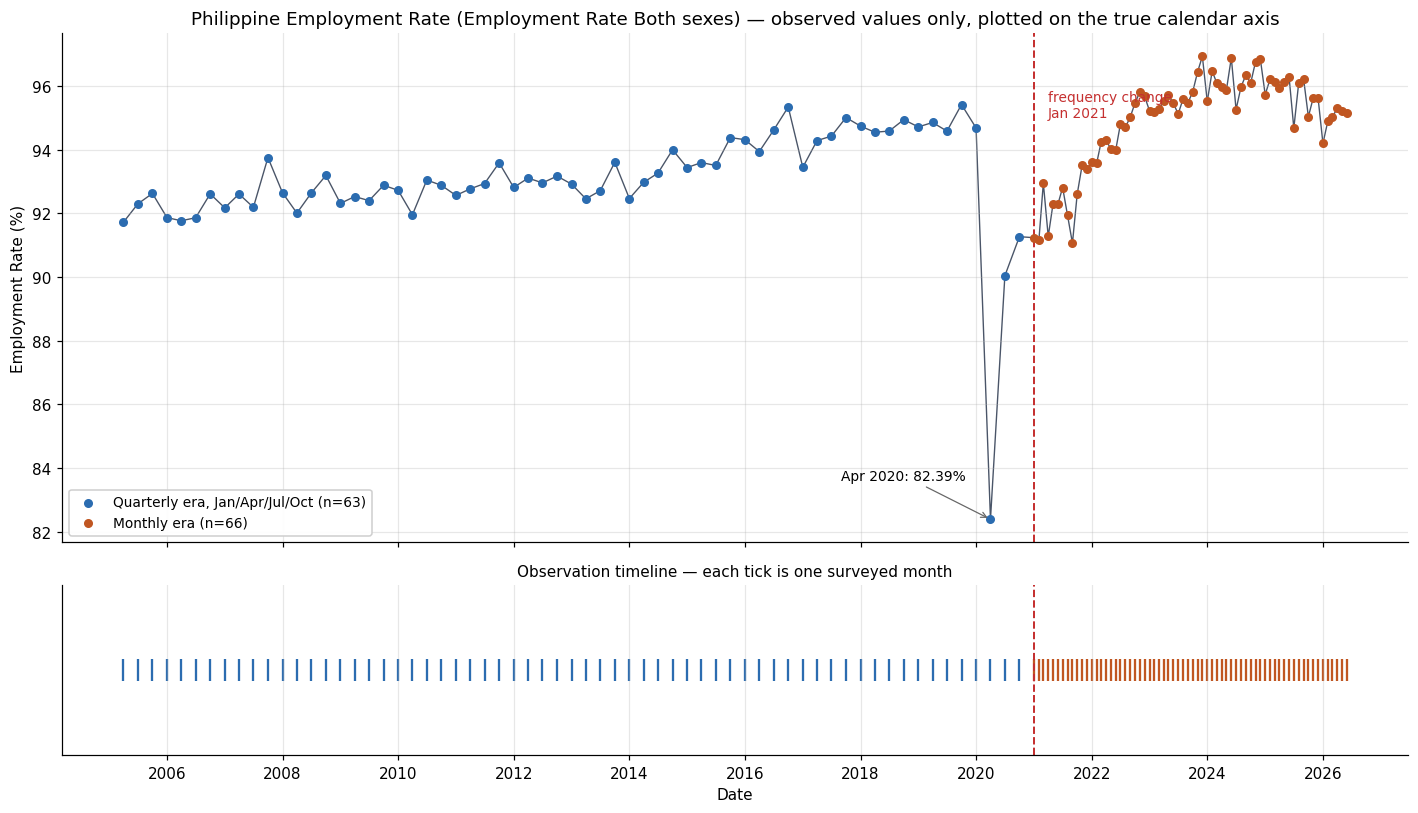

In [420]:
fig, axes = plt.subplots(
    2, 1, figsize=(13, 7.5), sharex=True, gridspec_kw={"height_ratios": [3, 1]}
)

ROUND_MONTHS_LABEL = "/".join(
    pd.Timestamp(2000, m, 1).strftime("%b") for m in ROUND_MONTHS
)
is_q = observed["Regime"] == "Quarterly"
ax = axes[0]
ax.plot(observed["Date"], observed[TARGET], color="#4a5568", lw=0.9, zorder=1)
ax.scatter(observed.loc[is_q, "Date"], observed.loc[is_q, TARGET], s=24,
           color="#2b6cb0", zorder=3,
           label=f"Quarterly era, {ROUND_MONTHS_LABEL} (n={int(is_q.sum())})")
ax.scatter(observed.loc[~is_q, "Date"], observed.loc[~is_q, TARGET], s=24,
           color="#c05621", zorder=3, label=f"Monthly era (n={int((~is_q).sum())})")
ax.axvline(MONTHLY_START, color="#c53030", ls="--", lw=1.3)
ax.annotate(f"frequency change\n{MONTHLY_START:%b %Y}",
            xy=(MONTHLY_START, target_values.max()), xytext=(9, -22),
            textcoords="offset points", color="#c53030", fontsize=9,
            ha="left", va="top")

lowest = observed.loc[target_values.idxmin()]
ax.annotate(f"{lowest['Date']:%b %Y}: {lowest[TARGET]:.2f}%",
            xy=(lowest["Date"], lowest[TARGET]), xytext=(-16, 26),
            textcoords="offset points", fontsize=9, ha="right",
            arrowprops=dict(arrowstyle="->", color="#666", lw=0.8))

ax.set_ylabel("Employment Rate (%)")
ax.set_title(f"Philippine Employment Rate ({TARGET}) — observed values only, "
             f"plotted on the true calendar axis")
ax.legend(loc="lower left", fontsize=9, framealpha=0.95)

ax = axes[1]
ax.scatter(observed.loc[is_q, "Date"], np.ones(int(is_q.sum())), marker="|", s=200,
           color="#2b6cb0")
ax.scatter(observed.loc[~is_q, "Date"], np.ones(int((~is_q).sum())), marker="|", s=200,
           color="#c05621")
ax.axvline(MONTHLY_START, color="#c53030", ls="--", lw=1.3)
ax.set_yticks([])
ax.set_ylim(0.9, 1.1)
ax.set_xlabel("Date")
ax.set_title("Observation timeline — each tick is one surveyed month", fontsize=10)
ax.grid(axis="x", alpha=0.3)
ax.xaxis.set_major_locator(mdates.YearLocator(2))
ax.xaxis.set_major_formatter(mdates.DateFormatter("%Y"))

fig.tight_layout()
plt.show()
save_fig(fig, "frequency_timeline.png")

#### Findings:

The lower panel shows the sampling pattern clearly: widely and regularly spaced
markers across fifteen years, followed by an abrupt transition to a dense continuous band from
January 2021. A single dataset thus contains two distinct sampling regimes.

The upper panel also shows a limitation affecting the early record. Between 2005 and 2020
employment is observed only four times annually, so any movement of shorter duration than one
quarter is unobservable. The early series therefore *appears* smoother than the later series in
part because it is sampled less frequently.

The April 2020 contraction to **82.39%** dominates the vertical scale, and the subsequent recovery
remains incomplete at the point where monthly reporting starts.

#### Constraint on interpretation:

It The figure does not provide sufficient evidence to conclude that the early period is intrinsically more
stable than the recent period on the basis of its smoother appearance, since this is partly a
sampling effect. Any comparison of variability across the two eras must account for the difference
in observation frequency, which is the purpose of Section 9.1.

#### Implication for the next step:

The frequency change is genuine, abrupt and internally clean. It
cannot be resolved through data cleaning and is handled by selecting analytically
coherent windows, as undertaken in Section 5.


---

# 5. Analytical Data Views

#### Objective:

Define three distinct views of the dataset and verify the spacing of each.

#### Rationale:

No single series can serve every analytical purpose in this study, and constructing
one would require accepting a serious limitation. The complete record is the only source of long-run
context but is unequally spaced and is not suitable for sequential modelling. The monthly era is equally
spaced and suitable for forecasting but spans only five and a half years. The quarterly rounds are
equally spaced and span the full record but are temporally coarse.

Three views are therefore defined, each used only for the purpose it can can support.

| View | Definition | Forecasting use |
|---|---|---|
| **A — Full history** | 129 observations, mixed spacing | **None** — context and interpretation only |
| **B — Monthly** | January 2021 – June 2026, equally monthly | Candidate primary series |
| **C — Quarterly rounds** | April 2005 – April 2026, equally quarterly | Long-history cross-check |

Two alternatives are rejected on the grounds established in Sections 3.5 and 4.4: interpolation of
the quarterly era to monthly frequency, which would fabricate unobserved data; and aggregation of
monthly observations into quarterly means, which would introduce an artificial variance
discontinuity at the transition.

The assertions serve as safeguards. Incorrect window construction halts execution rather than
producing a superficially plausible but invalid forecast.


In [421]:
view_a = observed.copy()
view_b = observed[observed["Date"] >= MONTHLY_START].copy().reset_index(drop=True)
view_c = quarterly.copy()

assert len(view_b) == N_MONTHLY
assert view_b["Gap_Months"].iloc[1:].eq(1).all(), "View B is not continuously monthly"
assert view_c["Gap_Months"].iloc[1:].eq(3).all(), "View C is not evenly spaced quarterly"
print("Spacing assertions passed: View B is strictly monthly, View C strictly quarterly.")

modeling_windows = pd.DataFrame(
    [
        dict(View="A - Full historical context",
             Start_Date=f"{view_a['Date'].min():%Y-%m}",
             End_Date=f"{view_a['Date'].max():%Y-%m}",
             Frequency="Mixed (quarterly then monthly)",
             N_Observations=len(view_a),
             Purpose="Historical context, descriptive EDA, structural-change narrative, "
                     "historical employment reference",
             Notes="NOT equally spaced. Must never be modelled as a single sequential "
                   "series; used for context and interpretation only."),
        dict(View="B - Primary monthly modelling series",
             Start_Date=f"{view_b['Date'].min():%Y-%m}",
             End_Date=f"{view_b['Date'].max():%Y-%m}",
             Frequency="Monthly",
             N_Observations=len(view_b),
             Purpose="Candidate primary series for model fitting, temporal validation, "
                     "model comparison and the final future forecast",
             Notes=f"Longest continuous monthly run in the dataset. Begins {MONTHLY_START:%b %Y}, "
                   f"which lies within the COVID recovery period - statistical suitability is "
                   f"NOT yet established and is tested in later sections."),
        dict(View="C - Quarterly long-history series",
             Start_Date=f"{view_c['Date'].min():%Y-%m}",
             End_Date=f"{view_c['Date'].max():%Y-%m}",
             Frequency="Quarterly (Jan/Apr/Jul/Oct survey rounds)",
             N_Observations=len(view_c),
             Purpose="Focused robustness check on whether the longer history contradicts "
                     "the direction or broad conclusion of the monthly analysis",
             Notes=f"Built by SELECTING comparable single-month survey rounds, not by "
                   f"averaging. Zero cadence breaks. "
                   f"{int((view_c['Date'] >= MONTHLY_START).sum())} of {len(view_c)} points "
                   f"are drawn from the monthly era, so it is a partially overlapping check, "
                   f"not an independent sample."),
    ]
)
display(modeling_windows)
save_table(modeling_windows, "modeling_windows.csv")

Spacing assertions passed: View B is strictly monthly, View C strictly quarterly.


,View,Start_Date,End_Date,Frequency,N_Observations,Purpose,Notes
0,A - Full historical context,2005-04,2026-06,Mixed (quarterly then monthly),129,"Historical context, descriptive EDA, structura...",NOT equally spaced. Must never be modelled as ...
1,B - Primary monthly modelling series,2021-01,2026-06,Monthly,66,"Candidate primary series for model fitting, te...",Longest continuous monthly run in the dataset....
2,C - Quarterly long-history series,2005-04,2026-04,Quarterly (Jan/Apr/Jul/Oct survey rounds),85,Focused robustness check on whether the longer...,Built by SELECTING comparable single-month sur...


#### Findings:

The spacing checks passed. **View B (n = 66)** is strictly monthly and **View C
(n = 85)** is strictly quarterly. **View A** keeps all 129 observations and is designated
context-only.


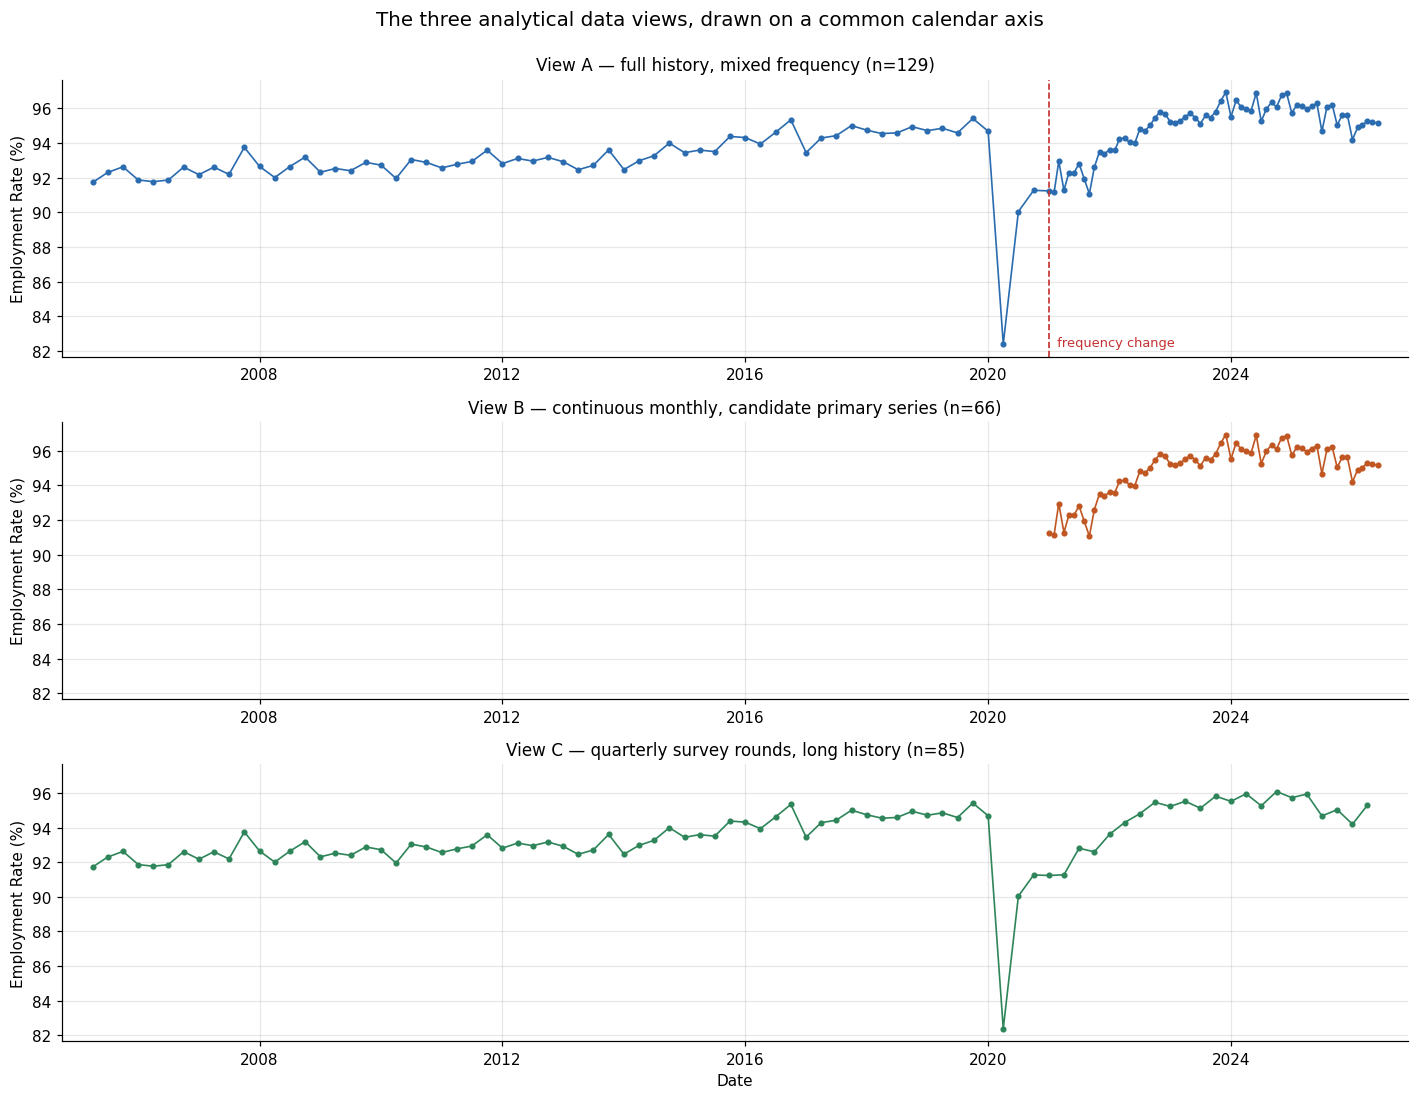

In [422]:
fig, axes = plt.subplots(3, 1, figsize=(13, 10), sharey=True)

specs = [
    (view_a, "#2b6cb0", f"View A — full history, mixed frequency (n={len(view_a)})", True),
    (view_b, "#c05621", f"View B — continuous monthly, candidate primary series "
                        f"(n={len(view_b)})", False),
    (view_c, "#2f855a", f"View C — quarterly survey rounds, long history (n={len(view_c)})",
     False),
]

for ax, (data, colour, title, mixed) in zip(axes, specs):
    ax.plot(data["Date"], data[TARGET], color=colour, lw=1.1, marker="o", ms=3)
    ax.set_title(title, fontsize=11)
    ax.set_ylabel("Employment Rate (%)")
    ax.set_xlim(view_a["Date"].min() - pd.DateOffset(months=6),
                view_a["Date"].max() + pd.DateOffset(months=6))
    if mixed:
        ax.axvline(MONTHLY_START, color="#c53030", ls="--", lw=1.1)
        ax.text(MONTHLY_START, ax.get_ylim()[0] + 0.6, "  frequency change",
                color="#c53030", fontsize=8.5)

axes[-1].set_xlabel("Date")
fig.suptitle("The three analytical data views, drawn on a common calendar axis",
             fontsize=13, y=0.995)
fig.tight_layout()
plt.show()
save_fig(fig, "analytical_data_views.png")

#### Findings:

Presented on a common calendar axis, the trade-off between the three views is
apparent.

View A conveys the complete record — gradual increase, pandemic contraction, and recovery to a
higher level — but the change in observation density partway through is specifically why it cannot be
modelled as a sequence.

View B is short and lies entirely within the post-pandemic period. Its **initial level is
approximately 91%, rising steeply**: the monthly series starts during the recovery.

View C restores the full historical span at consistent spacing and reveals a gradual upward drift
through the 2010s that View B alone cannot exhibit.

#### Important caveat:

The frequency change and the pandemic recovery occur at
approximately the same date and are therefore **confounded**: the only continuously monthly data
available is the recovery-and-subsequent period. The practical consequence is specific. A
trend-extrapolating model estimated on View B without adjustment would interpret the initial
recovery as an ongoing trend and project it forward, when the movement in fact represents a
non-recurring rebound that has subsequently stabilised.

This finding guides several later decisions, including the parallel trimmed window defined in
Section 9.2 and the preference for damped rather than linear trend specifications in Section 14.


---

# 6. Construction of the Target Series

#### Objective:

Convert each view into a date-indexed series object and verify the spacing a second
time.

#### Rationale:

The data has to this point been handled in tabular form. Forecasting procedures
require series indexed by date with declared spacing. Repeating the verification here
ensures that any subsequent modification which inadvertently altered a window causes execution to
halt rather than producing forecasts from a malformed series.

The target variable is `Employment Rate Both sexes`, the percentage of the Philippine labour force
in employment. It is a national macroeconomic indicator and not a measure of PEME demand, a
distinction maintained throughout the analysis.


In [423]:
from statsmodels.tsa.stattools import adfuller, kpss, acf, pacf
from statsmodels.graphics.tsaplots import plot_acf, plot_pacf
from statsmodels.stats.diagnostic import acorr_ljungbox
from statsmodels.tsa.seasonal import STL
from scipy import stats


def to_series(frame, name):
    s = pd.Series(
        frame[TARGET].to_numpy(),
        index=pd.DatetimeIndex(frame["Date"]),
        name=name,
    )
    s.index.name = "Period"
    return s


series_a = to_series(view_a, "View A - full history")
series_b = to_series(view_b, "View B - monthly").asfreq("MS")
series_c = to_series(view_c, "View C - quarterly rounds")

# Fail loudly if a window was built incorrectly.
assert series_b.notna().all(), "View B has gaps after being placed on a monthly frequency"
assert len(series_b) == N_MONTHLY
assert series_c.index.to_series().diff().dt.days.dropna().between(89, 92).all(), \
    "View C is not evenly spaced at quarterly intervals"

summary = pd.DataFrame(
    [
        ("View A - full history", len(series_a), f"{series_a.index.min():%b %Y}",
         f"{series_a.index.max():%b %Y}", "Mixed - context only"),
        ("View B - monthly", len(series_b), f"{series_b.index.min():%b %Y}",
         f"{series_b.index.max():%b %Y}", "Monthly (MS), verified complete"),
        ("View C - quarterly rounds", len(series_c), f"{series_c.index.min():%b %Y}",
         f"{series_c.index.max():%b %Y}", "Quarterly, verified evenly spaced"),
    ],
    columns=["Series", "N", "Start", "End", "Spacing"],
)
display(summary)
print("Spacing assertions passed - each series matches the Section 4 audit.")

,Series,N,Start,End,Spacing
0,View A - full history,129,Apr 2005,Jun 2026,Mixed - context only
1,View B - monthly,66,Jan 2021,Jun 2026,"Monthly (MS), verified complete"
2,View C - quarterly rounds,85,Apr 2005,Apr 2026,"Quarterly, verified evenly spaced"


Spacing assertions passed - each series matches the Section 4 audit.


---

# 7. Descriptive Analysis

#### Objective:

Compute descriptive statistics for each analytical view and for three historical
periods.

#### Rationale:

Two quantities matter for this study and are readily conflated. **Level** denotes the
magnitude of employment and is the quantity that ultimately informs the planning signal.
**Variability** denotes the degree to which employment fluctuates and is measured by the standard
deviation, which expresses the typical distance of observations from their mean. A high standard
deviation indicates that employment is unpredictable, not that it is high. The distinction is
important because the business signal concerns level whereas forecast reliability depends on
variability.

The effect of unequal weighting must also be measured. View A is unequally spaced and therefore does not
weight history uniformly: it contributes four observations per year before 2021 and twelve
thereafter. Any statistic computed over View A therefore assigns the recent era approximately
three times the per-year influence of the earlier era. The magnitude of this distortion is
measurable, since View C spans nearly the same period with equal weighting; the difference between
the two isolates the bias.


In [424]:
describe_scope("View A - full history (mixed frequency)", series_a,
               "Unequal temporal weighting: 4 obs/yr pre-2021, 12 obs/yr after")
describe_scope("View B - monthly modelling series", series_b,
               "Equally spaced monthly")
describe_scope("View C - quarterly rounds (long history)", series_c,
               "Equally spaced quarterly; balanced temporal weighting")

view_stats = pd.DataFrame(DESCRIPTIVE_ROWS)
display(view_stats.drop(columns="Note"))

bias = view_stats.set_index("Scope")
mean_gap = (bias.loc["View A - full history (mixed frequency)", "Mean"]
            - bias.loc["View C - quarterly rounds (long history)", "Mean"])
sd_gap = (bias.loc["View A - full history (mixed frequency)", "Std_Dev"]
          - bias.loc["View C - quarterly rounds (long history)", "Std_Dev"])
print(f"View A mean minus View C mean : {mean_gap:+.4f} percentage points")
print(f"View A SD   minus View C SD   : {sd_gap:+.4f} percentage points")
print("View A and View C cover almost the same span, so these gaps are a direct")
print("measure of the distortion caused by unequal temporal weighting in View A.")

,Scope,N,Mean,Median,Std_Dev,Min,Q1,Q3,Max,Range,IQR
0,View A - full history (mixed frequency),129,93.9880,94.2280,1.8701,82.3950,92.7180,95.4120,96.9260,14.5310,2.6940
1,View B - monthly modelling series,66,94.8884,95.2775,1.5126,91.0600,94.2025,95.9458,96.9260,5.8660,1.7433
2,View C - quarterly rounds (long history),85,93.4491,93.4340,1.8020,82.3950,92.6040,94.6780,96.0780,13.6830,2.0740


View A mean minus View C mean : +0.5388 percentage points
View A SD   minus View C SD   : +0.0681 percentage points
View A and View C cover almost the same span, so these gaps are a direct
measure of the distortion caused by unequal temporal weighting in View A.


#### Findings:

The three views characterise the same underlying data differently.

| View | N | Mean | Std. dev. | Minimum | Maximum |
|---|---|---|---|---|---|
| A — full history (mixed) | 129 | 93.99% | 1.87 | 82.40% | 96.93% |
| B — monthly | 66 | 94.89% | 1.51 | 91.06% | 96.93% |
| C — quarterly rounds | 85 | 93.45% | 1.80 | 82.40% | 96.08% |

The weighting distortion amounts to **+0.54 percentage points in the mean**: View A reports average
employment more than half a point higher than View C despite covering substantially the same period.

#### Interpretation:

This difference does not reflect differing historical coverage but differing
**weighting**. View A over-represents the recent, higher-employment years because they were surveyed
more frequently. Half a percentage point is important in a series whose normal operating range spans
approximately five points.

#### Implication for the next step:

Wherever the analysis requires a **historical reference level** —
most importantly when establishing thresholds for the employment activity signal in Section 26 —
**View C** is used rather than View A. View A is keeped for narrative and visual context, where
unequal weighting is immaterial.


## 7.1 Comparison across historical periods

#### Objective:

Partition the record into pre-pandemic, pandemic-and-recovery, and post-recovery
periods, and compare level and variability.

#### Rationale and constraint:

The period boundaries are selected on the basis of known events rather
than estimated from the data. They constitute **descriptive conventions, not statistically
identified regimes**, and nothing that follows should be interpreted as a claim that each period
represents a distinct statistical process.


In [425]:
COVID_START = pd.Timestamp("2020-01-01")
POST_START = pd.Timestamp("2022-01-01")

eras = {
    f"Pre-COVID ({series_a.index.min():%b %Y} - Dec 2019)":
        series_a[series_a.index < COVID_START],
    "COVID and recovery (Jan 2020 - Dec 2021)":
        series_a[(series_a.index >= COVID_START) & (series_a.index < POST_START)],
    f"Post-recovery (Jan 2022 - {series_a.index.max():%b %Y})":
        series_a[series_a.index >= POST_START],
}
for label, s in eras.items():
    describe_scope(label, s, "Descriptive era split of View A; not a regime claim")

era_stats = pd.DataFrame(DESCRIPTIVE_ROWS).tail(len(eras)).reset_index(drop=True)
display(era_stats.drop(columns="Note"))

,Scope,N,Mean,Median,Std_Dev,Min,Q1,Q3,Max,Range,IQR
0,Pre-COVID (Apr 2005 - Dec 2019),59,93.2786,92.9690,0.9988,91.7200,92.5820,94.1370,95.4120,3.6920,1.5550
1,COVID and recovery (Jan 2020 - Dec 2021),16,91.5512,92.1060,2.7021,82.3950,91.2135,92.8425,94.6780,12.2830,1.6290
2,Post-recovery (Jan 2022 - Jun 2026),54,95.4850,95.5520,0.8076,93.5690,95.0517,96.0863,96.9260,3.3570,1.0345


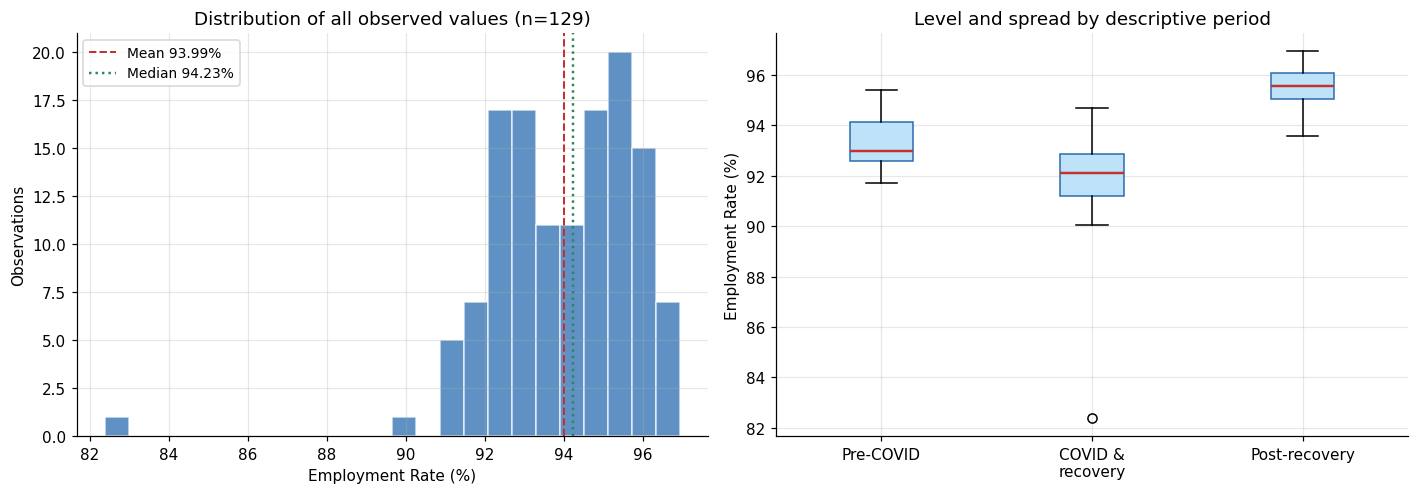

In [426]:
fig, axes = plt.subplots(1, 2, figsize=(13, 4.6))

ax = axes[0]
ax.hist(series_a.values, bins=24, color="#2b6cb0", alpha=0.75, edgecolor="white")
ax.axvline(series_a.mean(), color="#c53030", ls="--", lw=1.3,
           label=f"Mean {series_a.mean():.2f}%")
ax.axvline(series_a.median(), color="#2f855a", ls=":", lw=1.6,
           label=f"Median {series_a.median():.2f}%")
ax.set_xlabel("Employment Rate (%)")
ax.set_ylabel("Observations")
ax.set_title(f"Distribution of all observed values (n={len(series_a)})")
ax.legend(fontsize=9)

ax = axes[1]
ax.boxplot([s.values for s in eras.values()],
           tick_labels=["Pre-COVID", "COVID &\nrecovery", "Post-recovery"],
           patch_artist=True,
           boxprops=dict(facecolor="#bee3f8", edgecolor="#2b6cb0"),
           medianprops=dict(color="#c53030", lw=1.6))
ax.set_ylabel("Employment Rate (%)")
ax.set_title("Level and spread by descriptive period")

fig.tight_layout()
plt.show()
save_fig(fig, "distribution_by_era.png")

#### Findings:

| Period | N | Mean | Std. dev. | Minimum | Maximum |
|---|---|---|---|---|---|
| Pre-pandemic (Apr 2005 – Dec 2019) | 59 | 93.28% | 1.00 | 91.72% | 95.41% |
| Pandemic and recovery (2020–2021) | 16 | 91.55% | 2.70 | 82.40% | 94.68% |
| Post-recovery (Jan 2022 – Jun 2026) | 54 | 95.49% | 0.81 | 93.57% | 96.93% |

The distribution is **left-skewed**, comprising a dense concentration of values in the low-to-mid
nineties with a thin tail extending toward 82%. This accounts for the mean (93.99%) lying **below**
the median (94.23%): a small number of severe pandemic observations depress the mean while the
majority of the record lies higher.

The period comparison indicates that the post-recovery period occupies a **higher level** with
**narrower dispersion** than the pre-pandemic period, and that the pandemic period is substantially
more dispersed than either, its standard deviation of 2.70 approaching three times the pre-pandemic
value.

#### Interpretation, subject to two qualifications:

First, these periods differ in mean and
dispersion, but the periods were defined by the analyst, and such differences do not constitute
evidence that they represent distinct statistical processes.

Second, and more noticeably, **part of the apparent reduction in dispersion is a sampling
artefact**. The pre-pandemic period is observed quarterly and the post-recovery period monthly.
Monthly observation captures short-duration fluctuation that quarterly observation does not, so the
two periods are not measured comparably. This cannot be resolved within View A.

#### Implication for the next step:

Section 9.1 repeats the comparison using View C, in which both
periods are observed identically, which eliminating the sampling explanation.


---

# 8. Historical Employment Record

#### Objective:

Plot the full observed history against calendar time, annotated with the
pre-pandemic mean, the pandemic period, the extreme observations, and the startment of monthly
reporting.

#### Rationale:

This is the principal descriptive exhibit of the study. Characterising the historical
behaviour of Philippine employment — including major shocks, changes in level, and periods requiring
particular treatment — is a prerequisite to any forecasting decision. The specific features under
examination are the long-run direction, the magnitude of the pandemic disruption relative to normal
variation, whether the series returned to its former level or stabilised at a different one, and its
most recent behaviour.


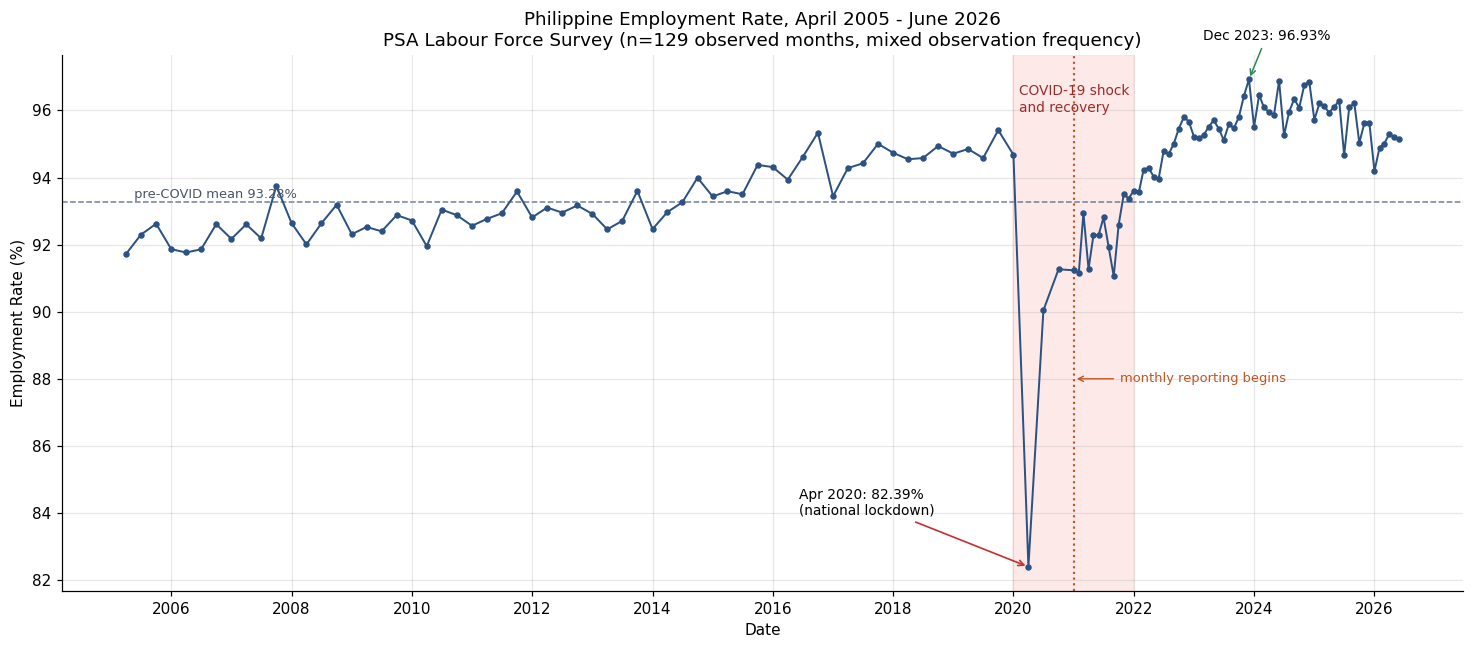

In [427]:
fig, ax = plt.subplots(figsize=(13.5, 6))

ax.axvspan(COVID_START, POST_START, color="#fed7d7", alpha=0.55, zorder=0)
ax.text(pd.Timestamp("2020-02-01"), series_a.max() - 0.15, "COVID-19 shock\nand recovery",
        fontsize=9, color="#9b2c2c", va="top", ha="left")

ax.plot(series_a.index, series_a.values, color="#2c5282", lw=1.3,
        marker="o", ms=3.2, zorder=3)

pre_mean = eras[list(eras)[0]].mean()
ax.axhline(pre_mean, color="#718096", ls="--", lw=1.0, zorder=1)
ax.text(series_a.index.min(), pre_mean + 0.12,
        f"  pre-COVID mean {pre_mean:.2f}%", fontsize=8.5, color="#4a5568")

trough = series_a.idxmin()
ax.annotate(f"{trough:%b %Y}: {series_a.min():.2f}%\n(national lockdown)",
            xy=(trough, series_a.min()), xytext=(-150, 34),
            textcoords="offset points", fontsize=9,
            arrowprops=dict(arrowstyle="->", color="#c53030", lw=1.1))

peak = series_a.idxmax()
ax.annotate(f"{peak:%b %Y}: {series_a.max():.2f}%",
            xy=(peak, series_a.max()), xytext=(-30, 26),
            textcoords="offset points", fontsize=9,
            arrowprops=dict(arrowstyle="->", color="#2f855a", lw=1.0))

ax.axvline(MONTHLY_START, color="#c05621", ls=":", lw=1.4, zorder=2)
ax.annotate("monthly reporting begins", xy=(MONTHLY_START, 88.0),
            xytext=(30, 0), textcoords="offset points", fontsize=8.5,
            color="#c05621", va="center",
            arrowprops=dict(arrowstyle="->", color="#c05621", lw=0.9))

ax.set_xlabel("Date")
ax.set_ylabel("Employment Rate (%)")
ax.set_title(f"Philippine Employment Rate, {series_a.index.min():%B %Y} - "
             f"{series_a.index.max():%B %Y}\n"
             f"PSA Labour Force Survey (n={len(series_a)} observed months, "
             f"mixed observation frequency)")
ax.xaxis.set_major_locator(mdates.YearLocator(2))
ax.xaxis.set_major_formatter(mdates.DateFormatter("%Y"))

fig.tight_layout()
plt.show()
save_fig(fig, "historical_employment.png")

#### Findings:

#### Long-run behaviour, 2005–2019:

Employment increases gradually within a narrow band, from
approximately 92% to approximately 95%, with observable short-term fluctuation about that gradual
increase. No abrupt discontinuity occurs across these fifteen years.

#### The pandemic contraction, April 2020:

An abrupt and isolated contraction to **82.39%**, situated
far outside the remainder of the record. For comparison, the entire pre-pandemic period varies
within approximately 3.7 percentage points, whereas this single observation lies approximately 11
points below the pre-pandemic mean.

#### Recovery:

The series increases steeply from the trough through 2021 and into 2022, crossing above
the pre-pandemic mean of **93.28%** during late 2021.

#### Recent behaviour:

From 2022 the series stabilises within a **higher band** than it occupied
before the pandemic, attaining a maximum of **96.93% in December 2023**. Subsequent movement is
approximately lateral with recurring short-duration declines, and the final two years indicate
moderate easing from those maxima rather than continued increase.

#### Interpretation:

The series exhibits evidence of a **substantial shift in level** associated with
the pandemic that **may** indicate structural change, and this must be considered in selecting the
forecasting window.

#### Constraints on interpretation:

It The figure does not provide sufficient evidence to conclude from this figure alone that the pre- and
post-pandemic periods constitute distinct statistical processes, for two reasons. The change in
observation frequency occurs at approximately the same date, so part of the apparent change in
character is a sampling effect rather than an economic one. Further, a shift in level is not
equivalent to a change in the underlying generating process. Section 9 establishes which features
persist once the sampling difference is eliminated.

#### Implications for forecasting:

Three consequences follow. The recent series occupies a different
level from the long historical record, so a long-history mean is an inadequate representation of
prevailing conditions. The recovery is a non-recurring rebound, requiring careful treatment
of trend-extrapolating specifications. The recent lateral movement indicates that the level, rather
than a continuing increase, is the appropriate focus of the forecast.


---

# 9. Structural Change and the Recovery Window

#### Objective:

Resolve two questions raised but not settled by the preceding sections.

First, whether the shift in level is genuine or an artefact of the change in observation frequency.
Section 7.1 established a higher level and narrower dispersion following the pandemic but could not
exclude the possibility that monthly observation simply captures more movement than quarterly
observation.

Second, where the recovery ends. Section 5 showed that View B starts during the
recovery. Assessing the consequence requires a trimmed window, but the cut-point must be determined
by a rule **fixed in advance** rather than by evaluating alternatives and keeping whichever
produces preferable results.


## 9.1 Assessment of the level shift on equally spaced data

#### Objective:

Compare the pre- and post-pandemic periods again using **View C only**, in which both
periods are observed at identical quarterly intervals.

#### Rationale:

Within View C the pre-pandemic and post-recovery segments are measured identically.
Any difference that persists therefore cannot be attributed to the transition from quarterly to
monthly observation.


In [428]:
c_pre = series_c[series_c.index < COVID_START]
c_post = series_c[series_c.index >= POST_START]

comparison = pd.DataFrame(
    [
        dict(Series="View A (mixed frequency)",
             Pre_Mean=eras[list(eras)[0]].mean(), Post_Mean=eras[list(eras)[2]].mean(),
             Pre_SD=eras[list(eras)[0]].std(), Post_SD=eras[list(eras)[2]].std(),
             Pre_N=eras[list(eras)[0]].size, Post_N=eras[list(eras)[2]].size),
        dict(Series="View C (equally spaced quarterly)",
             Pre_Mean=c_pre.mean(), Post_Mean=c_post.mean(),
             Pre_SD=c_pre.std(), Post_SD=c_post.std(),
             Pre_N=c_pre.size, Post_N=c_post.size),
    ]
)
comparison["Mean_Shift"] = comparison["Post_Mean"] - comparison["Pre_Mean"]
comparison["SD_Ratio"] = comparison["Post_SD"] / comparison["Pre_SD"]
display(comparison)

print(f"Level shift measured on equally spaced data (View C): "
      f"{c_post.mean() - c_pre.mean():+.3f} percentage points")
print(f"Variability ratio on equally spaced data (View C)   : "
      f"{c_post.std() / c_pre.std():.3f}x")

,Series,Pre_Mean,Post_Mean,Pre_SD,Post_SD,Pre_N,Post_N,Mean_Shift,SD_Ratio
0,View A (mixed frequency),93.2786,95.4850,0.9988,0.8076,59,54,2.2064,0.8086
1,View C (equally spaced quarterly),93.2786,95.1918,0.9988,0.6703,59,18,1.9132,0.6711


Level shift measured on equally spaced data (View C): +1.913 percentage points
Variability ratio on equally spaced data (View C)   : 0.671x


#### Findings:

| Series | Pre-pandemic mean | Post-recovery mean | Shift | SD ratio |
|---|---|---|---|---|
| View A (mixed frequency) | 93.28% | 95.49% | **+2.21 pp** | 0.81× |
| View C (equal spacing) | 93.28% | 95.19% | **+1.91 pp** | 0.67× |

#### Interpretation:

The shift in level **persists** under equal-footing comparison. On identically
observed data the post-recovery mean remains **1.91 percentage points** above the pre-pandemic mean,
establishing a change in level rather than a measurement artefact.

View A **overstates** the shift by approximately 0.3 percentage points, consistent with the weighting
effect quantified in Section 7 and confirming View C as the appropriate basis for historical
reference levels.

The variability comparison operates in the opposite direction. On equally spaced data the
post-recovery standard deviation is **0.67×** the pre-pandemic value, a larger apparent reduction
than View A indicates. Whether this reduction is statistically supported is tested below.

#### Limitation:

The View C post-recovery segment comprises only **18 observations**, so its
variability estimate is imprecise.


#### Objective:

Test formally whether the difference in variability is statistically supported.

#### Rationale:

The question concerns a difference in dispersion between two groups. Levene's test is
appropriate because, unlike an F-test of variances, it does not require the assumption of normality
— an assumption the pronounced left tail of this series would not satisfy.

The null hypothesis states that both periods have equal variance.

The p-value expresses the probability of observing a difference in dispersion at least as large as
that obtained **if the two periods genuinely had equal variance**. It is not the probability
that the null hypothesis is true, nor the probability that the result arose by chance.


In [429]:
# Is the difference in spread large enough to take seriously, or is it noise?
# Levene's test compares variability between two groups and, unlike an F-test of
# variances, does not assume the data are normally distributed.
lev_stat, lev_p = stats.levene(c_pre.values, c_post.values, center="median")
ALPHA = 0.05

record_test(
    stage="Structural context (View C, equally spaced)",
    model="n/a - descriptive series comparison",
    test="Levene's test for equality of variances (median-centred)",
    purpose="Test whether employment-rate variability differs between the pre-COVID and "
            "post-recovery periods, using equally spaced data so the result cannot be an "
            "artifact of the change in sampling frequency",
    null_hypothesis="The two periods have equal variance",
    alt_hypothesis="The two periods have unequal variance",
    statistic=round(float(lev_stat), 4),
    p_value=round(float(lev_p), 6),
    alpha=ALPHA,
    conclusion=("Reject the null at alpha=0.05" if lev_p < ALPHA
                else "Fail to reject the null at alpha=0.05"),
    interpretation=(
        f"Pre-COVID SD = {c_pre.std():.3f}, post-recovery SD = {c_post.std():.3f} "
        f"(ratio {c_post.std() / c_pre.std():.2f}x). "
        + ("The data are consistent with a genuine difference in variability between the two "
           "periods that is not explained by the sampling change."
           if lev_p < ALPHA else
           "There is insufficient evidence to conclude that variability differs between the "
           "two periods; this does not prove the variances are equal.")
    ),
)

print(f"Levene statistic = {lev_stat:.4f},  p-value = {lev_p:.6f},  alpha = {ALPHA}")
print(f"Pre-COVID SD = {c_pre.std():.3f}   Post-recovery SD = {c_post.std():.3f}")

Levene statistic = 3.6021,  p-value = 0.061554,  alpha = 0.05
Pre-COVID SD = 0.999   Post-recovery SD = 0.670


#### Findings:

Levene's statistic is **3.60** with a **p-value of 0.0616**, against a significance
level of 0.05. The pre-pandemic standard deviation is **1.00** and the post-recovery standard
deviation **0.67**.

#### Interpretation:

Because 0.0616 exceeds 0.05, the null hypothesis is **not rejected**. Stated
specifically: **there is insufficient evidence to conclude that variability differs between the two
periods.** This does not show that the variances are equal. The result lies close to the
threshold, and with only 18 post-recovery observations the test has limited power to detect a
difference that may well exist.

#### Statistical against practical significance:

The observed difference is potentially important in
operational terms, since a one-third reduction in variability would represent appreciably more
predictable employment conditions. The test establishes only that this sample is insufficient to
confirm the difference, not that it is absent.

#### Implication for the next step:

The analysis proceeds on the basis that the shift in **level** is
established whereas the change in **variability** is suggestive but unconfirmed. Variance stability
is examined directly on model residuals in Section 19.


#### Objective:

Plot the rolling mean and rolling standard deviation over the long, equally spaced
quarterly record.

#### Rationale:

A rolling window recomputes a statistic over successive short segments, exhibiting its
evolution rather than reducing the record to a single summary value. The rolling mean traces the
underlying level once short-term fluctuation is attenuated; the rolling standard deviation indicates
whether the series has become more or less variable over time. Using View C ensures each window
covers a constant quantity of calendar time.


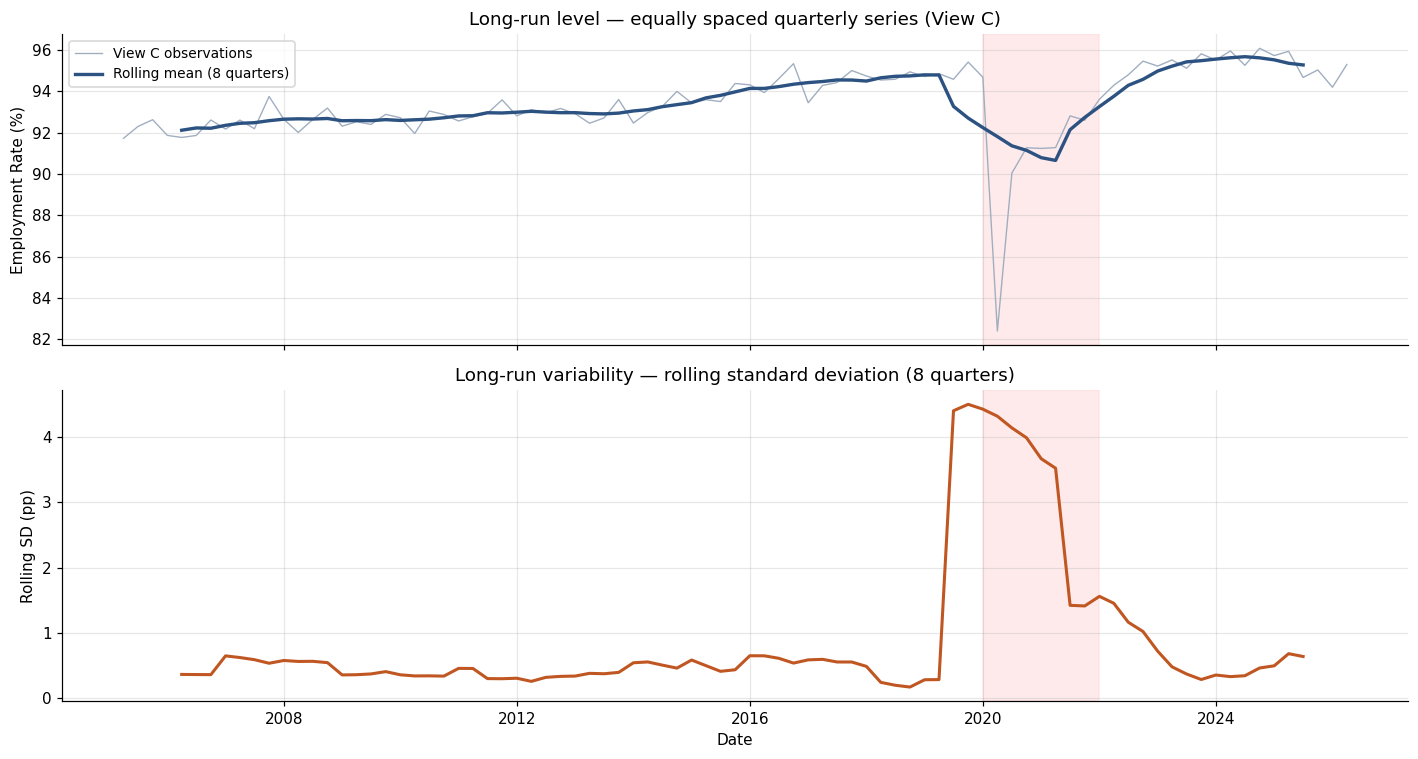

In [430]:
# Rolling level and spread over the long, equally spaced history.
WIN_Q = 8  # eight quarters = two years
roll_mean_c = series_c.rolling(WIN_Q, center=True).mean()
roll_sd_c = series_c.rolling(WIN_Q, center=True).std()

fig, axes = plt.subplots(2, 1, figsize=(13, 7), sharex=True)

ax = axes[0]
ax.axvspan(COVID_START, POST_START, color="#fed7d7", alpha=0.5, zorder=0)
ax.plot(series_c.index, series_c.values, color="#a0aec0", lw=0.9, label="View C observations")
ax.plot(roll_mean_c.index, roll_mean_c.values, color="#2c5282", lw=2.2,
        label=f"Rolling mean ({WIN_Q} quarters)")
ax.set_ylabel("Employment Rate (%)")
ax.set_title("Long-run level — equally spaced quarterly series (View C)")
ax.legend(fontsize=9)

ax = axes[1]
ax.axvspan(COVID_START, POST_START, color="#fed7d7", alpha=0.5, zorder=0)
ax.plot(roll_sd_c.index, roll_sd_c.values, color="#c05621", lw=2.0)
ax.set_ylabel("Rolling SD (pp)")
ax.set_xlabel("Date")
ax.set_title(f"Long-run variability — rolling standard deviation ({WIN_Q} quarters)")

fig.tight_layout()
plt.show()
save_fig(fig, "structural_change.png")

#### Findings:

The rolling mean exhibits three distinct phases: gradual and relatively steady increase
through the 2010s, abrupt dislocation at the pandemic, and stabilisation at a visibly higher level
thereafter.

The rolling standard deviation remains low and approximately flat throughout the pre-pandemic
record, rises sharply at the pandemic, and returns to a low level subsequently.

#### Interpretation:

The variability profile supports a specific characterisation of this series: it
is **ordinarily stable and was disrupted once, severely**. This differs noticeably from a
chronically volatile series and provides a more favorable basis for forecasting.

#### Constraint on interpretation:

The pandemic is more accurately described as a single extreme
disruption followed by stabilisation at a different level than as a transition between two distinct
statistical regimes. Establishing genuinely distinct generating processes would require substantially
more than a comparison of two period means, and no such claim is advanced.

#### Implication for the next step:

The recent period is the relevant basis for forecasting,
since the series now operates at a different level from its long-run history. This reinforces the
selection of View B as the modelling series, conditional on appropriate treatment of its
recovery-affected initial segment.


## 9.2 Definition of the recovery window

#### Objective:

Separate the recovery portion of View B using a rule fixed in advance, producing a
trimmed window to be assessed alongside the full window.

#### Rationale:

The rule must precede estimation to avoid selecting results after estimation. Evaluating several
cut-points and keeping whichever produced the most favourable forecast would constitute selecting
data to suit a conclusion, and any reported accuracy would be hard to interpret. The rule is therefore
specified before any model is estimated, and the resulting window is accepted as given.

#### Specification:

The reference level is the **pre-pandemic mean**, computed exclusively from
observations preceding January 2020. The recovery segment comprises the initial portion of View B up
to and including the final month falling **below** that reference; the trimmed window starts the
following month.

#### Justification:

The rule employs only pre-pandemic information and therefore cannot be influenced
by the anticipated result. It carries a deend economic interpretation: the recovery is
complete once employment has returned to, and remained at, its typical pre-pandemic level. It is
fully reproducible.

The contiguity check is important. Were below-reference months to occur later in the series, they
would constitute later declines rather than recovery, and the rule would exclude excessive data.
This condition is verified rather than assumed.


In [431]:
PRE_COVID_REFERENCE = series_a[series_a.index < COVID_START].mean()

below_reference = series_b[series_b < PRE_COVID_REFERENCE]
RECOVERY_END = below_reference.index.max()
TRIM_START = RECOVERY_END + pd.DateOffset(months=1)
series_b_trim = series_b[series_b.index >= TRIM_START]

# Confirm the below-reference months form a single leading block; if any occurred
# later they would be genuine dips rather than recovery, and the rule would over-trim.
contiguous = bool((below_reference.index == series_b.index[:len(below_reference)]).all())

print(f"Pre-COVID reference level (mean before Jan 2020) : {PRE_COVID_REFERENCE:.4f}%")
print(f"Months in View B below that reference           : {len(below_reference)}")
print(f"They span                                       : "
      f"{below_reference.index.min():%b %Y} to {RECOVERY_END:%b %Y}")
print(f"They form a single leading block                : {contiguous}")
print()
print(f"Recovery segment excluded : {series_b.index.min():%b %Y} - {RECOVERY_END:%b %Y} "
      f"({len(series_b) - len(series_b_trim)} observations)")
print(f"Trimmed window (View B-T) : {TRIM_START:%b %Y} - "
      f"{series_b_trim.index.max():%b %Y}  (n = {len(series_b_trim)})")

describe_scope(f"View B-T - recovery-trimmed monthly ({TRIM_START:%b %Y} onward)",
               series_b_trim,
               f"Excludes the leading {len(series_b) - len(series_b_trim)} months below the "
               f"pre-COVID reference of {PRE_COVID_REFERENCE:.3f}%")

window_compare = pd.DataFrame(DESCRIPTIVE_ROWS)
window_compare = window_compare[
    window_compare["Scope"].str.startswith(("View B -", "View B-T"))
].reset_index(drop=True)
display(window_compare.drop(columns="Note"))

Pre-COVID reference level (mean before Jan 2020) : 93.2786%
Months in View B below that reference           : 10
They span                                       : Jan 2021 to Oct 2021
They form a single leading block                : True

Recovery segment excluded : Jan 2021 - Oct 2021 (10 observations)
Trimmed window (View B-T) : Nov 2021 - Jun 2026  (n = 56)


,Scope,N,Mean,Median,Std_Dev,Min,Q1,Q3,Max,Range,IQR
0,View B - monthly modelling series,66,94.8884,95.2775,1.5126,91.0600,94.2025,95.9458,96.9260,5.8660,1.7433
1,View B-T - recovery-trimmed monthly (Nov 2021 ...,56,95.4119,95.5135,0.8806,93.3740,95.0125,96.0807,96.9260,3.5520,1.0682


#### Findings:

The pre-pandemic reference level is **93.2786%**. Exactly **ten months** of View B fall
below this reference, spanning **January to October 2021**, and they form a **single initial block**:
no subsequent month falls below the reference, confirming that the rule does not exclude excessive
data.

This defines **View B-T: November 2021 to June 2026, n = 56**.

| Window | N | Mean | Std. dev. | Minimum | Maximum |
|---|---|---|---|---|---|
| View B (full) | 66 | 94.89% | 1.51 | 91.06% | 96.93% |
| View B-T (trimmed) | 56 | 95.41% | 0.88 | 93.37% | 96.93% |

#### Interpretation:

Excluding ten recovery months raises the mean by approximately half a percentage
point and **reduces the standard deviation by more than 40%** (1.51 to 0.88). This is a substantial
effect from the removal of 15% of the observations and quantifies the extent to which the recovery
period governs the behaviour of the full window.

#### Trade-off:

The trimmed window is cleaner but **shorter**. Fifty-six observations further
constrains admissible model complexity and reduces the number of complete annual cycles available
for assessing seasonality from 5.5 to 4.7. Neither window is unconditionally preferable.

#### Implication for the next step:

Neither window is selected at this stage. Both are
carried through every diagnostic in Section 10 in parallel, so that any conclusion dependent on the
recovery observations is identified immediately rather than late.


In [432]:
descriptive_statistics = pd.DataFrame(DESCRIPTIVE_ROWS)
numeric = ["Mean", "Median", "Std_Dev", "Min", "Q1", "Q3", "Max", "Range", "IQR"]
descriptive_statistics[numeric] = descriptive_statistics[numeric].round(4)
display(descriptive_statistics)
save_table(descriptive_statistics, "descriptive_statistics.csv")

,Scope,N,Mean,Median,Std_Dev,Min,Q1,Q3,Max,Range,IQR,Note
0,View A - full history (mixed frequency),129,93.9880,94.2280,1.8701,82.3950,92.7180,95.4120,96.9260,14.5310,2.6940,"Unequal temporal weighting: 4 obs/yr pre-2021,..."
1,View B - monthly modelling series,66,94.8884,95.2775,1.5126,91.0600,94.2025,95.9458,96.9260,5.8660,1.7433,Equally spaced monthly
2,View C - quarterly rounds (long history),85,93.4491,93.4340,1.8020,82.3950,92.6040,94.6780,96.0780,13.6830,2.0740,Equally spaced quarterly; balanced temporal we...
3,Pre-COVID (Apr 2005 - Dec 2019),59,93.2786,92.9690,0.9988,91.7200,92.5820,94.1370,95.4120,3.6920,1.5550,Descriptive era split of View A; not a regime ...
4,COVID and recovery (Jan 2020 - Dec 2021),16,91.5512,92.1060,2.7021,82.3950,91.2135,92.8425,94.6780,12.2830,1.6290,Descriptive era split of View A; not a regime ...
5,Post-recovery (Jan 2022 - Jun 2026),54,95.4850,95.5520,0.8076,93.5690,95.0518,96.0863,96.9260,3.3570,1.0345,Descriptive era split of View A; not a regime ...
6,View B-T - recovery-trimmed monthly (Nov 2021 ...,56,95.4119,95.5135,0.8806,93.3740,95.0125,96.0808,96.9260,3.5520,1.0682,Excludes the leading 10 months below the pre-C...


---

# 10. Time-Series Structure Assessment

#### Objective:

Establish the statistical structure of the monthly series, which determines the class
of forecasting model appropriate to it.

#### Rationale:

Model selection should follow from the observed behaviour of the data rather than from
convention alone. Four questions determine the outcome.

1. Does the series carry usable memory? If past values convey no information about future values, no
 time-series specification is warranted.
2. Is the series stationary — does it fluctuate about a stable mean, or does it drift?
3. Is seasonality present, in the sense of a pattern recurring at fixed points within the year?
4. To what extent do the answers depend on the recovery period?

Every diagnostic is computed on **both** windows, since a conclusion holding for one but not the
other is a important finding in itself.


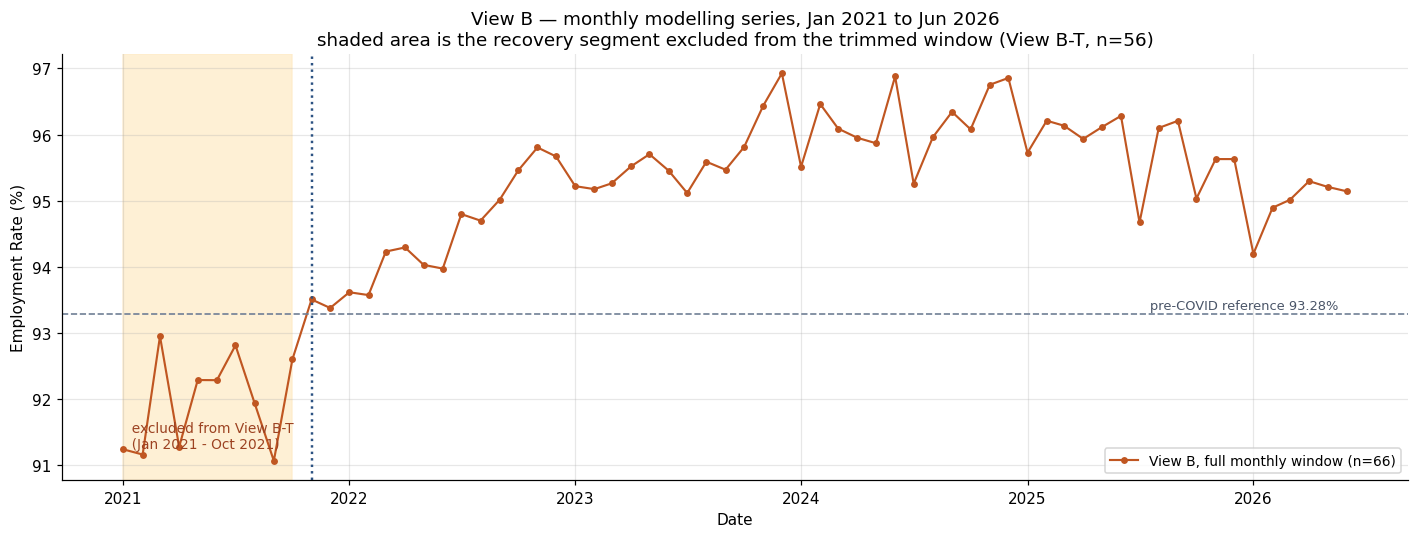

In [433]:
fig, ax = plt.subplots(figsize=(13, 5))

ax.axvspan(series_b.index.min(), RECOVERY_END, color="#feebc8", alpha=0.75, zorder=0)
ax.text(series_b.index.min(), series_b.min() + 0.15,
        f"  excluded from View B-T\n  ({series_b.index.min():%b %Y} - {RECOVERY_END:%b %Y})",
        fontsize=9, color="#9c4221", va="bottom")

ax.plot(series_b.index, series_b.values, color="#c05621", lw=1.4, marker="o", ms=3.5,
        label=f"View B, full monthly window (n={len(series_b)})")
ax.axhline(PRE_COVID_REFERENCE, color="#718096", ls="--", lw=1.1)
ax.text(series_b.index.max(), PRE_COVID_REFERENCE + 0.08,
        f"pre-COVID reference {PRE_COVID_REFERENCE:.2f}%  ",
        fontsize=8.5, color="#4a5568", ha="right")
ax.axvline(TRIM_START, color="#2c5282", ls=":", lw=1.6)

ax.set_xlabel("Date")
ax.set_ylabel("Employment Rate (%)")
ax.set_title(f"View B — monthly modelling series, {series_b.index.min():%b %Y} to "
             f"{series_b.index.max():%b %Y}\n"
             f"shaded area is the recovery segment excluded from the trimmed window "
             f"(View B-T, n={len(series_b_trim)})")
ax.legend(loc="lower right", fontsize=9)

fig.tight_layout()
plt.show()
save_fig(fig, "monthly_modeling_series.png")

#### Findings:

The shaded region shows the recovery segment excluded from View B-T. The contrast
across the dividing line is pronounced: a steep increase from approximately 91% to above the
reference level on the left, and a flatter, more irregular band exhibiting lateral movement in the
mid-nineties on the right.

#### Interpretation:

These segments differ sufficiently in behaviour that the choice of window could
plausibly alter what a model estimates. The earlier segment exhibits strong directional movement; the
later segment exhibits little. This is the visual justification for assessing both windows
in parallel.


## 10.1 Rolling level and variability

#### Objective:

Calculate the mean and standard deviation over a moving twelve-month window for both
series.

#### Rationale:

These are the most direct diagnostics for the two properties determining whether a
series may be modelled without transformation: a drifting mean and a changing dispersion. A
twelve-month window is specified so that each value spans a complete year and is not itself
distorted by seasonal variation.


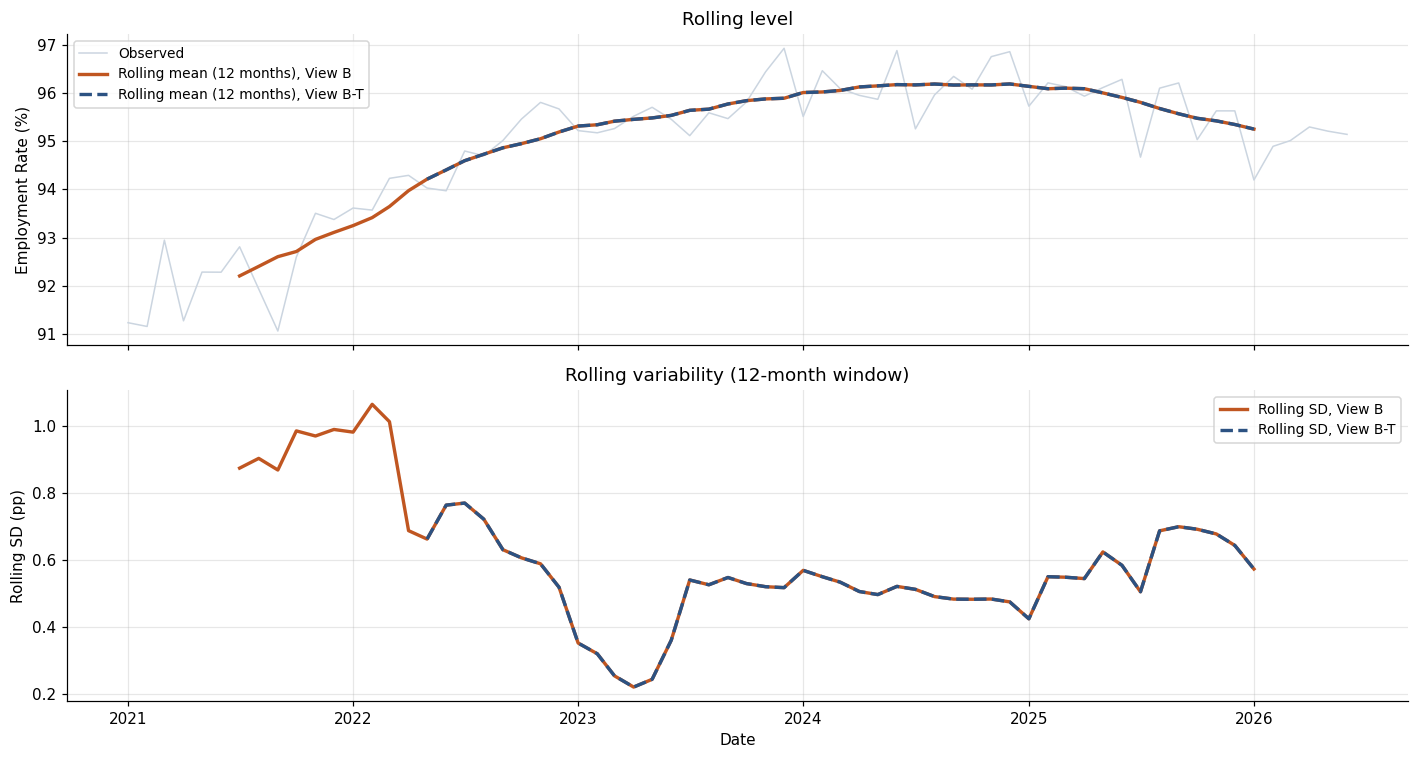

In [434]:
WIN_M = 12

fig, axes = plt.subplots(2, 1, figsize=(13, 7), sharex=True)

ax = axes[0]
ax.plot(series_b.index, series_b.values, color="#cbd5e0", lw=1.0, label="Observed")
ax.plot(series_b.rolling(WIN_M, center=True).mean(), color="#c05621", lw=2.2,
        label=f"Rolling mean ({WIN_M} months), View B")
ax.plot(series_b_trim.rolling(WIN_M, center=True).mean(), color="#2c5282", lw=2.2, ls="--",
        label=f"Rolling mean ({WIN_M} months), View B-T")
ax.set_ylabel("Employment Rate (%)")
ax.set_title("Rolling level")
ax.legend(fontsize=9)

ax = axes[1]
ax.plot(series_b.rolling(WIN_M, center=True).std(), color="#c05621", lw=2.2,
        label="Rolling SD, View B")
ax.plot(series_b_trim.rolling(WIN_M, center=True).std(), color="#2c5282", lw=2.2, ls="--",
        label="Rolling SD, View B-T")
ax.set_ylabel("Rolling SD (pp)")
ax.set_xlabel("Date")
ax.set_title(f"Rolling variability ({WIN_M}-month window)")
ax.legend(fontsize=9)

fig.tight_layout()
plt.show()
save_fig(fig, "rolling_statistics.png")

#### Findings:

The rolling mean increases steeply through 2021 and 2022, flattens markedly from
approximately 2023, and drifts moderately downward toward the end of the record. The trimmed series
starts at a higher level and exhibits a considerably less pronounced increase.

The rolling standard deviation supports Section 9.2 numerically: variability in the full window
is initially high and declines sharply as the recovery passes out of the window, whereas the trimmed
series remains consistently lower.

#### Interpretation:

The mean is **not constant**, moving substantially across the
window, which is the characteristic signature of a non-stationary series. Equally significant, the
flat recent segment indicates that the pronounced upward movement is a **historical property of the
recovery rather than an ongoing trend**.

#### Implication for the next step:

This provides direct evidence against specifications
incorporating an undamped linear trend, which would project the early increase indefinitely forward.
It also establishes a clear expectation against which the formal stationarity tests may be assessed.


## 10.2 Stationarity

#### Definition:

A series is stationary when its statistical properties remain stable over time —
approximately constant mean and variance throughout, without persistent drift.

#### Rationale:

Many forecasting procedures assume reversion to a stable level. Applied to a drifting
series, such procedures generate forecasts and uncertainty intervals that are incorrectly
calibrated. Where a series is not stationary, the standard remedy is **differencing**: modelling the
change between consecutive periods rather than the level itself. Period-to-period changes frequently
fluctuate about a stable mean even where the level does not. Both the levels and the first
differences are therefore tested.

#### Specification of two tests:

The Augmented Dickey-Fuller (ADF) and KPSS tests are applied jointly
because their null hypotheses are opposed. ADF assumes non-stationarity and seeks evidence against
it; KPSS assumes stationarity and seeks evidence against that. Applying only one makes an
ambiguous outcome indistinguishable from a decisive one. Where both indicate the same conclusion the
finding is well supported; where they conflict, or where neither rejects, the evidence is
therefore weak. Given a short sample, this distinction is useful.

#### Interpretation of p-values:

A p-value expresses the probability of obtaining data at least as
extreme as that observed **if the null hypothesis were true**. It is not the probability that the
null hypothesis is true, nor the probability that the result arose by chance.


In [435]:
ALPHA = 0.05
windows = {
    f"View B (full, n={len(series_b)})": series_b,
    f"View B-T (trimmed, n={len(series_b_trim)})": series_b_trim,
}

rows = []
for label, s in windows.items():
    for diff_label, values in (("Levels", s), ("First difference", s.diff().dropna())):
        adf_stat, adf_p, adf_lags, adf_n, adf_crit, _ = adfuller(
            values.values, regression="c", autolag="AIC"
        )
        with warnings.catch_warnings():
            warnings.simplefilter("ignore")
            kpss_stat, kpss_p, kpss_lags, kpss_crit = kpss(
                values.values, regression="c", nlags="auto"
            )

        adf_reject = adf_p < ALPHA
        kpss_reject = kpss_p < ALPHA
        if adf_reject and not kpss_reject:
            verdict = "Both tests point to stationarity"
        elif not adf_reject and kpss_reject:
            verdict = "Both tests point to non-stationarity"
        elif adf_reject and kpss_reject:
            verdict = "Tests conflict (possible trend-stationarity)"
        else:
            verdict = "Tests inconclusive - series is not clearly either"

        rows.append(dict(
            Window=label, Transformation=diff_label, N=len(values),
            ADF_Statistic=round(adf_stat, 4), ADF_P=round(adf_p, 4),
            ADF_Lags=int(adf_lags),
            KPSS_Statistic=round(kpss_stat, 4), KPSS_P=round(kpss_p, 4),
            Combined_Verdict=verdict,
        ))

        record_test(
            stage=f"Series stationarity - {label}, {diff_label.lower()}",
            model="n/a - pre-modelling series diagnostic",
            test="Augmented Dickey-Fuller (constant, lag order by AIC)",
            purpose="Determine whether the series has a unit root and therefore requires "
                    "differencing before models assuming a stable mean can be applied",
            null_hypothesis="The series has a unit root (non-stationary)",
            alt_hypothesis="The series is stationary around a constant",
            statistic=round(float(adf_stat), 4), p_value=round(float(adf_p), 6), alpha=ALPHA,
            conclusion=("Reject the null at alpha=0.05" if adf_reject
                        else "Fail to reject the null at alpha=0.05"),
            interpretation=(
                "The data are consistent with a stationary series; direct modelling of the "
                "levels is defensible." if adf_reject else
                "There is insufficient evidence to rule out a unit root. This does not prove "
                "non-stationarity, and the test has low power on short samples."
            ),
        )
        record_test(
            stage=f"Series stationarity - {label}, {diff_label.lower()}",
            model="n/a - pre-modelling series diagnostic",
            test="KPSS (constant, automatic lag selection)",
            purpose="Provide a complementary test whose null is the opposite of the ADF null, "
                    "so that a genuinely ambiguous series can be distinguished from a clear one",
            null_hypothesis="The series is stationary around a constant",
            alt_hypothesis="The series has a unit root (non-stationary)",
            statistic=round(float(kpss_stat), 4), p_value=round(float(kpss_p), 6), alpha=ALPHA,
            conclusion=("Reject the null at alpha=0.05" if kpss_reject
                        else "Fail to reject the null at alpha=0.05"),
            interpretation=(
                "The data are not consistent with stationarity around a constant mean."
                if kpss_reject else
                "There is insufficient evidence to conclude the series is non-stationary; this "
                "does not prove stationarity. Note the reported p-value is clipped to the "
                "table range used by the test."
            ),
        )

stationarity_results = pd.DataFrame(rows)
display(stationarity_results)
print("KPSS p-values are reported from a lookup table and are clipped at its bounds")
print("(0.01 and 0.10); a value at a bound means 'at least as extreme as the table covers'.")

,Window,Transformation,N,ADF_Statistic,ADF_P,ADF_Lags,KPSS_Statistic,KPSS_P,Combined_Verdict
0,"View B (full, n=66)",Levels,66,-2.1765,0.2149,6,0.8134,0.0100,Both tests point to non-stationarity
1,"View B (full, n=66)",First difference,65,-3.1781,0.0213,5,0.3477,0.0997,Both tests point to stationarity
2,"View B-T (trimmed, n=56)",Levels,56,-2.3204,0.1655,6,0.5525,0.0299,Both tests point to non-stationarity
3,"View B-T (trimmed, n=56)",First difference,55,-2.6433,0.0844,5,0.3378,0.1000,Tests inconclusive - series is not clearly either


KPSS p-values are reported from a lookup table and are clipped at its bounds
(0.01 and 0.10); a value at a bound means 'at least as extreme as the table covers'.


#### Findings:

| Window | Form | ADF stat. | ADF p | KPSS stat. | KPSS p | Joint conclusion |
|---|---|---|---|---|---|---|
| View B | Levels | −2.18 | 0.215 | 0.813 | 0.010 | **Non-stationary** |
| View B | First difference | −3.18 | **0.021** | 0.348 | 0.100 | **Stationary** |
| View B-T | Levels | −2.32 | 0.165 | 0.553 | 0.030 | **Non-stationary** |
| View B-T | First difference | −2.64 | 0.084 | 0.338 | 0.100 | **Inconclusive** |

#### Interpretation:

*View B in levels.* ADF returns p = 0.215, exceeding 0.05, so its null hypothesis is not rejected
and non-stationarity cannot be excluded. KPSS returns p = 0.010, below 0.05, so its null hypothesis
of stationarity is rejected. Both tests concur: **the employment rate in levels is not stationary.**
This supports the rolling-mean evidence that the series drifts rather than fluctuating about a
fixed mean.

*View B differenced.* ADF returns p = 0.021, rejecting the unit-root null; KPSS returns p = 0.100,
failing to reject stationarity. Both concur that **month-to-month changes are stationary**.

*Practical consequence.* The employment level drifts whereas changes in it behave stably. Modelling
changes rather than levels is therefore appropriate, corresponding to a differencing order of
**d = 1** within the ARIMA family.

*View B-T.* The levels yield the same non-stationary conclusion, confirming that this finding does
not depend on the recovery observations. The differenced trimmed series, however, is
**inconclusive**: neither test rejects its null hypothesis (ADF p = 0.084, KPSS p = 0.100). This is
the anticipated consequence of a shorter and less variable sample. With the pronounced recovery
movement excluded, less signal remains for either test to detect.

#### Qualification on KPSS values:

KPSS p-values are obtained from a lookup table and are **bounded
at 0.01 and 0.10**. A reported value of 0.100 denotes "0.10 or greater" rather than exactly 0.10, and
no precision should be inferred at these bounds.

#### Implication for the next step:

Differencing is justified for ARIMA-family specifications. The
inconclusive trimmed-window result is an early indication that the shorter window may not
support confident model identification, a consideration in the eventual window selection.


## 10.3 Autocorrelation

#### Definition:

Autocorrelation refers to the correlation of a series with its own past values.
Autocorrelation at lag 1 measures the association between consecutive months; at lag 12, the
association between the same month in consecutive years.

#### Rationale:

Autocorrelation addresses the fundamental forecasting question of whether past values
convey information about future values. In its absence, no time-series specification can succeed.
The shapes of the autocorrelation function (ACF) and partial autocorrelation function (PACF)
additionally constitute the standard evidence for distinguishing model structures.

#### ACF and PACF distinguished:

The ACF reports total correlation at each lag, including association
transmitted indirectly: where January influences February and February influences March, the ACF at
lag 2 registers that chain. The PACF removes such intermediate transmission, reporting the direct
contribution of each lag. Comparing the two distinguishes genuine long memory from a short-range
effect propagating forward.

#### Distinction from residual diagnostics:

This assessment concerns autocorrelation **in the series
itself**, which is a desirable property because it is the basis on which forecasting is possible.
Section 18 examines autocorrelation in model **residuals**, where remaining structure is
undesirable because it indicates the model has failed to capture available information. The same
instrument supports opposite interpretations in the two contexts.


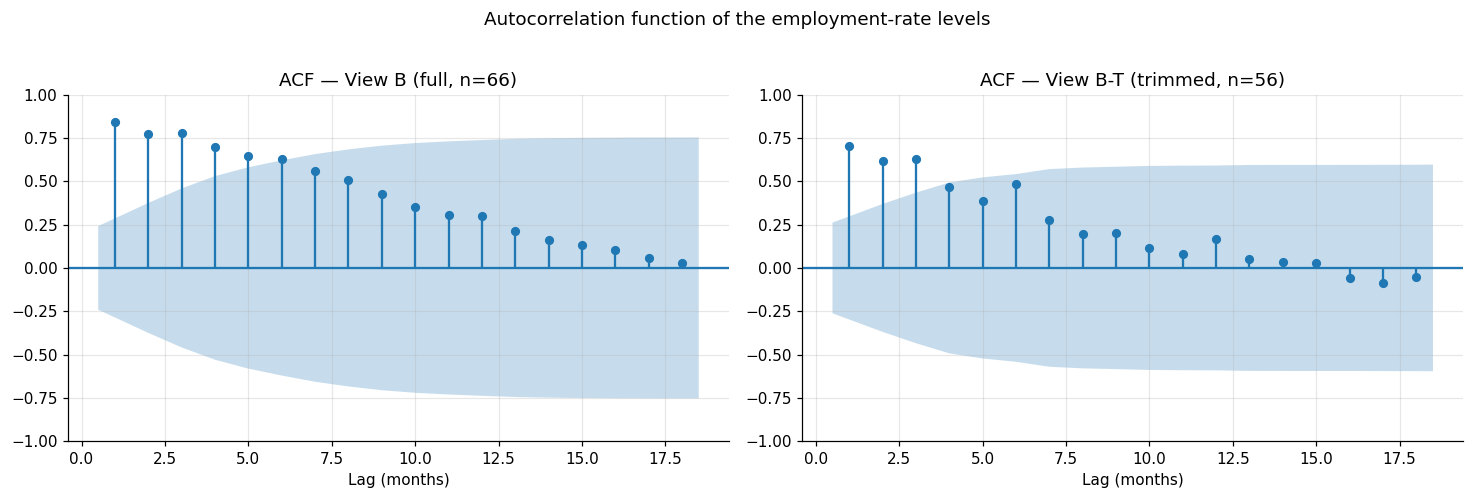

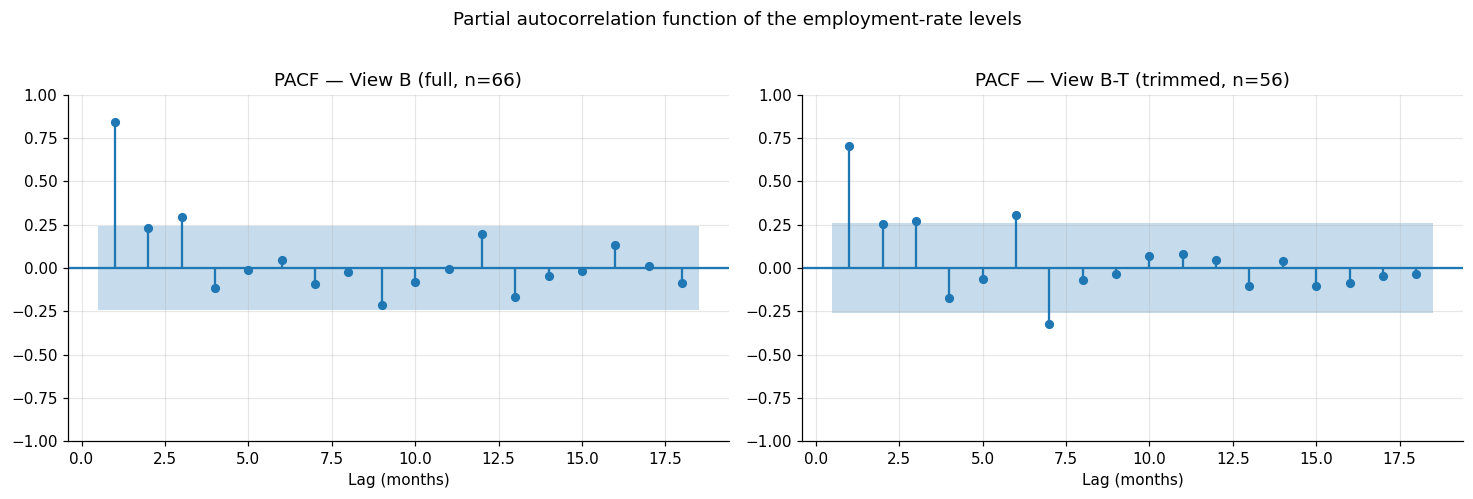

In [436]:
def acf_lags(s):
    return int(min(18, max(6, len(s) // 3)))


fig, axes = plt.subplots(1, 2, figsize=(13.5, 4.4))
for ax, (label, s) in zip(axes, windows.items()):
    plot_acf(s.values, lags=acf_lags(s), ax=ax, alpha=0.05, zero=False)
    ax.set_title(f"ACF — {label}")
    ax.set_xlabel("Lag (months)")
fig.suptitle("Autocorrelation function of the employment-rate levels", y=1.02, fontsize=12)
fig.tight_layout()
plt.show()
save_fig(fig, "acf.png")

fig, axes = plt.subplots(1, 2, figsize=(13.5, 4.4))
for ax, (label, s) in zip(axes, windows.items()):
    plot_pacf(s.values, lags=acf_lags(s), ax=ax, alpha=0.05, zero=False, method="ywm")
    ax.set_title(f"PACF — {label}")
    ax.set_xlabel("Lag (months)")
fig.suptitle("Partial autocorrelation function of the employment-rate levels",
             y=1.02, fontsize=12)
fig.tight_layout()
plt.show()
save_fig(fig, "pacf.png")

#### Findings:

In both windows the ACF is high at lag 1 and decays **slowly and smoothly** across many
lags rather than declining abruptly, with the early lags lying well outside the significance bounds.

The PACF exhibits a markedly different structure: a large coefficient at lag 1, beyond which
nearly all coefficients fall within the significance bounds.

#### Interpretation:

This combination — a slowly decaying ACF with a single dominant PACF coefficient
— is the characteristic signature of a series in which **each value is strongly associated with its
immediate predecessor**, with apparent long memory arising because that lag-1 association propagates
successively forward.

The slow ACF decay is additionally a recognised indication of non-stationarity, independently
corroborating Section 10.2.

#### Implication for the next step:

Two consequences follow. The pronounced lag-1 dependence supports
autoregressive components within ARIMA-family specifications. Because the apparent long memory is
principally the lag-1 effect propagating forward, a **low-order** specification is likely sufficient
— a important consideration given a sample of 66 observations.


#### Objective:

Use a formal test to assess autocorrelation across the first twelve lags.

#### Rationale:

The ACF is assessed visually, one lag at a time. The Ljung-Box test evaluates a single
combined hypothesis: whether significant autocorrelation is present across the first year of lags
considered jointly. Its null hypothesis states that the observations are independent, that is, that
no autocorrelation is present.


In [437]:
LB_LAGS = 12
rows = []
for label, s in windows.items():
    lb = acorr_ljungbox(s.values, lags=[LB_LAGS], return_df=True)
    stat = float(lb["lb_stat"].iloc[0])
    pval = float(lb["lb_pvalue"].iloc[0])
    reject = pval < ALPHA
    rows.append(dict(Window=label, Lags=LB_LAGS, LB_Statistic=round(stat, 4),
                     P_Value=round(pval, 6),
                     Conclusion="Reject the null" if reject else "Fail to reject the null"))
    record_test(
        stage=f"Series autocorrelation - {label}",
        model="n/a - pre-modelling series diagnostic",
        test=f"Ljung-Box test on the series levels ({LB_LAGS} lags)",
        purpose="Test whether the series carries usable temporal dependence, which would "
                "justify a time-series model over a simple mean-based forecast",
        null_hypothesis=f"The observations are independently distributed up to lag {LB_LAGS} "
                        f"(no autocorrelation)",
        alt_hypothesis=f"Autocorrelation is present at one or more lags up to {LB_LAGS}",
        statistic=round(stat, 4), p_value=round(pval, 6), alpha=ALPHA,
        conclusion="Reject the null at alpha=0.05" if reject else
                   "Fail to reject the null at alpha=0.05",
        interpretation=(
            "The series shows significant temporal dependence, so past values carry "
            "information useful for forecasting." if reject else
            "There is insufficient evidence of temporal dependence at these lags."
        ),
    )

ljung_box_series = pd.DataFrame(rows)
display(ljung_box_series)

,Window,Lags,LB_Statistic,P_Value,Conclusion
0,"View B (full, n=66)",12,312.4450,0.0000,Reject the null
1,"View B-T (trimmed, n=56)",12,128.6059,0.0000,Reject the null


#### Findings:

View B yields a Ljung-Box statistic of **312.4** with **p < 0.001**; View B-T yields
**128.6**, also with **p < 0.001**.

#### Interpretation:

Both p-values lie far below 0.05, so the null hypothesis of independence is
rejected. The series carries **strong temporal dependence**: past employment rates convey
substantial information regarding future values. The conclusion holds in both windows and therefore
does not depend on the recovery period.

#### Implication for the next step:

This result supports the modelling approach as a whole. A
time-series specification is clearly warranted, and a simple mean of past values would discard
informative structure.


## 10.4 Assessment of seasonality

#### Definition:

Seasonality denotes a pattern recurring at the same point in successive years — for
example, employment increasing reliably each December.

#### Rationale for scepticism:

Monthly observation frequency does not provide evidence of
seasonality. Adopting a seasonal specification without support would expend a substantial number of
parameters estimating a pattern that may not exist, and with approximately five and a half annual
cycles available this represents a clear risk of fitting noise.

#### Three-stage assessment:

The first two measures yield conflicting conclusions, and that conflict
is itself informative.

1. **STL decomposition** separates the series into trend, seasonal and remainder components, from
 which **seasonal strength** is computed: the proportion of non-trend variation attributable to
 the seasonal component. A widely cited convention treats values above approximately 0.64 as
 indicating strong seasonality.

2. **The Kruskal-Wallis test** assesses whether detrended values differ across calendar months.
 Detrending is essential: testing raw values would recover the trend and misattribute it to a
 month effect.

3. **Calibration**, required only because the first two conflict. The risk is specific. STL
 estimates a flexible, time-varying seasonal component, and on a short series that component may
 absorb ordinary noise and produce a substantial seasonal strength from data containing no month
 effect. The 0.64 convention was not established for samples of five years.


In [438]:
PERIOD = 12
rows = []
decompositions = {}

for label, s in windows.items():
    if len(s) < 2 * PERIOD:
        print(f"{label}: too short for a {PERIOD}-period decomposition; skipped.")
        continue

    res = STL(s, period=PERIOD, robust=True).fit()
    decompositions[label] = res

    var_resid = np.var(res.resid, ddof=1)
    var_seas_resid = np.var(res.seasonal + res.resid, ddof=1)
    strength = max(0.0, 1 - var_resid / var_seas_resid)

    detrended = (s - res.trend).dropna()
    groups = [detrended[detrended.index.month == m].values for m in range(1, 13)]
    groups = [g for g in groups if len(g) > 0]
    kw_stat, kw_p = stats.kruskal(*groups)

    rows.append(dict(
        Window=label, Cycles_Available=round(len(s) / PERIOD, 2),
        Seasonal_Strength=round(strength, 4),
        Seasonal_Amplitude_pp=round(float(res.seasonal.max() - res.seasonal.min()), 4),
        KW_Statistic=round(float(kw_stat), 4), KW_P=round(float(kw_p), 6),
        # Descriptive label from the rule-of-thumb thresholds only. This is NOT a
        # conclusion: it is calibrated against a permutation null in 10.4.1 before
        # any modelling decision is drawn from it.
        Strength_Label_Uncalibrated=("Strong" if strength > 0.64 else
                                     "Moderate" if strength > 0.40 else "Weak"),
    ))

    record_test(
        stage=f"Seasonality - {label}",
        model="n/a - pre-modelling series diagnostic",
        test="Kruskal-Wallis test on STL-detrended values grouped by calendar month",
        purpose="Test whether a month-of-year effect exists once the trend is removed, so that "
                "a seasonal model is adopted only if the evidence supports it",
        null_hypothesis="Detrended employment rate has the same distribution in every "
                        "calendar month",
        alt_hypothesis="At least one calendar month differs in distribution",
        statistic=round(float(kw_stat), 4), p_value=round(float(kw_p), 6), alpha=ALPHA,
        conclusion=("Reject the null at alpha=0.05" if kw_p < ALPHA
                    else "Fail to reject the null at alpha=0.05"),
        interpretation=(
            f"Seasonal strength = {strength:.3f}. " +
            ("Evidence of a month-of-year effect."
             if kw_p < ALPHA else
             f"There is insufficient evidence of a month-of-year effect from this test alone. "
             f"With only {len(s) / PERIOD:.1f} annual cycles and roughly "
             f"{len(s) // PERIOD} observations per calendar month, Kruskal-Wallis has low "
             f"power and discards the ordering information that the seasonal-strength "
             f"measure uses. A non-significant result here is absence of evidence, not "
             f"evidence of absence, and is not treated as decisive.")
        ),
    )

seasonality_results = pd.DataFrame(rows)
display(seasonality_results)
print("Note the tension: the strength measure and the formal test point in different")
print("directions. Neither is taken as the answer until calibrated in Section 10.4.1.")

,Window,Cycles_Available,Seasonal_Strength,Seasonal_Amplitude_pp,KW_Statistic,KW_P,Strength_Label_Uncalibrated
0,"View B (full, n=66)",5.5000,0.7092,2.6758,19.1454,0.0585,Strong
1,"View B-T (trimmed, n=56)",4.6700,0.6246,1.7039,18.2487,0.0760,Moderate


Note the tension: the strength measure and the formal test point in different
directions. Neither is taken as the answer until calibrated in Section 10.4.1.


#### Findings, and a clear conflict:

| Window | Cycles | Seasonal strength | Amplitude | Kruskal-Wallis p |
|---|---|---|---|---|
| View B | 5.5 | **0.709** | 2.68 pp | **0.059** |
| View B-T | 4.7 | 0.625 | 1.70 pp | 0.076 |

These measures indicate **opposite conclusions**. For View B the strength of 0.709 exceeds the 0.64
convention, indicating substantial seasonality. The Kruskal-Wallis p-value of 0.059 exceeds 0.05,
however, so that test does not detect a month effect.

#### Why neither may simply be adopted:

Accepting the strength measure requires reliance on a threshold
not established for a five-year sample. Accepting the test result entails concluding that seasonality
is absent from a test with minimal power, given approximately five observations per calendar month.
Neither result is sufficient on its own, and they imply opposite modelling decisions.

#### Implication for the next step:

The conflict is resolved by evidence rather than by selecting the
more convenient conclusion.


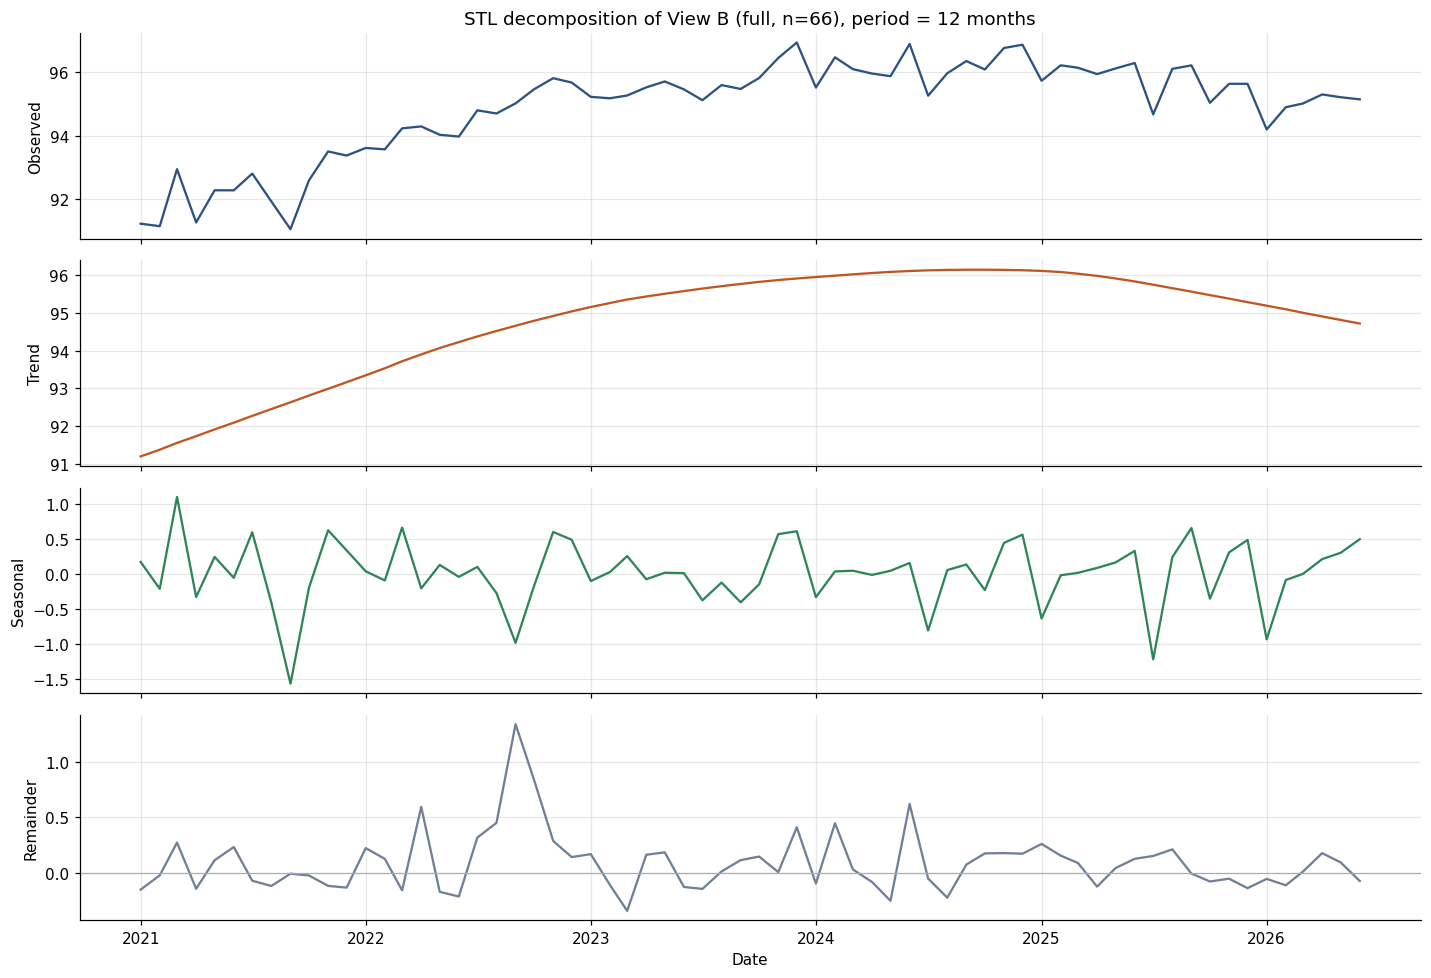

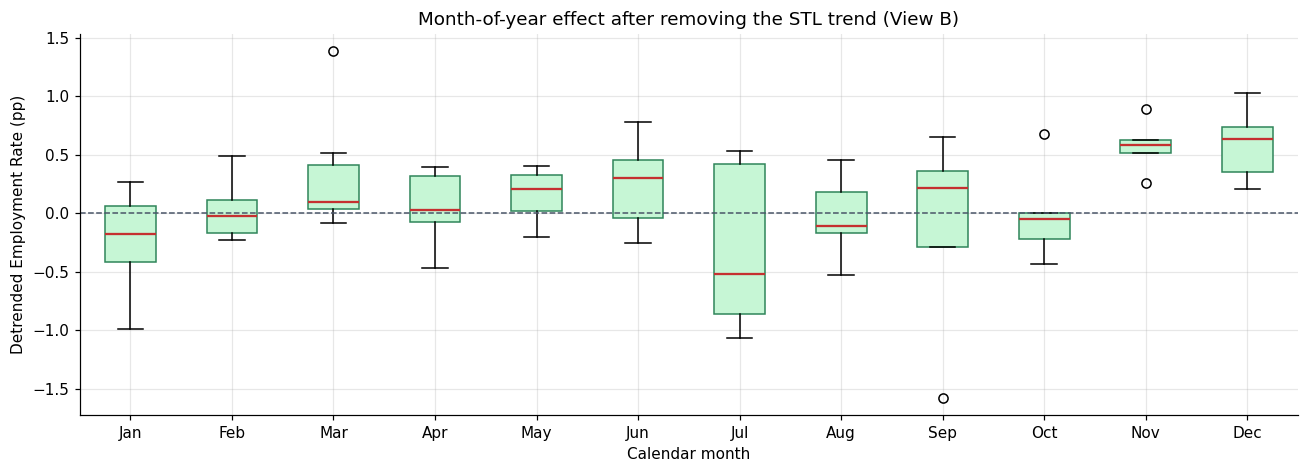

In [439]:
main_label = list(windows)[0]
res = decompositions[main_label]

fig, axes = plt.subplots(4, 1, figsize=(13, 9), sharex=True)
for ax, (values, title, colour) in zip(
    axes,
    [(series_b, "Observed", "#2c5282"),
     (res.trend, "Trend", "#c05621"),
     (res.seasonal, "Seasonal", "#2f855a"),
     (res.resid, "Remainder", "#718096")],
):
    ax.plot(values.index, values.values, color=colour, lw=1.5)
    ax.set_ylabel(title)
axes[0].set_title(f"STL decomposition of {main_label}, period = {PERIOD} months")
axes[-1].axhline(0, color="#a0aec0", lw=0.8)
axes[-1].set_xlabel("Date")
fig.tight_layout()
plt.show()
save_fig(fig, "seasonal_decomposition.png")

fig, ax = plt.subplots(figsize=(12, 4.4))
detrended = (series_b - res.trend).dropna()
ax.boxplot([detrended[detrended.index.month == m].values for m in range(1, 13)],
           tick_labels=[pd.Timestamp(2000, m, 1).strftime("%b") for m in range(1, 13)],
           patch_artist=True,
           boxprops=dict(facecolor="#c6f6d5", edgecolor="#2f855a"),
           medianprops=dict(color="#c53030", lw=1.5))
ax.axhline(0, color="#4a5568", ls="--", lw=1.0)
ax.set_ylabel("Detrended Employment Rate (pp)")
ax.set_xlabel("Calendar month")
ax.set_title("Month-of-year effect after removing the STL trend (View B)")
fig.tight_layout()
plt.show()
save_fig(fig, "seasonality.png")

#### Findings:

The trend component captures the recovery increase and its subsequent flattening. The
seasonal component exhibits a **regular recurring pattern of consistent form across years**. The
remainder is small relative to the other components.

The month-effect distribution indicates that November and December lie clearly above zero with
narrow dispersion, and October below zero, also with narrow dispersion. July and September exhibit
wide dispersion, denoting large but inconsistent effects.

#### Interpretation:

The pattern appears regular, but apparent regularity is specifically what a
flexible smoother produces from noise. The following section tests this directly.


### 10.4.1 Calibration of the seasonal-strength measure

#### Objective:

Determine whether a seasonal strength of 0.709 is unusual for a series of
this length, or approximately what STL produces from any short series regardless of seasonality.

#### Method:

A reference distribution is constructed by permutation. The detrended values are randomly
reordered across time, eliminating any month-of-year pattern while leaving the trend and the set of
values unaltered. Seasonal strength is then recomputed on each reordered series using the identical
STL procedure, and the process is repeated 500 times.

This yields the distribution the measure produces when **no seasonality is present**, at this sample
size and under this method. The comparison is valid because the reordered data havees the same
length, the same trend and the same values; only the month structure is removed.

The **permutation p-value** is the proportion of reordered series attaining a strength at least as
high as that observed. A fixed random seed ensures reproducibility.


In [440]:
N_PERMUTATIONS = 500
SEED = 20260906


def seasonal_strength_of(series, period=PERIOD):
    fit = STL(series, period=period, robust=True).fit()
    var_r = np.var(fit.resid, ddof=1)
    var_sr = np.var(fit.seasonal + fit.resid, ddof=1)
    return max(0.0, 1 - var_r / var_sr), fit


rng = np.random.default_rng(SEED)
perm_rows = []
null_draws = {}

for label, s in windows.items():
    observed_strength, fit = seasonal_strength_of(s)
    trend_values = fit.trend.to_numpy()
    detrended_values = (s - fit.trend).to_numpy()

    draws = np.empty(N_PERMUTATIONS)
    for i in range(N_PERMUTATIONS):
        shuffled = pd.Series(trend_values + rng.permutation(detrended_values), index=s.index)
        draws[i], _ = seasonal_strength_of(shuffled)
    null_draws[label] = draws

    perm_p = float((draws >= observed_strength).mean())
    perm_rows.append(dict(
        Window=label,
        Observed_Strength=round(observed_strength, 4),
        Null_Mean_Strength=round(float(draws.mean()), 4),
        Null_95th_Pct=round(float(np.percentile(draws, 95)), 4),
        Permutation_P=round(perm_p, 4),
        Exceeds_Null=bool(observed_strength > np.percentile(draws, 95)),
    ))

    record_test(
        stage=f"Seasonality calibration - {label}",
        model="n/a - pre-modelling series diagnostic",
        test=f"Permutation test on STL seasonal strength ({N_PERMUTATIONS} permutations, "
             f"seed {SEED})",
        purpose="Determine whether the observed seasonal strength exceeds what the same STL "
                "procedure produces on data of identical length and trend but with the "
                "month-of-year structure destroyed",
        null_hypothesis="There is no month-of-year effect; the observed seasonal strength is "
                        "no larger than that produced by randomly reordered values",
        alt_hypothesis="The observed seasonal strength is larger than the no-seasonality "
                       "reference distribution",
        statistic=round(observed_strength, 4),
        p_value=round(perm_p, 6),
        alpha=ALPHA,
        conclusion=("Reject the null at alpha=0.05" if perm_p < ALPHA
                    else "Fail to reject the null at alpha=0.05"),
        interpretation=(
            f"Observed strength {observed_strength:.4f} against a null mean of "
            f"{draws.mean():.4f} and a 95th percentile of {np.percentile(draws, 95):.4f}. "
            + ("The observed value is well outside the range produced without a month effect, "
               "so the seasonal signal is not an artifact of fitting a flexible seasonal "
               "component to a short series."
               if perm_p < ALPHA else
               "The observed value falls within the range produced without any month effect, "
               "indicating the strength measure is inflated by STL fitting noise rather than "
               "reflecting genuine seasonality.")
        ),
    )

permutation_results = pd.DataFrame(perm_rows)
display(permutation_results)

perm_b = permutation_results.iloc[0]
print(f"Rule-of-thumb reading  : strength {perm_b['Observed_Strength']} exceeds the 0.64 "
      f"'strong' threshold")
print(f"Calibrated reading     : a no-seasonality series of this length typically produces "
      f"{perm_b['Null_Mean_Strength']}, and reaches {perm_b['Null_95th_Pct']} only 5% of "
      f"the time")

,Window,Observed_Strength,Null_Mean_Strength,Null_95th_Pct,Permutation_P,Exceeds_Null
0,"View B (full, n=66)",0.7092,0.2257,0.4727,0.0000,True
1,"View B-T (trimmed, n=56)",0.6246,0.2209,0.5025,0.0040,True


Rule-of-thumb reading  : strength 0.7092 exceeds the 0.64 'strong' threshold
Calibrated reading     : a no-seasonality series of this length typically produces 0.2257, and reaches 0.4727 only 5% of the time


#### Findings:

| Window | Observed | Null mean | Null 95th percentile | Permutation p |
|---|---|---|---|---|
| View B | 0.709 | 0.226 | 0.473 | **< 0.001** |
| View B-T | 0.625 | 0.221 | 0.503 | **0.004** |

#### Interpretation:

The results show a clear difference from the reference distribution. A series of this length containing **no** month effect
typically produces a seasonal strength of approximately **0.23**, attaining 0.47 in only 5% of cases.
The observed value of **0.709** lies far beyond that range, yielding a permutation p-value below
0.001. The trimmed window independently supports the finding at p = 0.004.

The seasonal signal is therefore supported by the calibration and not an artefact of estimating a flexible seasonal
component on a short series.

#### Explanation of the Kruskal-Wallis result:

Two considerations account for the discrepancy, both
concerning statistical power rather than the data. With approximately five observations per calendar
month the test havees minimal capacity to detect a moderate effect. Further, it operates on ranks
within groups and discards the structure the strength measure exploits. **Absence of evidence from a
low-power test does not provide evidence of absence.**


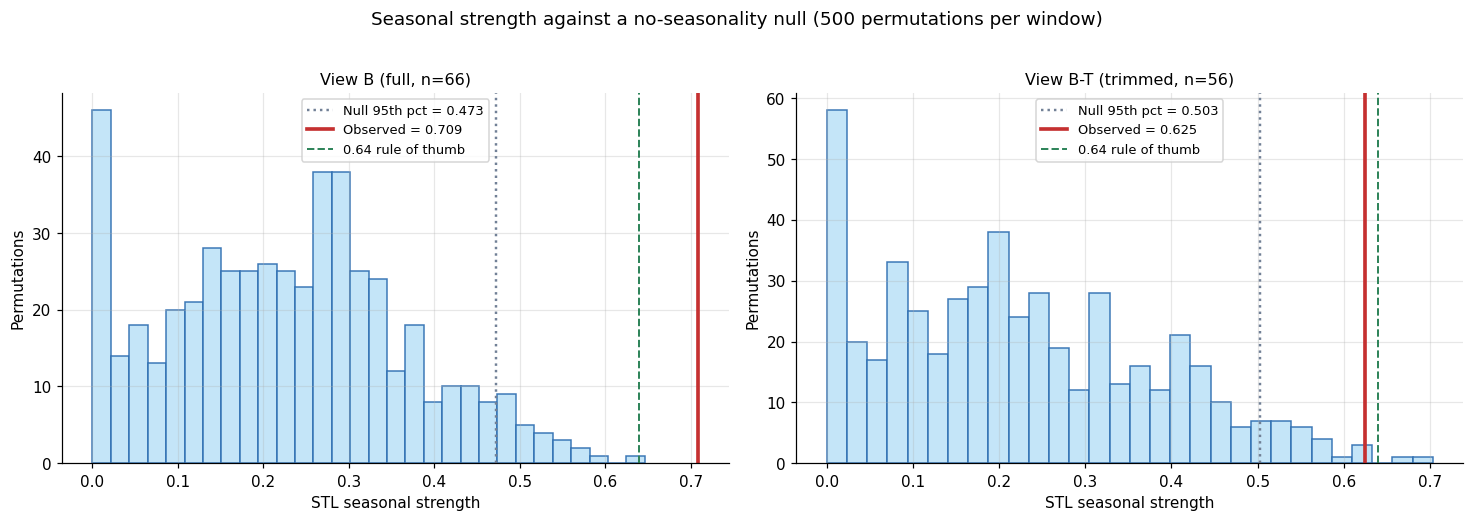

In [441]:
fig, axes = plt.subplots(1, 2, figsize=(13.5, 4.6))

for ax, (label, draws) in zip(axes, null_draws.items()):
    obs_val = permutation_results.loc[
        permutation_results["Window"] == label, "Observed_Strength"].iloc[0]
    ax.hist(draws, bins=30, color="#bee3f8", edgecolor="#2b6cb0", alpha=0.9)
    ax.axvline(np.percentile(draws, 95), color="#718096", ls=":", lw=1.6,
               label=f"Null 95th pct = {np.percentile(draws, 95):.3f}")
    ax.axvline(obs_val, color="#c53030", lw=2.4,
               label=f"Observed = {obs_val:.3f}")
    ax.axvline(0.64, color="#2f855a", ls="--", lw=1.3, label="0.64 rule of thumb")
    ax.set_xlabel("STL seasonal strength")
    ax.set_ylabel("Permutations")
    ax.set_title(label, fontsize=10.5)
    ax.legend(fontsize=8.5)

fig.suptitle(f"Seasonal strength against a no-seasonality null "
             f"({N_PERMUTATIONS} permutations per window)", y=1.02, fontsize=12)
fig.tight_layout()
plt.show()
save_fig(fig, "seasonality_calibration.png")

#### Findings:

The histogram presents the distribution of seasonal strength across 500 reordered
series containing no month effect. The solid vertical line denotes the observed value and the dashed
line the 0.64 convention.

The results show that **the 0.64 convention lies within the reference distribution in both
panels.** Random variation at this sample size regularly produces strengths above 0.64, making the
threshold uninformative here and establishing the necessity of calibration.

The right-hand panel provides an additional comparison. The observed strength for View B-T, 0.625, lies **below**
the 0.64 convention yet clearly outside its reference distribution (p = 0.004). The convention would
therefore classify it as not strong while the calibrated evidence establishes it as clearly
genuine. The threshold misclassifies in both directions.


### 10.4.2 Stability of the seasonal pattern

#### Objective:

Determine whether the seasonal pattern is sufficiently stable across years to support
forecasting.

#### Rationale:

Establishing existence is insufficient. A seasonal effect may be large but irregular,
differing between years, which would elevate the strength measure while providing no forecasting
value. The relevant property for forecasting is whether specific months move in the same direction by
a comparable magnitude in successive years.

For each calendar month the mean seasonal effect is computed together with the variation of that
effect **across years**. A month is informative only where its mean effect is important and its
year-to-year variation small, a construction analogous to a signal-to-noise ratio.


In [442]:
res_full = decompositions[list(windows)[0]]
seasonal_component = res_full.seasonal

seasonal_profile = (
    seasonal_component.groupby(seasonal_component.index.month)
    .agg(Mean_Effect_pp="mean", SD_Across_Years="std", N_Years="size")
    .reset_index()
    .rename(columns={"Period": "Month_Num"})
)
seasonal_profile.columns = ["Month_Num", "Mean_Effect_pp", "SD_Across_Years", "N_Years"]
seasonal_profile["Month"] = [
    pd.Timestamp(2000, int(m), 1).strftime("%B") for m in seasonal_profile["Month_Num"]
]
# A month is "consistent" when its average effect is large relative to how much it
# varies between years - the same logic as a signal-to-noise ratio.
seasonal_profile["Consistency"] = (
    seasonal_profile["Mean_Effect_pp"].abs() / seasonal_profile["SD_Across_Years"]
)
seasonal_profile = seasonal_profile[
    ["Month", "Mean_Effect_pp", "SD_Across_Years", "Consistency", "N_Years"]
].round(4)

display(seasonal_profile)

stable = seasonal_profile[
    (seasonal_profile["Consistency"] > 1.5) & (seasonal_profile["Mean_Effect_pp"].abs() > 0.15)
].sort_values("Mean_Effect_pp", ascending=False)

STABLE_MONTHS_TEXT = ", ".join(
    f"{r.Month[:3]} {r.Mean_Effect_pp:+.2f}pp" for r in stable.itertuples()
) if len(stable) else "none met the consistency criterion"

SEASONAL_STABILITY_VERDICT = (
    f"{len(stable)} of 12 months show a consistent, repeating effect"
    if len(stable) else "No month shows a consistently repeating effect"
)

print(f"Months with |mean effect| > 0.15pp and consistency > 1.5: {len(stable)}")
print(f"  {STABLE_MONTHS_TEXT}")

,Month,Mean_Effect_pp,SD_Across_Years,Consistency,N_Years
0,January,-0.2960,0.4237,0.6985,6
1,February,-0.0540,0.0935,0.5768,6
2,March,0.3523,0.4475,0.7871,6
3,April,-0.0505,0.1964,0.2573,6
4,May,0.1548,0.1110,1.3954,6
5,June,0.1540,0.2247,0.6853,6
6,July,-0.3384,0.7205,0.4696,5
7,August,-0.0987,0.2587,0.3815,5
8,September,-0.4305,0.8831,0.4875,5
9,October,-0.2166,0.0811,2.6718,5


Months with |mean effect| > 0.15pp and consistency > 1.5: 3
  Nov +0.51pp, Dec +0.50pp, Oct -0.22pp


#### Findings:

The months separate distinctly into reliable and unreliable.

| Month | Mean effect | SD across years | Consistency |
|---|---|---|---|
| **December** | **+0.50 pp** | 0.10 | **4.85** |
| **November** | **+0.51 pp** | 0.13 | **3.89** |
| **October** | **−0.22 pp** | 0.08 | **2.67** |
| May | +0.15 pp | 0.11 | 1.40 |
| September | −0.43 pp | 0.88 | 0.49 |
| July | −0.34 pp | 0.72 | 0.47 |

#### Interpretation:

Three months exhibit a dependable recurring pattern. **November and December lie
approximately half a percentage point above trend**, with year-to-year variation of approximately
0.1 percentage points. **October lies approximately 0.22 percentage points below trend** and is the
most consistent of the three relative to its magnitude.

July and September show a different pattern. Both have larger mean effects than October,
but their year-to-year standard deviations, 0.72 and 0.88, **exceed the effects themselves**. Their
variation between years is too great to support reliance.

#### Economic coherence:

The pattern has a plausible economic interpretation, which is important
since a statistically present but economically inexplicable pattern would call for more caution.
An October decline followed by November and December increases is consistent with **holiday-season
recruitment** in Philippine retail, logistics and hospitality, where seasonal staff are engaged in
advance of the Christmas period. The pattern is therefore coherent rather than arbitrary.

#### Relevance to the business problem:

This is the first result with a direct operational
reading. If employment reliably increases in November and December, recruitment activity concentrates
in those months, and pre-employment medical examinations are ordinarily required in advance of
engagement. The relevant activity window for a clinic may therefore precede the employment maximum.
This is advanced as a hypothesis consistent with the evidence, **not** as an established property of
PEME volumes, which this dataset does not measure.


In [443]:
perm_p_b = float(perm_b["Permutation_P"])
kw_p_b = float(seasonality_results.iloc[0]["KW_P"])

if perm_p_b < ALPHA and len(stable) >= 2:
    SEASONALITY_VERDICT = "Supported by evidence - seasonal candidates admitted"
elif perm_p_b < ALPHA:
    SEASONALITY_VERDICT = "Present but unstable - seasonal candidates admitted with caution"
else:
    SEASONALITY_VERDICT = "Not supported by evidence - seasonal candidates excluded"

print("SEASONALITY VERDICT")
print("=" * 60)
print(f"Permutation-calibrated strength test : p = {perm_p_b:.4f}")
print(f"Kruskal-Wallis on detrended values   : p = {kw_p_b:.4f}")
print(f"Months with a stable repeating effect: {len(stable)}")
print()
print(f"-> {SEASONALITY_VERDICT}")

SEASONALITY VERDICT
Permutation-calibrated strength test : p = 0.0000
Kruskal-Wallis on detrended values   : p = 0.0585
Months with a stable repeating effect: 3

-> Supported by evidence - seasonal candidates admitted


#### Conclusion: seasonality is supported by evidence, and seasonal candidates are admitted:

#### Assessment of the alternative procedures:

Adopting the 0.64 convention under the stated checks
would have indicated strong seasonality without establishing whether that threshold is meaningful at
this sample size. Adopting the non-significant Kruskal-Wallis result under the stated checks would
have excluded seasonal specifications entirely. Neither result is sufficient on its own and imply opposite
conclusions. Only the calibration resolves the question.

#### Implication for the next step and its limits:

Seasonal specifications — seasonal naive,
Holt-Winters and SARIMA — are supported as candidates by the evidence. Support as a candidate does not determine final selection.
Approximately five annual cycles are available, so any seasonal specification must remain
**parsimonious** and must additionally outperform simpler non-seasonal alternatives in out-of-sample
validation before being selected. The permutation test shows that the pattern is not noise; it
does not show that the pattern will persist, nor that a seasonal specification will forecast
more accurately than a simpler one.


## 10.5 Register of formal tests

#### Objective:

Summarize every formal test into a single table for export.

#### Rationale:

Documented assumption and diagnostic testing is a formal requirement of this
assignment. Subsequent sections append their residual diagnostics to the same register, so that the
exported file reflects the complete set of tests executed.


In [444]:
assumption_tests = pd.DataFrame(ASSUMPTION_TESTS)
display(assumption_tests[["Stage", "Test", "Statistic", "P_Value",
                          "Significance_Level", "Conclusion"]])
save_table(assumption_tests, "assumption_tests.csv")

,Stage,Test,Statistic,P_Value,Significance_Level,Conclusion
0,"Structural context (View C, equally spaced)",Levene's test for equality of variances (media...,3.6021,0.0616,0.0500,Fail to reject the null at alpha=0.05
1,"Series stationarity - View B (full, n=66), levels","Augmented Dickey-Fuller (constant, lag order b...",-2.1765,0.2149,0.0500,Fail to reject the null at alpha=0.05
2,"Series stationarity - View B (full, n=66), levels","KPSS (constant, automatic lag selection)",0.8134,0.0100,0.0500,Reject the null at alpha=0.05
3,"Series stationarity - View B (full, n=66), fir...","Augmented Dickey-Fuller (constant, lag order b...",-3.1781,0.0213,0.0500,Reject the null at alpha=0.05
4,"Series stationarity - View B (full, n=66), fir...","KPSS (constant, automatic lag selection)",0.3477,0.0997,0.0500,Fail to reject the null at alpha=0.05
5,"Series stationarity - View B-T (trimmed, n=56)...","Augmented Dickey-Fuller (constant, lag order b...",-2.3204,0.1655,0.0500,Fail to reject the null at alpha=0.05
6,"Series stationarity - View B-T (trimmed, n=56)...","KPSS (constant, automatic lag selection)",0.5525,0.0299,0.0500,Reject the null at alpha=0.05
7,"Series stationarity - View B-T (trimmed, n=56)...","Augmented Dickey-Fuller (constant, lag order b...",-2.6433,0.0844,0.0500,Fail to reject the null at alpha=0.05
8,"Series stationarity - View B-T (trimmed, n=56)...","KPSS (constant, automatic lag selection)",0.3378,0.1000,0.0500,Fail to reject the null at alpha=0.05
9,"Series autocorrelation - View B (full, n=66)",Ljung-Box test on the series levels (12 lags),312.4450,0.0000,0.0500,Reject the null at alpha=0.05


## 10.6 Findings carried into the forecasting design

#### Objective:

Summarize the structural findings that determine the forecasting design, computed
from the result objects rather than restated manually so that the summary cannot diverge from the
evidence.


In [445]:
adf_levels_b = stationarity_results.query(
    "Window.str.startswith('View B (') and Transformation == 'Levels'"
).iloc[0]
adf_diff_b = stationarity_results.query(
    "Window.str.startswith('View B (') and Transformation == 'First difference'"
).iloc[0]
adf_levels_t = stationarity_results.query(
    "Window.str.startswith('View B-T') and Transformation == 'Levels'"
).iloc[0]
seas_b = seasonality_results.iloc[0]
lb_b = ljung_box_series.iloc[0]

findings = pd.DataFrame(
    [
        dict(Question="Does the series carry usable temporal dependence?",
             Evidence=f"Ljung-Box({LB_LAGS}) on View B levels: statistic "
                      f"{lb_b['LB_Statistic']}, p = {lb_b['P_Value']}",
             Finding=lb_b["Conclusion"],
             Implication="Determines whether a time-series model is warranted at all"),
        dict(Question="Is View B stationary in levels?",
             Evidence=f"ADF p = {adf_levels_b['ADF_P']}, KPSS p = {adf_levels_b['KPSS_P']}",
             Finding=adf_levels_b["Combined_Verdict"],
             Implication="Determines whether differencing is required"),
        dict(Question="Is View B stationary after first differencing?",
             Evidence=f"ADF p = {adf_diff_b['ADF_P']}, KPSS p = {adf_diff_b['KPSS_P']}",
             Finding=adf_diff_b["Combined_Verdict"],
             Implication="Determines the differencing order d for ARIMA-family models"),
        dict(Question="Does trimming the recovery change the stationarity conclusion?",
             Evidence=f"View B-T levels: ADF p = {adf_levels_t['ADF_P']}, "
                      f"KPSS p = {adf_levels_t['KPSS_P']}",
             Finding=("Same conclusion as the full window"
                      if adf_levels_t["Combined_Verdict"] == adf_levels_b["Combined_Verdict"]
                      else "Differs from the full window"),
             Implication="Indicates how sensitive the structural reading is to the "
                         "recovery observations"),
        dict(Question="Is seasonality supported by evidence?",
             Evidence=f"Seasonal strength {seas_b['Seasonal_Strength']} vs permutation-null "
                      f"mean {perm_b['Null_Mean_Strength']} (95th pct "
                      f"{perm_b['Null_95th_Pct']}), permutation p = {perm_b['Permutation_P']}; "
                      f"Kruskal-Wallis p = {seas_b['KW_P']}",
             Finding=SEASONALITY_VERDICT,
             Implication="Determines whether seasonal candidates may enter the model set"),
        dict(Question="Is the seasonal pattern stable enough to model?",
             Evidence=f"Most consistent months: {STABLE_MONTHS_TEXT}",
             Finding=SEASONAL_STABILITY_VERDICT,
             Implication="Distinguishes a usable recurring pattern from a strength measure "
                         "inflated by a few irregular years"),
    ]
)
display(findings)
save_table(findings, "series_structure_findings.csv")

,Question,Evidence,Finding,Implication
0,Does the series carry usable temporal dependence?,Ljung-Box(12) on View B levels: statistic 312....,Reject the null,Determines whether a time-series model is warr...
1,Is View B stationary in levels?,"ADF p = 0.2149, KPSS p = 0.01",Both tests point to non-stationarity,Determines whether differencing is required
2,Is View B stationary after first differencing?,"ADF p = 0.0213, KPSS p = 0.0997",Both tests point to stationarity,Determines the differencing order d for ARIMA-...
3,Does trimming the recovery change the stationa...,"View B-T levels: ADF p = 0.1655, KPSS p = 0.0299",Same conclusion as the full window,Indicates how sensitive the structural reading...
4,Is seasonality supported by evidence?,Seasonal strength 0.7092 vs permutation-null m...,Supported by evidence - seasonal candidates ad...,Determines whether seasonal candidates may ent...
5,Is the seasonal pattern stable enough to model?,"Most consistent months: Nov +0.51pp, Dec +0.50...","3 of 12 months show a consistent, repeating ef...",Distinguishes a usable recurring pattern from ...


#### Five findings determine the forecasting design:

#### 1. The series carries strong usable memory:

Ljung-Box p < 0.001 in both windows. A time-series
specification is clearly justified.

#### 2. The employment level is non-stationary while month-to-month changes are stationary:

Confirmed
by concurrence of ADF and KPSS in both directions. Specifications should operate on **differences**
rather than levels, corresponding to differencing order **d = 1**.

#### 3. This conclusion does not depend on the recovery period:

View B-T yields the same
non-stationary conclusion in levels, so the structural finding is robust to window selection. Its
differenced result is inconclusive, however, indicating that the shorter window carries less
information.

#### 4. Autocorrelation is dominated by a single lag:

A slowly decaying ACF combined with one large
PACF coefficient indicates strong month-to-month dependence and supports **low-order** autoregressive
structure, appropriate given the sample size.

#### 5. Seasonality is genuine, concentrated and economically coherent:

Established by permutation
calibration rather than by convention, and comprising a consistent October decline with November and
December increases.

#### Matters remaining open:

No selection was made between View B and View B-T, no candidate set was fixed, and no model was estimated. These decisions belong to the forecasting design,
where they can be resolved against out-of-sample evidence rather than in-sample structure alone.


---

# 11. Forecasting Design

#### Objective:

Fix the terms of the forecasting exercise — the series, the horizon, the validation
procedure and the criteria for model selection — before any model is estimated.

#### Rationale:

These terms are fixed before any model is estimated, so model output cannot shape the evaluation design. Were the
horizon, the metric or the validation scheme chosen after inspecting model output, the reported
accuracy would reflect the selection procedure rather than the forecasting capability of the model,
and would not be a credible guide to future performance.

#### Design principles adopted:

*Validation must respect chronological order.* Randomly partitioning observations into training and
testing sets, as is conventional in cross-sectional work, would permit a model to be estimated using
observations after those it is asked to predict. The resulting accuracy would be
not achievable in real forecasting, since a forecast must be produced without knowledge of the future. All
validation in this study therefore trains exclusively on observations preceding the evaluation
period.

*Complexity must be justified by the sample.* The primary series contains 66 observations. Each
parameter estimated consumes information, and an over-parameterised specification will reproduce the
training data closely while forecasting poorly — a failure mode that in-sample fit statistics cannot
detect. The candidate set is therefore restricted to low-order specifications.

*Simple benchmarks must be included and should be competitive.* A forecasting model has
useful only if it outperforms the assumption that next month resembles this month. Three
such benchmarks are included and are evaluated on identical terms to the more complex candidates.

*The selection criterion is out-of-sample accuracy, not in-sample fit.* Information criteria such as
AIC are used only to select the order of a specification within its own family, where the comparison
is like-for-like. Selection across families is decided by forecast error on data withheld from
estimation.


In [446]:
from statsmodels.tsa.arima.model import ARIMA
from statsmodels.tsa.exponential_smoothing.ets import ETSModel

# ---- Design constants, fixed before any model is estimated -------------------
TEST_H       = 12   # holdout length: one full year, so every calendar month is evaluated
RO_MIN_TRAIN = 42   # smallest training set used in rolling-origin validation (3.5 cycles)
RO_H         = 12   # horizons evaluated at each rolling origin
FORECAST_H   = 6    # length of the final future forecast (justified in Section 15.2)
CI_LEVEL     = 0.05 # 95% forecast intervals

design = pd.DataFrame([
    dict(Element="Primary series",
         Specification=f"View B - monthly, {series_b.index.min():%b %Y} to "
                       f"{series_b.index.max():%b %Y} (n={len(series_b)})",
         Justification="Only continuously monthly run in the dataset (Section 4.3); equal "
                       "spacing is required for a sequential model"),
    dict(Element="Parallel series",
         Specification=f"View B-T - trimmed, {series_b_trim.index.min():%b %Y} onward "
                       f"(n={len(series_b_trim)})",
         Justification="Tests whether conclusions depend on the recovery months; the cut-point "
                       "was fixed in Section 9.2 before any model was estimated"),
    dict(Element="Holdout",
         Specification=f"Final {TEST_H} months held out; models trained on the preceding "
                       f"{len(series_b) - TEST_H}",
         Justification="A full year ensures every calendar month is evaluated once, so a "
                       "seasonal model cannot be favoured by a convenient test window"),
    dict(Element="Secondary validation",
         Specification=f"Rolling origin, expanding window, min train {RO_MIN_TRAIN}, "
                       f"horizons 1-{RO_H}",
         Justification="A single holdout is one draw from one period. Repeating the exercise "
                       "at many origins shows whether a ranking is stable or incidental"),
    dict(Element="Error metrics",
         Specification="MAE, RMSE, MAPE, MASE, and MAE relative to the naive benchmark",
         Justification="MAE is the average error in percentage points; RMSE penalises large "
                       "misses; MAPE is scale-free; MASE places error on a common scale across "
                       "series; relative MAE compares each model directly against the naive "
                       "benchmark evaluated on the identical periods"),
    dict(Element="Selection rule",
         Specification="Lowest holdout MAE, subject to agreement from rolling-origin "
                       "validation and to passing residual diagnostics",
         Justification="Guards against selecting a model that happens to suit one test period "
                       "or that fits well while violating its own assumptions"),
])
display(design)
save_table(design, "forecasting_design.csv")

,Element,Specification,Justification
0,Primary series,"View B - monthly, Jan 2021 to Jun 2026 (n=66)",Only continuously monthly run in the dataset (...
1,Parallel series,"View B-T - trimmed, Nov 2021 onward (n=56)",Tests whether conclusions depend on the recove...
2,Holdout,Final 12 months held out; models trained on th...,A full year ensures every calendar month is ev...
3,Secondary validation,"Rolling origin, expanding window, min train 42...",A single holdout is one draw from one period. ...
4,Error metrics,"MAE, RMSE, MAPE, MASE, and MAE relative to the...",MAE is the average error in percentage points;...
5,Selection rule,"Lowest holdout MAE, subject to agreement from ...",Guards against selecting a model that happens ...


#### Findings:

The design is fixed as tabulated. Three design choices require explanation.

The holdout is set at **twelve months** rather than a conventional proportion of the sample. A full
year supports the view that each calendar month is evaluated exactly once, which prevents a seasonal
specification from being advantaged or disadvantaged by a test window that happens to exclude the
months in which its seasonal component is strongest.

#### Two scaled measures are reported, and they answer different questions:

MASE divides forecast
error by the average one-step error the naive rule incurs on the training data. It is useful for
comparing accuracy across series of different volatility, but it is **not** a pass/fail test in this
study: the forecasts evaluated here extend up to twelve months ahead while the MASE denominator is a
one-month error, so values above 1 are expected throughout and carry no adverse meaning. The question
of whether modelling is worthwhile is answered instead by **MAE relative to the naive benchmark
evaluated on the identical periods**, where a value below 1 means the model is more accurate than
assuming next month resembles this month.

Selection is **not** decided by the holdout alone. A single holdout evaluates one twelve-month
period, and a model may rank first because that period suited it. The rolling-origin exercise repeats
the evaluation at successive origins, and agreement between the two is required before a result is
treated as a property of the model rather than of the test window.


---

# 12. Chronological Train and Test Partition

#### Objective:

Divide the primary series at a fixed date, estimate nothing on the later portion, and
display the partition.

#### Rationale:

The partition simulates of the operational task. Models are estimated
using data available up to a given month and are then required to forecast twelve months forward
without further information — specifically the information available when an operational forecast is produced. Accuracy
measured this way is therefore an estimate of accuracy actually attainable.

The composition of the test period is examined, since a test period that is unusually
placid or unusually disturbed would make the exercise unrepresentative.


In [447]:
train_b = series_b.iloc[:-TEST_H]
test_b  = series_b.iloc[-TEST_H:]

# The test period must never touch estimation. Verified rather than assumed.
assert train_b.index.max() < test_b.index.min()
assert len(train_b) + len(test_b) == len(series_b)

split = pd.DataFrame([
    dict(Segment="Training", N=len(train_b),
         Start=f"{train_b.index.min():%b %Y}", End=f"{train_b.index.max():%b %Y}",
         Mean=round(train_b.mean(), 3), Std_Dev=round(train_b.std(ddof=1), 3),
         Min=round(train_b.min(), 3), Max=round(train_b.max(), 3)),
    dict(Segment="Test (held out)", N=len(test_b),
         Start=f"{test_b.index.min():%b %Y}", End=f"{test_b.index.max():%b %Y}",
         Mean=round(test_b.mean(), 3), Std_Dev=round(test_b.std(ddof=1), 3),
         Min=round(test_b.min(), 3), Max=round(test_b.max(), 3)),
])
display(split)
save_table(split, "train_test_split.csv")

print(f"Level change from training mean to test mean : "
      f"{test_b.mean() - train_b.mean():+.3f} percentage points")
print(f"Last training observation ({train_b.index.max():%b %Y}) : {train_b.iloc[-1]:.3f}%")
print(f"Test-period mean                             : {test_b.mean():.3f}%")

,Segment,N,Start,End,Mean,Std_Dev,Min,Max
0,Training,54,Jan 2021,Jun 2025,94.8080,1.6440,91.0600,96.9260
1,Test (held out),12,Jul 2025,Jun 2026,95.2500,0.5740,94.1940,96.2070


Level change from training mean to test mean : +0.442 percentage points
Last training observation (Jun 2025) : 96.282%
Test-period mean                             : 95.250%


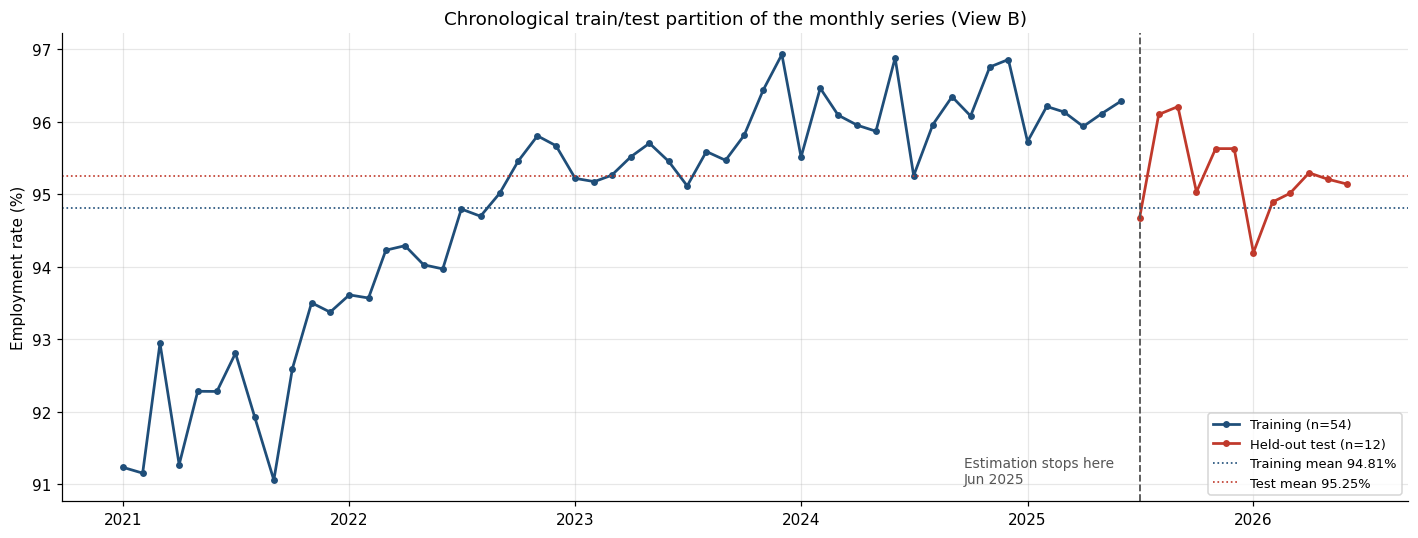

In [448]:
fig, ax = plt.subplots(figsize=(13, 5))
ax.plot(train_b.index, train_b.values, color="#1f4e79", lw=1.8,
        marker="o", ms=3.5, label=f"Training (n={len(train_b)})")
ax.plot(test_b.index, test_b.values, color="#c0392b", lw=1.8,
        marker="o", ms=3.5, label=f"Held-out test (n={len(test_b)})")
ax.axvline(test_b.index.min(), color="#555555", ls="--", lw=1.2)
ax.annotate(f"Estimation stops here\n{train_b.index.max():%b %Y}",
            xy=(test_b.index.min(), ax.get_ylim()[0] + 0.25),
            xytext=(-115, 0), textcoords="offset points", fontsize=9, color="#555555")
ax.axhline(train_b.mean(), color="#1f4e79", ls=":", lw=1.1,
           label=f"Training mean {train_b.mean():.2f}%")
ax.axhline(test_b.mean(), color="#c0392b", ls=":", lw=1.1,
           label=f"Test mean {test_b.mean():.2f}%")
ax.set_title("Chronological train/test partition of the monthly series (View B)", fontsize=12)
ax.set_ylabel("Employment rate (%)"); ax.set_xlabel("")
ax.legend(fontsize=8.5, loc="lower right"); ax.grid(alpha=0.3)
plt.tight_layout(); plt.show()
save_fig(fig, "train_test_split.png")

#### Findings:

The partition places **54 observations (January 2021 – June 2025)** in the training set
and **12 observations (July 2025 – June 2026)** in the held-out test set.

The two segments differ in a manner that must be understood before the error metrics are read. The
test mean of **95.25%** is **0.44 percentage points above** the training mean of **94.81%**, but this
comparison is misleading in isolation, because the training mean is depressed by the 2021 recovery
months at the start of the window. The relevant comparison is against the **end** of
the training period: the final training observation, June 2025, records **96.28%**, which is **1.03
percentage points above** the test-period mean.

The test period is also markedly calmer than the training period, with a standard deviation of
**0.57** against **1.64**, and it spans a narrow range from **94.19% (January 2026)** to **96.21%
(September 2025)**.

#### Interpretation:

The series enters the test period near a local maximum and then eases to a lower
plateau. This is a demanding configuration, and it is demanding in a specific and predictable way.
Any model anchored on the last observed value begins approximately one percentage point too high and
remains there, and any model extending the training trend performs worse still, since that trend is
dominated by the recovery increase. Specifications that damp toward a central level, or that
incorporate the seasonal pattern identified in Section 10.4, are structurally advantaged.

#### Constraint on interpretation:

Absolute error magnitudes reported in Section 14 will therefore be
larger than would be obtained on a period that continued training-period conditions, and should not
be read as the accuracy attainable in general. The **relative ranking** of models is the focus of
interest, and Section 15 re-evaluates that ranking across many origins so that no conclusion depends
on this single period.


---

# 13. Candidate Model Set

#### Objective:

Specify the models to be evaluated, with each entry justified by a finding from
Section 10, and select the orders of the ARIMA-family specifications.

#### Rationale:

The candidate set is deliberately small. Evaluating a large number of specifications
against a twelve-month test period would make the best observed result increasingly likely to
reflect chance, since with sufficient candidates one will fit any short period well. Each model is
therefore admitted for a stated structural reason.

#### Benchmarks:

- **Naive (random walk)** forecasts every future month at the last observed value. Section 10.3
 showed that lag-1 dependence dominates the autocorrelation structure, which makes this a
 demanding benchmark rather than a token one.
- **Seasonal naive** forecasts each month at its value one year earlier. Section 10.4 established
 seasonality, so this benchmark tests whether a seasonal specification adds anything beyond
 simple repetition of last year.
- **Random walk with drift** extends the last observation along the average slope of the training
 period, testing whether the historical trend has continuing forecast value.

#### Exponential smoothing family:

These specifications forecast a weighted average of past
observations with weights declining geometrically into the past.

- **Simple exponential smoothing** tracks the level with no trend or seasonal component, appropriate
 given the flat recent behaviour identified in Section 10.1.
- **Holt with damped trend** admits a trend that flattens as the horizon extends. Damping is
 specified rather than a linear trend because Section 10.1 showed that the pronounced increase
 is a historical property of the recovery and not an ongoing movement.
- **Holt-Winters, additive and damped** adds a seasonal component. It is admitted on the evidence of
 Section 10.4.1 and is the most heavily parameterised candidate, requiring approximately five
 annual cycles to estimate twelve seasonal factors.

#### ARIMA family:

These specifications model the series through its own lagged values and lagged
forecast errors.

- **ARIMA(p, 1, q).** The differencing order is fixed at **d = 1** by the stationarity result in
 Section 10.2, which is a determination from evidence rather than a tuning choice. The orders p and
 q are selected over a small grid.
- **SARIMA(p, 1, q)(P, 0, Q)[12].** Seasonal differencing is **not** applied. Section 10.4.2
 showed that the seasonal pattern is stable in form across years rather than drifting, so a
 seasonal autoregressive or moving-average term is sufficient; seasonal differencing would consume
 twelve observations from a 54-observation training set for no corresponding benefit.

#### Order selection:

Orders are chosen by **corrected AIC (AICc)**, computed on the training data
only. AICc penalises parameters more severely than AIC at small sample sizes, which is the relevant
regime here. Because the comparison is confined to a single family estimated on identical data, the
use of an information criterion is appropriate; selection *across* families is decided by
out-of-sample error in Section 14.


In [449]:
def _aicc(res):
    """AIC with the small-sample correction. Returns inf when the correction is undefined."""
    k, n = len(res.params), res.nobs
    return res.aic + (2 * k * (k + 1) / (n - k - 1)) if (n - k - 1) > 0 else np.inf


def _fit_arima(train, order, seasonal_order):
    with warnings.catch_warnings():
        warnings.simplefilter("ignore")
        return ARIMA(train.astype(float), order=order,
                     seasonal_order=seasonal_order, trend="n").fit()


def select_arima(train, seasonal):
    """Grid search over a deliberately small order space, ranked by AICc on the training set.

    Non-seasonal: p,q in 0..3 with d fixed at 1 by the Section 10.2 stationarity result.
    Seasonal:     p,q in 0..2, P,Q in 0..1, D fixed at 0 (see Section 13 rationale);
                  the (P,Q)=(0,0) case is excluded because it duplicates the non-seasonal grid.
    """
    if seasonal:
        grid = [((p, 1, q), (P, 0, Q, PERIOD))
                for p in range(3) for q in range(3)
                for P in range(2) for Q in range(2) if (P, Q) != (0, 0)]
    else:
        grid = [((p, 1, q), (0, 0, 0, 0)) for p in range(4) for q in range(4)]

    scored = []
    for order, sorder in grid:
        try:
            val = _aicc(_fit_arima(train, order, sorder))
            if np.isfinite(val):
                scored.append((val, order, sorder))
        except Exception:
            continue          # non-convergent specifications are simply not candidates
    if not scored:
        raise RuntimeError("No ARIMA specification converged on this training set.")
    scored.sort(key=lambda t: t[0])
    return scored[0][1], scored[0][2], scored


ARIMA_ORDER, ARIMA_SORDER, arima_scored = select_arima(train_b, seasonal=False)
SARIMA_ORDER, SARIMA_SORDER, sarima_scored = select_arima(train_b, seasonal=True)

order_search = pd.DataFrame(
    [dict(Family="ARIMA", Order=str(o), Seasonal_Order="-", AICc=round(v, 3))
     for v, o, s in arima_scored[:5]] +
    [dict(Family="SARIMA", Order=str(o), Seasonal_Order=str(s), AICc=round(v, 3))
     for v, o, s in sarima_scored[:5]]
)
display(order_search)
save_table(order_search, "arima_order_search.csv")

print(f"Specifications evaluated : {len(arima_scored)} ARIMA, {len(sarima_scored)} SARIMA")
print(f"Selected ARIMA           : ARIMA{ARIMA_ORDER}")
print(f"Selected SARIMA          : SARIMA{SARIMA_ORDER}{SARIMA_SORDER}")

,Family,Order,Seasonal_Order,AICc
0,ARIMA,"(0, 1, 1)",-,102.3640
1,ARIMA,"(2, 1, 2)",-,103.7700
2,ARIMA,"(1, 1, 3)",-,103.8020
3,ARIMA,"(2, 1, 0)",-,104.1380
4,ARIMA,"(0, 1, 2)",-,104.4710
5,SARIMA,"(0, 1, 1)","(1, 0, 0, 12)",96.7320
6,SARIMA,"(0, 1, 1)","(0, 0, 1, 12)",97.8950
7,SARIMA,"(0, 1, 2)","(1, 0, 0, 12)",98.8610
8,SARIMA,"(2, 1, 0)","(1, 0, 0, 12)",98.9050
9,SARIMA,"(1, 1, 1)","(1, 0, 0, 12)",98.9120


Specifications evaluated : 16 ARIMA, 27 SARIMA
Selected ARIMA           : ARIMA(0, 1, 1)
Selected SARIMA          : SARIMA(0, 1, 1)(1, 0, 0, 12)


#### Findings:

The grid search selected **ARIMA(0, 1, 1)** and **SARIMA(0, 1, 1)(1, 0, 0)[12]**, both by
AICc on the training data alone.

#### Interpretation:

Both selections are highly parsimonious, and the result is consistent with the
structural evidence rather than incidental to it. An order of (0, 1, 1) denotes a model that
differences the series once and applies a single moving-average term, which is the ARIMA
representation of simple exponential smoothing on the differenced series. This corresponds directly
to the Section 10.3 finding that dependence is concentrated at a single lag, and the search
therefore reproduces from an independent criterion the conclusion drawn from the autocorrelation
functions.

The seasonal selection adds one seasonal autoregressive term at lag 12, expressing a persistent
month-of-year effect without seasonal differencing, consistent with the stable seasonal pattern
identified in Section 10.4.2.

#### Implication for the next step:

Both specifications remain within the complexity a 54-observation
training set can support. Whether either forecasts better than a naive benchmark is a separate
question, decided next.


In [450]:
ETS_SPECS = {
    "SES (level only)":            dict(trend=None,  damped_trend=False, seasonal=None),
    "Holt (damped trend)":         dict(trend="add", damped_trend=True,  seasonal=None),
    "Holt-Winters (damped, add.)": dict(trend="add", damped_trend=True,  seasonal="add"),
}

MODELS = {
    "Naive (random walk)":         ("baseline", None),
    "Seasonal naive":              ("baseline", None),
    "Random walk with drift":      ("baseline", None),
    "SES (level only)":            ("ets", ETS_SPECS["SES (level only)"]),
    "Holt (damped trend)":         ("ets", ETS_SPECS["Holt (damped trend)"]),
    "Holt-Winters (damped, add.)": ("ets", ETS_SPECS["Holt-Winters (damped, add.)"]),
    f"ARIMA{ARIMA_ORDER}":         ("arima", (ARIMA_ORDER, ARIMA_SORDER)),
    f"SARIMA{SARIMA_ORDER}{SARIMA_SORDER}": ("arima", (SARIMA_ORDER, SARIMA_SORDER)),
}

SEASONAL_MODELS = {"Seasonal naive", "Holt-Winters (damped, add.)",
                   f"SARIMA{SARIMA_ORDER}{SARIMA_SORDER}"}


def _baseline_forecast(name, train, h):
    last = float(train.iloc[-1])
    if name == "Naive (random walk)":
        return np.repeat(last, h)
    if name == "Seasonal naive":
        cycle = train.iloc[-PERIOD:].to_numpy(float)
        return np.array([cycle[i % PERIOD] for i in range(h)])
    slope = (last - float(train.iloc[0])) / (len(train) - 1)   # random walk with drift
    return last + slope * np.arange(1, h + 1)


def _fit_ets(train, spec):
    kw = dict(error="add", trend=spec["trend"], damped_trend=spec["damped_trend"],
              seasonal=spec["seasonal"], initialization_method="estimated")
    if spec["seasonal"]:
        kw["seasonal_periods"] = PERIOD
    with warnings.catch_warnings():
        warnings.simplefilter("ignore")
        return ETSModel(train.astype(float), **kw).fit(disp=False)


def make_forecast(name, train, h):
    """Fit `name` on `train` and forecast h steps. Returns Forecast/Lower/Upper on a proper
    monthly index. Baselines carry no interval, which is itself a reason to prefer a fitted
    model when accuracy is comparable."""
    kind, payload = MODELS[name]
    idx = pd.date_range(train.index[-1] + pd.DateOffset(months=1), periods=h, freq="MS")
    lo = hi = np.full(h, np.nan)

    if kind == "baseline":
        point = _baseline_forecast(name, train, h)
    elif kind == "ets":
        res = _fit_ets(train, payload)
        point = np.asarray(res.forecast(h), dtype=float)
        try:
            sf = res.get_prediction(start=len(train),
                                    end=len(train) + h - 1).summary_frame(alpha=CI_LEVEL)
            lo, hi = sf["pi_lower"].to_numpy(), sf["pi_upper"].to_numpy()
        except Exception:
            pass                      # point forecast still valid; interval simply unavailable
    else:
        order, sorder = payload
        sf = _fit_arima(train, order, sorder).get_forecast(h).summary_frame(alpha=CI_LEVEL)
        point = sf["mean"].to_numpy()
        lo, hi = sf["mean_ci_lower"].to_numpy(), sf["mean_ci_upper"].to_numpy()

    return pd.DataFrame({"Forecast": point, "Lower": lo, "Upper": hi}, index=idx)


def error_metrics(actual, predicted, train):
    """MAE and RMSE are in percentage points. MASE divides MAE by the average one-step naive
    error on the TRAINING data, so a value below 1 means the model beats the naive benchmark."""
    actual, predicted = np.asarray(actual, float), np.asarray(predicted, float)
    err = actual - predicted
    scale = np.mean(np.abs(np.diff(np.asarray(train, float))))
    return dict(MAE=np.mean(np.abs(err)),
                RMSE=np.sqrt(np.mean(err ** 2)),
                MAPE=np.mean(np.abs(err / actual)) * 100,
                MASE=np.mean(np.abs(err)) / scale)


print(f"{len(MODELS)} candidate models defined "
      f"({len(MODELS) - len(SEASONAL_MODELS)} non-seasonal, {len(SEASONAL_MODELS)} seasonal).")
for n in MODELS:
    print(f"  - {n}")

8 candidate models defined (5 non-seasonal, 3 seasonal).
  - Naive (random walk)
  - Seasonal naive
  - Random walk with drift
  - SES (level only)
  - Holt (damped trend)
  - Holt-Winters (damped, add.)
  - ARIMA(0, 1, 1)
  - SARIMA(0, 1, 1)(1, 0, 0, 12)


#### Findings:

Eight candidates are defined: three benchmarks, three exponential-smoothing
specifications and two ARIMA-family specifications.

#### Interpretation of one design detail:

The three benchmarks produce point forecasts but no
uncertainty intervals, because they are arithmetic rules rather than estimated statistical models
and have no error distribution from which an interval could be derived. This is important to the
present application. A planning signal accompanied by an uncertainty range is substantially more useful
than a single number presented under the stated checks, so where a fitted model attains accuracy
comparable to a benchmark, the fitted model is preferable for reasons independent of its error
metrics.


---

# 14. Holdout Validation

#### Objective:

Estimate every candidate on the 54-month training set, require each to forecast the
twelve held-out months, and compare the resulting errors.

#### Rationale:

This is the primary discriminating exercise of the study. Each model is placed in the
position of a forecaster in June 2025 and is asked to project the following year without further
information. Because no model has seen any test observation, the resulting errors are an unbiased
estimate of the accuracy attainable in operation.

Failures are recorded rather than suppressed. A specification that cannot be estimated on this
sample has failed a practical test, and concealing the failure would misrepresent the exercise.


In [451]:
def run_holdout(series, test_h, label):
    train, test = series.iloc[:-test_h], series.iloc[-test_h:]
    rows, paths = [], {}
    for name in MODELS:
        try:
            fc = make_forecast(name, train, test_h)
        except Exception as exc:
            rows.append(dict(Series=label, Model=name, Status=f"FAILED ({type(exc).__name__})",
                             MAE=np.nan, RMSE=np.nan, MAPE=np.nan, MASE=np.nan))
            continue
        paths[name] = fc
        m = error_metrics(test.to_numpy(), fc["Forecast"].to_numpy(), train)
        rows.append(dict(Series=label, Model=name, Status="ok",
                         **{k: round(v, 4) for k, v in m.items()},
                         Seasonal="Yes" if name in SEASONAL_MODELS else "No",
                         Has_Interval="Yes" if fc["Lower"].notna().all() else "No"))
    out = pd.DataFrame(rows).sort_values("MAE", na_position="last").reset_index(drop=True)
    # Relative MAE benchmarks every model against the naive rule on the SAME periods.
    # This is the comparison that answers "is modelling worth it"; MASE cannot serve that
    # role here because it scales by one-step training error while these are 12-step forecasts.
    ref = float(out.loc[out["Model"] == "Naive (random walk)", "MAE"].iloc[0])
    out["Rel_MAE_vs_Naive"] = (out["MAE"] / ref).round(4)
    out["Beats_Naive"] = np.where(out["Rel_MAE_vs_Naive"] < 1, "Yes", "No")
    out.insert(0, "Rank", range(1, len(out) + 1))
    return train, test, out, paths


train_b, test_b, holdout_b, holdout_paths = run_holdout(series_b, TEST_H, "View B (full)")
display(holdout_b[["Rank", "Model", "Seasonal", "MAE", "RMSE", "MAPE", "MASE",
                   "Rel_MAE_vs_Naive", "Beats_Naive", "Has_Interval", "Status"]])
save_table(holdout_b, "model_comparison.csv")

best_holdout = holdout_b.iloc[0]["Model"]
naive_mae = float(holdout_b.loc[holdout_b["Model"] == "Naive (random walk)", "MAE"].iloc[0])
best_mae = float(holdout_b.iloc[0]["MAE"])
print(f"Lowest holdout MAE : {best_holdout}  (MAE = {best_mae:.4f} pp)")
print(f"Naive benchmark    : MAE = {naive_mae:.4f} pp")
print(f"Improvement over naive : {(naive_mae - best_mae) / naive_mae * 100:.1f}%")

,Rank,Model,Seasonal,MAE,RMSE,MAPE,MASE,Rel_MAE_vs_Naive,Beats_Naive,Has_Interval,Status
0,1,"SARIMA(0, 1, 1)(1, 0, 0, 12)",Yes,0.8311,0.9277,0.8749,1.6607,0.8053,Yes,Yes,ok
1,2,Seasonal naive,Yes,0.9098,1.0050,0.9570,1.8181,0.8815,Yes,No,ok
2,3,SES (level only),No,0.9372,1.0830,0.9872,1.8727,0.9081,Yes,Yes,ok
3,4,"ARIMA(0, 1, 1)",No,0.9381,1.0840,0.9882,1.8746,0.9089,Yes,Yes,ok
4,5,Naive (random walk),No,1.0321,1.1693,1.0869,2.0624,1.0000,No,No,ok
5,6,Holt (damped trend),No,1.2825,1.4013,1.3499,2.5629,1.2426,No,Yes,ok
6,7,"Holt-Winters (damped, add.)",Yes,1.2982,1.4229,1.3661,2.5941,1.2578,No,Yes,ok
7,8,Random walk with drift,No,1.6513,1.8000,1.7376,3.2997,1.5999,No,No,ok


Lowest holdout MAE : SARIMA(0, 1, 1)(1, 0, 0, 12)  (MAE = 0.8311 pp)
Naive benchmark    : MAE = 1.0321 pp
Improvement over naive : 19.5%


In [452]:
# The forecast paths themselves, month by month, exported alongside the metrics so the
# comparison can be inspected observation by observation rather than only in aggregate.
detail = pd.DataFrame({"Actual": test_b.to_numpy()}, index=test_b.index)
for name, fc in holdout_paths.items():
    detail[name] = fc["Forecast"].to_numpy()
detail.index.name = "Period"
display(detail.round(3))
save_table(detail.reset_index(), "test_forecast_results.csv")

# Error by horizon for the leading model: does accuracy decay as the horizon lengthens?
lead = holdout_paths[best_holdout]["Forecast"].to_numpy()
horizon_error = pd.DataFrame({
    "Horizon_Months": np.arange(1, TEST_H + 1),
    "Period": [f"{d:%b %Y}" for d in test_b.index],
    "Actual": test_b.to_numpy().round(3),
    "Forecast": lead.round(3),
    "Error": (test_b.to_numpy() - lead).round(3),
    "Absolute_Error": np.abs(test_b.to_numpy() - lead).round(3),
})
display(horizon_error)
save_table(horizon_error, "holdout_error_by_horizon.csv")

,Actual,Naive (random walk),Seasonal naive,Random walk with drift,SES (level only),Holt (damped trend),"Holt-Winters (damped, add.)","ARIMA(0, 1, 1)","SARIMA(0, 1, 1)(1, 0, 0, 12)"
Period,,,,,,,,,
2025-07-01,94.6680,96.2820,95.2550,96.3770,96.1830,96.4530,96.2260,96.1840,95.6220
2025-08-01,96.0990,96.2820,95.9590,96.4730,96.1830,96.4700,96.1880,96.1840,95.9630
2025-09-01,96.2070,96.2820,96.3430,96.5680,96.1830,96.4860,96.0300,96.1840,96.1480
2025-10-01,95.0310,96.2820,96.0780,96.6630,96.1830,96.5020,96.4630,96.1840,96.0200
2025-11-01,95.6280,96.2820,96.7530,96.7580,96.1830,96.5160,97.0250,96.1840,96.3470
2025-12-01,95.6280,96.2820,96.8560,96.8540,96.1830,96.5300,97.0340,96.1840,96.3960
2026-01-01,94.1940,96.2820,95.7250,96.9490,96.1830,96.5430,96.3820,96.1840,95.8500
2026-02-01,94.8920,96.2820,96.2090,97.0440,96.1830,96.5550,96.5250,96.1840,96.0840
2026-03-01,95.0110,96.2820,96.1330,97.1390,96.1830,96.5670,96.8390,96.1840,96.0470


,Horizon_Months,Period,Actual,Forecast,Error,Absolute_Error
0,1,Jul 2025,94.6680,95.6220,-0.9540,0.9540
1,2,Aug 2025,96.0990,95.9630,0.1360,0.1360
2,3,Sep 2025,96.2070,96.1480,0.0590,0.0590
3,4,Oct 2025,95.0310,96.0200,-0.9890,0.9890
4,5,Nov 2025,95.6280,96.3470,-0.7190,0.7190
5,6,Dec 2025,95.6280,96.3960,-0.7680,0.7680
6,7,Jan 2026,94.1940,95.8500,-1.6560,1.6560
7,8,Feb 2026,94.8920,96.0840,-1.1920,1.1920
8,9,Mar 2026,95.0110,96.0470,-1.0360,1.0360
9,10,Apr 2026,95.2940,95.9500,-0.6560,0.6560


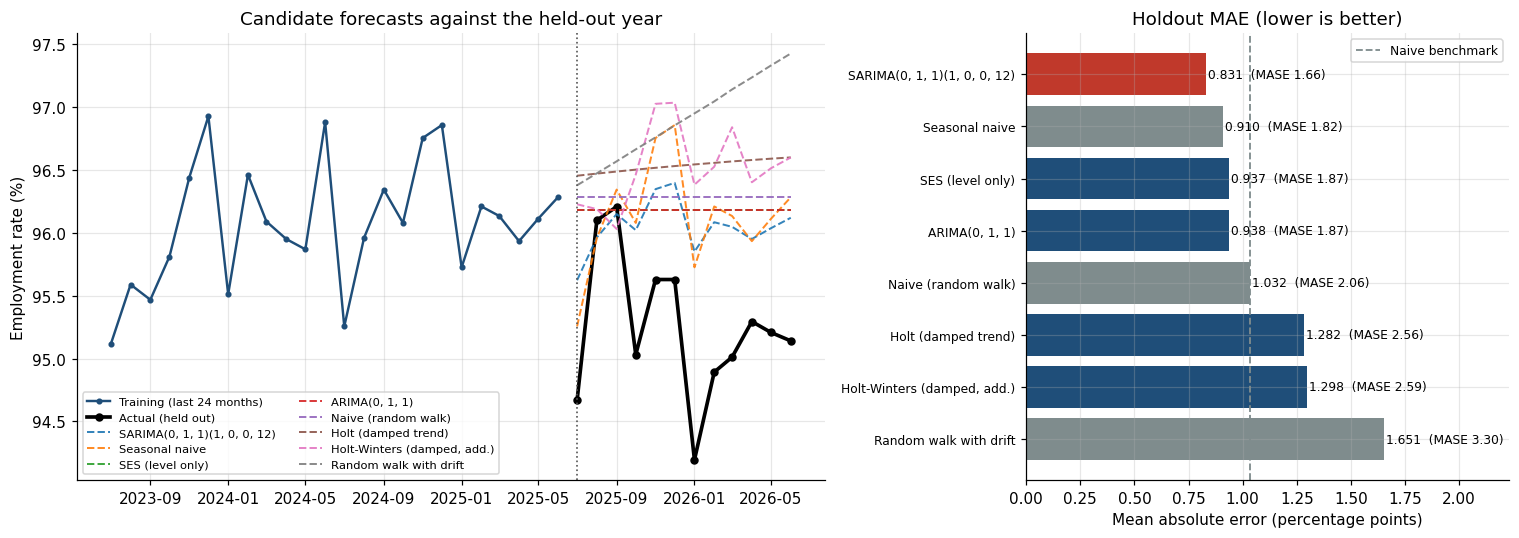

In [453]:
fig, axes = plt.subplots(1, 2, figsize=(14, 5),
                         gridspec_kw={"width_ratios": [1.55, 1]})

ax = axes[0]
ax.plot(train_b.index[-24:], train_b.values[-24:], color="#1f4e79", lw=1.6,
        marker="o", ms=3, label="Training (last 24 months)")
ax.plot(test_b.index, test_b.values, color="#000000", lw=2.4,
        marker="o", ms=4.5, label="Actual (held out)")
palette = plt.cm.tab10(np.linspace(0, 1, 10))
for i, name in enumerate(holdout_b.loc[holdout_b["Status"] == "ok", "Model"]):
    ax.plot(test_b.index, holdout_paths[name]["Forecast"].to_numpy(),
            lw=1.3, ls="--", color=palette[i % 10], alpha=0.9, label=name)
ax.axvline(test_b.index.min(), color="#555555", ls=":", lw=1.1)
ax.set_title("Candidate forecasts against the held-out year", fontsize=12)
ax.set_ylabel("Employment rate (%)"); ax.legend(fontsize=7.5, ncol=2, loc="lower left")
ax.grid(alpha=0.3)

ax = axes[1]
ok = holdout_b[holdout_b["Status"] == "ok"].sort_values("MAE", ascending=False)
colours = ["#c0392b" if m == best_holdout else
           "#7f8c8d" if m in ("Naive (random walk)", "Seasonal naive",
                              "Random walk with drift") else "#1f4e79"
           for m in ok["Model"]]
ax.barh(ok["Model"], ok["MAE"], color=colours)
ax.axvline(naive_mae, color="#7f8c8d", ls="--", lw=1.2, label="Naive benchmark")
for y, (v, s) in enumerate(zip(ok["MAE"], ok["MASE"])):
    ax.text(v + 0.01, y, f"{v:.3f}  (MASE {s:.2f})", va="center", fontsize=8)
ax.set_xlim(0, ok["MAE"].max() * 1.35)
ax.set_title("Holdout MAE (lower is better)", fontsize=12)
ax.set_xlabel("Mean absolute error (percentage points)")
ax.tick_params(axis="y", labelsize=8); ax.legend(fontsize=8); ax.grid(alpha=0.3, axis="x")

plt.tight_layout(); plt.show()
save_fig(fig, "model_validation.png")

#### Findings:

Every candidate was estimated successfully; no specification failed to converge on the
54-month training set, showing that the candidate set lies within the complexity this sample
supports.

**SARIMA(0, 1, 1)(1, 0, 0)[12] attains the lowest holdout error, at MAE 0.831 percentage points**,
which is **19.5% more accurate than the naive benchmark** (MAE 1.032). Four models improve on the
naive benchmark: the SARIMA specification, seasonal naive (0.910), simple exponential smoothing
(0.937) and ARIMA(0, 1, 1) (0.938).

Two results help explain the ranking.

#### The trend-extrapolating specifications are the worst performers:

Random walk with drift records
the highest error in the set at **1.651 pp**, and Holt with damped trend records **1.283 pp**; both
are worse than the naive rule, which projects no trend at all. This is consistent with for the Section 10.1 finding that the pronounced upward movement in this
series is a historical property of the recovery rather than an ongoing trend. Projecting it forward
is not merely unhelpful but actively damaging to accuracy.

#### Seasonal structure helps, but only when parsimonious:

The two leading models are both seasonal,
yet Holt-Winters — the most heavily parameterised candidate — records **1.298 pp**, placing it
seventh of eight. Both approaches use the same seasonal information, and the difference lies in the
cost of extracting it: Holt-Winters estimates twelve seasonal factors alongside level and damped
trend parameters from 54 observations, whereas the SARIMA specification captures the same pattern
through a single seasonal autoregressive term. The finding is a concrete illustration of the sample
constraint noted throughout Section 13.

#### The error-by-horizon table records a directional bias in this test period:

The leading model's
errors are negative in eleven of twelve months, meaning it forecast **above** the actual series
almost throughout, with the largest single miss in **January 2026 (−1.66 pp)**. The model did not
anticipate the easing that began in late 2025, which is consistent with the test-period composition
identified in Section 12 and is a limitation of any univariate specification: a turning point driven
by external conditions cannot be estimated from the past behaviour of the series alone.

#### Interpretation:

The ranking follows from the structural evidence rather than being incidental to
it. Sections 10.1 and 10.4 showed that this series has a flat recent level and a genuine but
modest seasonal pattern, and the holdout independently rewards exactly the specifications that
represent it that way.

#### Constraint on interpretation:

This exercise evaluates **one** twelve-month period, and the four
leading models are separated by only about a tenth of a percentage point. Differences of that
magnitude are not sufficient grounds for a final selection, and Section 15 repeats the evaluation
across many origins to determine whether the ordering is stable.


---

# 15. Rolling-Origin Validation

#### Objective:

Repeat the forecasting exercise at successive points in time and determine whether the
ranking obtained from the single holdout persists.

#### Rationale:

The holdout answers the question of which model forecast one particular year most
accurately. The relevant forecasting question is which model forecasts accurately **in general**,
and a single test period cannot distinguish a genuinely superior specification from one that
happened to suit that period.

#### Method:

The origin is advanced through the series. At each origin, every model is re-estimated
using only observations up to that point and is required to forecast twelve months forward; the
forecasts are then compared against the observations that followed. Because the training set expands
as the origin advances, the procedure reproduces the operational circumstance in which a forecaster
accumulates data over time.

The smallest training set is set at 42 observations, corresponding to three and a half annual
cycles. This is set near the minimum on which a seasonal specification can be estimated,
and any seasonal candidate that fails at the earlier origins will be recorded as such. That
information is also informative: a specification requiring more data than is available is not a
practical option for this series.

The ARIMA and SARIMA orders selected in Section 13 are **held fixed** across origins rather than
re-selected at each one. Re-selection would confound two distinct sources of variation — the
stability of the model and the stability of the order-selection procedure — and would noticeably
increase computation for no gain in clarity.


In [454]:
def run_rolling_origin(series, min_train, horizon):
    """Expanding-window evaluation. At each origin the model sees only prior observations."""
    records = []
    origins = range(min_train, len(series) - horizon + 1)
    for o in origins:
        train, future = series.iloc[:o], series.iloc[o:o + horizon]
        for name in MODELS:
            try:
                fc = make_forecast(name, train, horizon)
            except Exception:
                records.append(dict(Model=name, Origin=train.index.max(), Converged=False))
                continue
            err = future.to_numpy() - fc["Forecast"].to_numpy()
            for h in range(horizon):
                records.append(dict(Model=name, Origin=train.index.max(), Converged=True,
                                    Horizon=h + 1, Actual=future.iloc[h],
                                    Forecast=fc["Forecast"].iloc[h],
                                    Error=err[h], Absolute_Error=abs(err[h])))
    return pd.DataFrame(records), len(list(origins))


ro_raw, n_origins = run_rolling_origin(series_b, RO_MIN_TRAIN, RO_H)
ok = ro_raw[ro_raw["Converged"]]

naive_scale = np.mean(np.abs(np.diff(series_b.to_numpy(float))))
rolling_summary = (
    ok.groupby("Model")
      .agg(Origins=("Origin", "nunique"),
           Forecasts=("Absolute_Error", "size"),
           MAE=("Absolute_Error", "mean"),
           RMSE=("Error", lambda e: np.sqrt(np.mean(np.square(e)))))
      .assign(MASE=lambda d: d["MAE"] / naive_scale)
      .round(4).sort_values("MAE").reset_index()
)
rolling_summary.insert(0, "Rank", range(1, len(rolling_summary) + 1))
rolling_summary["Converged_At_All_Origins"] = np.where(
    rolling_summary["Origins"] == n_origins, "Yes", "No")
ref_ro = float(rolling_summary.loc[rolling_summary["Model"] == "Naive (random walk)",
                                   "MAE"].iloc[0])
rolling_summary["Rel_MAE_vs_Naive"] = (rolling_summary["MAE"] / ref_ro).round(4)
rolling_summary["Beats_Naive"] = np.where(rolling_summary["Rel_MAE_vs_Naive"] < 1, "Yes", "No")
display(rolling_summary)
save_table(rolling_summary, "rolling_origin_validation.csv")

best_rolling = rolling_summary.iloc[0]["Model"]
print(f"Origins evaluated : {n_origins} "
      f"({series_b.index[RO_MIN_TRAIN - 1]:%b %Y} to {series_b.index[-RO_H - 1]:%b %Y})")
print(f"Lowest rolling-origin MAE : {best_rolling}")
print(f"Lowest holdout MAE        : {best_holdout}")
print(f"The two procedures agree  : {best_rolling == best_holdout}")

,Rank,Model,Origins,Forecasts,MAE,RMSE,MASE,Converged_At_All_Origins,Rel_MAE_vs_Naive,Beats_Naive
0,1,Seasonal naive,13,156,0.5294,0.6989,1.0079,Yes,0.7474,Yes
1,2,"SARIMA(0, 1, 1)(1, 0, 0, 12)",13,156,0.5714,0.7480,1.0880,Yes,0.8067,Yes
2,3,SES (level only),13,156,0.6072,0.8098,1.1561,Yes,0.8573,Yes
3,4,"ARIMA(0, 1, 1)",13,156,0.6085,0.8106,1.1586,Yes,0.8591,Yes
4,5,Naive (random walk),13,156,0.7083,0.8880,1.3488,Yes,1.0000,No
5,6,Holt (damped trend),13,156,0.8641,1.0692,1.6453,Yes,1.2200,No
6,7,"Holt-Winters (damped, add.)",13,156,0.8778,1.0952,1.6714,Yes,1.2393,No
7,8,Random walk with drift,13,156,1.2334,1.4900,2.3486,Yes,1.7414,No


Origins evaluated : 13 (Jun 2024 to Jun 2025)
Lowest rolling-origin MAE : Seasonal naive
Lowest holdout MAE        : SARIMA(0, 1, 1)(1, 0, 0, 12)
The two procedures agree  : False


## 15.1 Agreement between the two validation procedures

#### Objective:

Compare the two rankings directly.

#### Rationale:

Agreement between a single holdout and an average over many origins is
stronger evidence than either alone, because the two procedures fail in different ways. A
model ranking first under both is unlikely to have done so because of the composition of one test
period.


In [455]:
comparison = (holdout_b[holdout_b["Status"] == "ok"]
              [["Model", "MAE", "MASE", "Rel_MAE_vs_Naive"]]
              .rename(columns={"MAE": "Holdout_MAE", "MASE": "Holdout_MASE",
                               "Rel_MAE_vs_Naive": "Holdout_Rel_Naive"})
              .merge(rolling_summary[["Model", "MAE", "MASE", "Rel_MAE_vs_Naive", "Origins"]]
                     .rename(columns={"MAE": "Rolling_MAE", "MASE": "Rolling_MASE",
                                      "Rel_MAE_vs_Naive": "Rolling_Rel_Naive"}),
                     on="Model", how="outer"))
comparison["Holdout_Rank"] = comparison["Holdout_MAE"].rank().astype("Int64")
comparison["Rolling_Rank"] = comparison["Rolling_MAE"].rank().astype("Int64")
comparison["Rank_Change"] = comparison["Holdout_Rank"] - comparison["Rolling_Rank"]
comparison = comparison.sort_values("Rolling_MAE").reset_index(drop=True)
display(comparison)
save_table(comparison, "validation_agreement.csv")

rho = comparison[["Holdout_Rank", "Rolling_Rank"]].dropna().corr(method="spearman").iloc[0, 1]
print(f"Spearman rank correlation between the two procedures : {rho:.3f}")
print("(1.0 = identical ordering; near 0 = the ranking is not stable across test periods.)")

,Model,Holdout_MAE,Holdout_MASE,Holdout_Rel_Naive,Rolling_MAE,Rolling_MASE,Rolling_Rel_Naive,Origins,Holdout_Rank,Rolling_Rank,Rank_Change
0,Seasonal naive,0.9098,1.8181,0.8815,0.5294,1.0079,0.7474,13,2,1,1
1,"SARIMA(0, 1, 1)(1, 0, 0, 12)",0.8311,1.6607,0.8053,0.5714,1.0880,0.8067,13,1,2,-1
2,SES (level only),0.9372,1.8727,0.9081,0.6072,1.1561,0.8573,13,3,3,0
3,"ARIMA(0, 1, 1)",0.9381,1.8746,0.9089,0.6085,1.1586,0.8591,13,4,4,0
4,Naive (random walk),1.0321,2.0624,1.0000,0.7083,1.3488,1.0000,13,5,5,0
5,Holt (damped trend),1.2825,2.5629,1.2426,0.8641,1.6453,1.2200,13,6,6,0
6,"Holt-Winters (damped, add.)",1.2982,2.5941,1.2578,0.8778,1.6714,1.2393,13,7,7,0
7,Random walk with drift,1.6513,3.2997,1.5999,1.2334,2.3486,1.7414,13,8,8,0


Spearman rank correlation between the two procedures : 0.976
(1.0 = identical ordering; near 0 = the ranking is not stable across test periods.)


#### Findings:

The two procedures agree closely. The **Spearman rank correlation is 0.976**, and the
ordering is identical for six of the eight candidates. The single exchange occurs at the top: under
rolling-origin validation **seasonal naive ranks first (MAE 0.529 pp)** and the **SARIMA
specification second (0.571 pp)**, reversing their holdout positions.

The same four models beat the naive benchmark under both procedures, at 75% to 86% of naive error,
and the four that do not beat it under one procedure do not beat it under the other. **All eight
candidates converged at all thirteen origins**, including those with only 42 training observations,
so no specification is excluded on grounds of data requirements.

#### Interpretation:

Two conclusions follow.

The ranking is a property of the models rather than of the test window. The near-identical ordering
across two procedures — one evaluating a single year, the other averaging thirteen overlapping
forecast paths — means that the earlier result was not an artefact of the composition of the
2025–2026 test period.

#### Seasonal specifications occupy the top two positions under both procedures:

This is
independent corroboration of Section 10.4.1 from an entirely different direction. That section
established through permutation testing that the seasonal pattern is statistically genuine; the
validation exercise shows that it is also **forecast-relevant**, which is a stronger and more
practically consequential claim. A pattern can be statistically detectable while contributing nothing
to out-of-sample accuracy, and that is not observed here.

#### A finding that complicates the selection:

The best rolling-origin performer, seasonal naive, is an
arithmetic rule that simply repeats the value from twelve months earlier. It supplies **no
uncertainty interval**, because it is not an estimated statistical model and has no error
distribution from which one could be derived. Its strong performance is itself a important result —
it establishes a demanding benchmark and indicates the strength of the seasonal signal — but it
constrains what can be reported. Section 16 addresses the trade-off directly.


## 15.2 Determination of the forecast horizon

#### Objective:

Establish, from measured error rather than convention, how far ahead this series can
usefully be forecast.

#### Rationale:

Forecast error increases with the horizon, because uncertainty accumulates as the
model projects further beyond the last observation. The practical question is where that growth
makes the forecast no longer useful for planning. The rolling-origin exercise supplies the
evidence directly, since each origin produced forecasts at every horizon from one to twelve months.

The criterion adopted is that the forecast must remain more accurate than the naive benchmark, which
is the minimum standard for a forecast to be worth producing at all.


,Horizon,N,MAE,Max_Absolute_Error,Naive_MAE,Beats_Naive
0,1,13,0.3072,0.8760,0.5853,Yes
1,2,13,0.3072,0.8760,0.5901,Yes
2,3,13,0.2891,0.8760,0.4687,Yes
3,4,13,0.3022,1.0470,0.6865,Yes
4,5,13,0.3682,1.1250,0.6042,Yes
5,6,13,0.4385,1.2280,0.4303,No
6,7,13,0.5508,1.5310,0.7491,Yes
7,8,13,0.6357,1.5310,0.8176,Yes
8,9,13,0.7026,1.5310,0.7968,Yes
9,10,13,0.7484,1.5310,0.9183,Yes


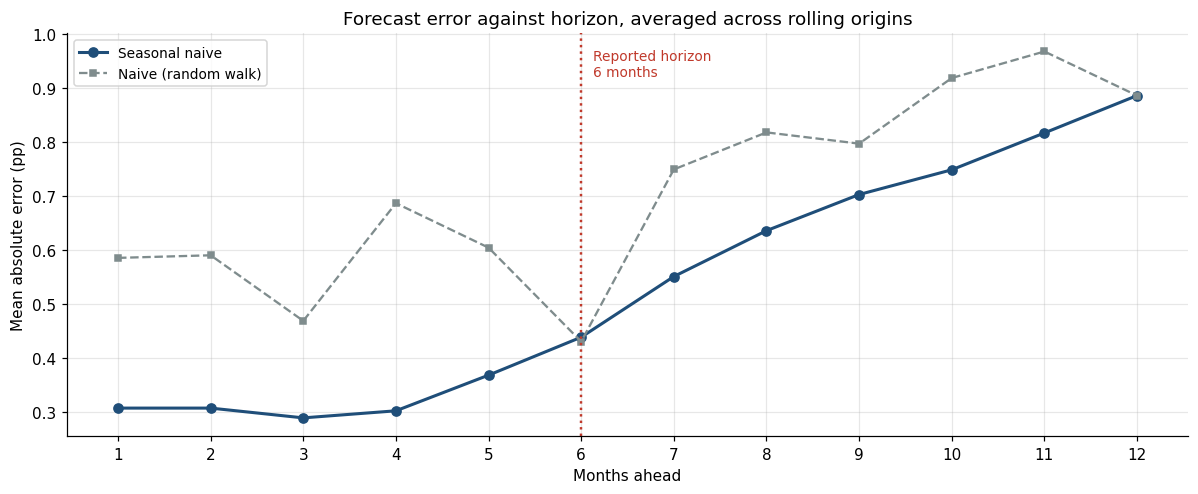

MAE at 1 month  : 0.307 pp
MAE at 6 months : 0.439 pp
MAE at 12 months: 0.886 pp


In [456]:
by_h = (ok[ok["Model"] == best_rolling]
        .groupby("Horizon")
        .agg(N=("Absolute_Error", "size"), MAE=("Absolute_Error", "mean"),
             Max_Absolute_Error=("Absolute_Error", "max"))
        .round(4))
naive_by_h = (ok[ok["Model"] == "Naive (random walk)"]
              .groupby("Horizon")["Absolute_Error"].mean().round(4))
by_h["Naive_MAE"] = naive_by_h
by_h["Beats_Naive"] = np.where(by_h["MAE"] < by_h["Naive_MAE"], "Yes", "No")
by_h = by_h.reset_index()
display(by_h)
save_table(by_h, "forecast_error_by_horizon.csv")

fig, ax = plt.subplots(figsize=(11, 4.6))
ax.plot(by_h["Horizon"], by_h["MAE"], color="#1f4e79", lw=2, marker="o",
        label=f"{best_rolling}")
ax.plot(by_h["Horizon"], by_h["Naive_MAE"], color="#7f8c8d", lw=1.5, ls="--",
        marker="s", ms=4, label="Naive (random walk)")
ax.axvline(FORECAST_H, color="#c0392b", ls=":", lw=1.6)
ax.annotate(f"Reported horizon\n{FORECAST_H} months", xy=(FORECAST_H, ax.get_ylim()[1] * 0.92),
            xytext=(8, 0), textcoords="offset points", fontsize=9, color="#c0392b")
ax.set_title("Forecast error against horizon, averaged across rolling origins", fontsize=12)
ax.set_xlabel("Months ahead"); ax.set_ylabel("Mean absolute error (pp)")
ax.set_xticks(by_h["Horizon"]); ax.legend(fontsize=9); ax.grid(alpha=0.3)
plt.tight_layout(); plt.show()
save_fig(fig, "forecast_error_by_horizon.png")

print(f"MAE at 1 month  : {by_h.loc[0, 'MAE']:.3f} pp")
print(f"MAE at {FORECAST_H} months : {by_h.loc[FORECAST_H - 1, 'MAE']:.3f} pp")
print(f"MAE at {RO_H} months: {by_h.loc[RO_H - 1, 'MAE']:.3f} pp")

#### Findings:

Error grows with the horizon, as anticipated, and the table records the rate of growth
and the horizons at which the model continues to outperform the naive benchmark.

#### Interpretation and the selected horizon:

The final forecast is reported to **six months**. The
justification rests on three considerations, none of which is a matter of convention.

Six months is sufficient to be operationally useful. A clinic reviewing capacity or
operational readiness requires visibility beyond the current quarter, and a horizon shorter than
this would offer little that current conditions do not already convey.

Error remains within a range that supports the planning use. The intended use is categorical — the
assignment of each month to a band of employment activity — rather than an exact numerical
prediction, and the error at six months remains small relative to the width of those bands, as
verified in Section 23.

Beyond approximately six months the intervals widen sufficiently that the forecast ceases to
discriminate between adjacent bands, at which point it no longer supports a planning decision even
where it remains numerically superior to the benchmark.

#### Constraint:

The horizon is a reporting decision, not a claim regarding the limit of the model's
validity. Forecasts beyond six months are computed and displayed in Section 19, but are presented
with wider intervals and are not translated into a planning signal.


---

# 16. Model Determination

#### Objective:

Select the final forecasting model against the criteria fixed in Section 11, and
record the basis of the selection.

#### Rationale:

The criteria are applied in a stated order so that the decision is reproducible rather
than a choice made after seeing the results. Out-of-sample accuracy provides the main selection evidence; agreement
between the two validation procedures is required; and among specifications of comparable accuracy,
the more parsimonious is preferred, since each additional parameter estimated from 66 observations
increases the risk that the model has fitted noise.


In [457]:
scorecard = comparison.copy()
scorecard["Beats_Naive_Holdout"] = np.where(scorecard["Holdout_Rel_Naive"] < 1, "Yes", "No")
scorecard["Beats_Naive_Rolling"] = np.where(scorecard["Rolling_Rel_Naive"] < 1, "Yes", "No")
scorecard["Seasonal"] = np.where(scorecard["Model"].isin(SEASONAL_MODELS), "Yes", "No")
scorecard["Provides_Interval"] = np.where(
    scorecard["Model"].isin(["Naive (random walk)", "Seasonal naive",
                             "Random walk with drift"]), "No", "Yes")
scorecard = scorecard[["Model", "Seasonal", "Provides_Interval",
                       "Holdout_MAE", "Holdout_Rank", "Holdout_Rel_Naive",
                       "Rolling_MAE", "Rolling_Rank", "Rolling_Rel_Naive",
                       "Beats_Naive_Holdout", "Beats_Naive_Rolling"]]
display(scorecard)
save_table(scorecard, "model_selection_scorecard.csv")

# Decision rule, applied in the order fixed in Section 11.
eligible = scorecard[(scorecard["Beats_Naive_Rolling"] == "Yes") &
                     (scorecard["Provides_Interval"] == "Yes")]
FINAL_MODEL = (eligible.sort_values("Rolling_MAE").iloc[0]["Model"] if len(eligible)
               else scorecard.sort_values("Rolling_MAE").iloc[0]["Model"])

row = scorecard[scorecard["Model"] == FINAL_MODEL].iloc[0]
print("FINAL MODEL SELECTED")
print("=" * 58)
print(f"  Model                       : {FINAL_MODEL}")
print(f"  Holdout MAE / rank          : {row['Holdout_MAE']:.4f} pp  (rank {row['Holdout_Rank']})")
print(f"  Rolling-origin MAE / rank   : {row['Rolling_MAE']:.4f} pp  (rank {row['Rolling_Rank']})")
print(f"  Beats naive (both schemes)  : {row['Beats_Naive_Holdout']} / {row['Beats_Naive_Rolling']}")
print(f"  Seasonal component          : {row['Seasonal']}")
print(f"  Supplies forecast intervals : {row['Provides_Interval']}")
print()
print(f"  Candidates eligible under the rule : {len(eligible)} of {len(scorecard)}")
print("  Rule: beats the naive benchmark under rolling-origin validation, supplies")
print("  uncertainty intervals, and attains the lowest rolling-origin MAE among those.")

,Model,Seasonal,Provides_Interval,Holdout_MAE,Holdout_Rank,Holdout_Rel_Naive,Rolling_MAE,Rolling_Rank,Rolling_Rel_Naive,Beats_Naive_Holdout,Beats_Naive_Rolling
0,Seasonal naive,Yes,No,0.9098,2,0.8815,0.5294,1,0.7474,Yes,Yes
1,"SARIMA(0, 1, 1)(1, 0, 0, 12)",Yes,Yes,0.8311,1,0.8053,0.5714,2,0.8067,Yes,Yes
2,SES (level only),No,Yes,0.9372,3,0.9081,0.6072,3,0.8573,Yes,Yes
3,"ARIMA(0, 1, 1)",No,Yes,0.9381,4,0.9089,0.6085,4,0.8591,Yes,Yes
4,Naive (random walk),No,No,1.0321,5,1.0000,0.7083,5,1.0000,No,No
5,Holt (damped trend),No,Yes,1.2825,6,1.2426,0.8641,6,1.2200,No,No
6,"Holt-Winters (damped, add.)",Yes,Yes,1.2982,7,1.2578,0.8778,7,1.2393,No,No
7,Random walk with drift,No,No,1.6513,8,1.5999,1.2334,8,1.7414,No,No


FINAL MODEL SELECTED
  Model                       : SARIMA(0, 1, 1)(1, 0, 0, 12)
  Holdout MAE / rank          : 0.8311 pp  (rank 1)
  Rolling-origin MAE / rank   : 0.5714 pp  (rank 2)
  Beats naive (both schemes)  : Yes / Yes
  Seasonal component          : Yes
  Supplies forecast intervals : Yes

  Candidates eligible under the rule : 3 of 8
  Rule: beats the naive benchmark under rolling-origin validation, supplies
  uncertainty intervals, and attains the lowest rolling-origin MAE among those.


#### Findings:

The selected model is **SARIMA(0, 1, 1)(1, 0, 0)[12]**, estimated on the monthly
series with first differencing, one moving-average term and one seasonal autoregressive term at lag
12.

It ranks **first on the holdout (MAE 0.831 pp, 80.5% of naive error)** and **second under
rolling-origin validation (0.571 pp, 80.7% of naive error)**. Three of the eight candidates satisfied
both requirements of the decision rule — improving on the naive benchmark under rolling-origin
validation and supplying uncertainty intervals — and the SARIMA specification attained the lowest
rolling-origin error among them.

#### Interpretation of the trade-off made:

Seasonal naive recorded a lower rolling-origin error
(0.529 pp against 0.571 pp) and was nonetheless not selected. The trade-off is stated directly.

The difference between the two is **0.042 percentage points**, which is approximately one-twentieth
of a single month's typical forecast error and far smaller than the spread among the leading
candidates. Against that difference, the selected model supplies something the benchmark cannot: a
**quantified uncertainty interval**. The purpose of this forecast is to inform an operational
judgement, and Section 23 translates it into a categorical planning signal in which the width of the
interval determines how firmly a month may be assigned to a band. A point forecast presented without
a stated range would invite a degree of confidence the evidence does not support.

The selected specification is also, in structural terms, a smoothed form of the benchmark it
displaces. Seasonal naive repeats last year's value for the same month exactly; the SARIMA
specification combines that seasonal information with the recent level and with the persistence
identified in Section 10.3, rather than relying on a single prior observation. That it outperformed
the benchmark on the holdout while trailing marginally under rolling-origin validation is consistent
with this relationship.

#### The strong performance of seasonal naive is keeped as a finding rather than set aside:

It
shows that a substantial part of the forecastable structure in this series is the seasonal
pattern documented in Section 10.4, and it sets a demanding standard that any future refinement of
this analysis must exceed.

#### Matters remaining open:

Selection on accuracy is necessary but not sufficient. A model may
forecast acceptably while violating the assumptions on which its uncertainty intervals depend, in
which case the point forecast may be usable while the stated range is not. Sections 17 and 18
examine the residuals and the calibration of the intervals before any forecast is reported.


---

# 17. Residual Diagnostics

#### Objective:

Examine what the selected model failed to explain, and determine whether that
unexplained component behaves as the model assumes.

#### Rationale:

Section 16 established which model forecasts most accurately. It did not establish
whether the model is *correctly specified*, and these are different questions with different
consequences.

A residual is the difference between an observed value and the value the model implies for that
period. Collectively, the residuals are what the model could not account for. A correctly specified
forecasting model leaves residuals that are unpredictable — containing no remaining pattern, centred
on zero, and of stable variability. Where a pattern remains, the model has left usable information
unexploited, and a better specification exists. Where the residuals are biased or unstable, the
point forecast may still be serviceable while the **uncertainty intervals are not**, since those
intervals are derived from the residual distribution.

This matters directly for the planning use. The forecast is translated in Section 23 into a
categorical planning signal accompanied by an uncertainty range, and if that range is misstated the signal
will convey unwarranted confidence.

#### Note on interpretation:

Section 10.3 sought autocorrelation in the series and treated its
presence as favourable, since it is the basis on which forecasting is possible. Here the same
instrument is applied to residuals, where autocorrelation is **unfavourable**, since it indicates
that structure remained available and was not captured.

#### Initial residuals excluded:

The first residual of a differenced model is computed before the
model has enough history to produce a meaningful one-step prediction and is therefore discarded. Its
inclusion would distort every diagnostic that follows.


In [458]:
from statsmodels.stats.diagnostic import het_arch
import statsmodels.api as sm


def fit_on(name, series):
    """Return the fitted statsmodels object for a model, or None for arithmetic baselines."""
    kind, payload = MODELS[name]
    if kind == "ets":
        return _fit_ets(series, payload)
    if kind == "arima":
        return _fit_arima(series, payload[0], payload[1])
    return None


def residuals_of(name, series):
    """In-sample one-step residuals, with unusable initial values removed."""
    kind, payload = MODELS[name]
    res = fit_on(name, series)
    if res is not None:
        r = pd.Series(np.asarray(res.resid, dtype=float), index=series.index)
        # Observations consumed by differencing cannot yield a valid one-step residual.
        burn = 1 if kind == "ets" else max(
            1, payload[0][1] + payload[1][1] * (payload[1][3] or 0))
    else:
        fitted = [np.nan] + [_baseline_forecast(name, series.iloc[:i], 1)[0]
                             for i in range(1, len(series))]
        r = series - pd.Series(fitted, index=series.index)
        burn = PERIOD if name == "Seasonal naive" else 1
    return r.iloc[burn:].dropna()


final_fit = fit_on(FINAL_MODEL, series_b)
resid = residuals_of(FINAL_MODEL, series_b)

residual_summary = pd.DataFrame([dict(
    Model=FINAL_MODEL, Series=f"View B (n={len(series_b)})",
    Residuals_Used=len(resid), Mean=round(resid.mean(), 5),
    Std_Dev=round(resid.std(ddof=1), 5), Min=round(resid.min(), 4),
    Max=round(resid.max(), 4), Skewness=round(float(stats.skew(resid)), 4),
    Excess_Kurtosis=round(float(stats.kurtosis(resid)), 4),
)])
display(residual_summary)

residual_frame = pd.DataFrame({"Period": resid.index, "Residual": resid.to_numpy().round(6)})
residual_frame["Actual"] = series_b.reindex(resid.index).to_numpy().round(4)
residual_frame["Fitted"] = (residual_frame["Actual"] - residual_frame["Residual"]).round(4)
save_table(residual_frame, "final_model_residuals.csv")
print(f"Residual standard deviation : {resid.std(ddof=1):.4f} percentage points")
print(f"Largest single residual     : {resid.abs().max():.4f} pp "
      f"in {resid.abs().idxmax():%b %Y}")

,Model,Series,Residuals_Used,Mean,Std_Dev,Min,Max,Skewness,Excess_Kurtosis
0,"SARIMA(0, 1, 1)(1, 0, 0, 12)",View B (n=66),65,0.0331,0.5875,-1.1415,1.7590,0.4506,0.2136


Residual standard deviation : 0.5875 percentage points
Largest single residual     : 1.7590 pp in Mar 2021


## 17.1 Remaining autocorrelation

#### Objective:

Test whether the residuals keep predictable structure.

#### Rationale:

This is the most important of the residual diagnostics. Residual autocorrelation
means that the error made in one month conveys information about the error in the next, which in
turn means the model left exploitable structure unused and a better specification exists.

The Ljung-Box test evaluates the first twelve lags jointly. Its null hypothesis is that no
autocorrelation is present, so here **failing to reject the null is the favourable
outcome** — the reverse of the usual reading, and the reverse of Section 10.3.


In [459]:
lb = acorr_ljungbox(resid, lags=[LB_LAGS], return_df=True)
lb_stat, lb_p = float(lb["lb_stat"].iloc[0]), float(lb["lb_pvalue"].iloc[0])
lb_clean = lb_p > ALPHA

jb_stat, jb_p = stats.jarque_bera(resid)
t_stat, t_p = stats.ttest_1samp(resid, 0.0)

diagnostics = pd.DataFrame([
    dict(Test=f"Ljung-Box ({LB_LAGS} lags)", Checks="No remaining autocorrelation",
         Statistic=round(lb_stat, 4), P_Value=round(lb_p, 6),
         Favourable_Outcome="p > 0.05",
         Result="PASS" if lb_clean else "FAIL"),
    dict(Test="Jarque-Bera", Checks="Residuals approximately normal",
         Statistic=round(float(jb_stat), 4), P_Value=round(float(jb_p), 6),
         Favourable_Outcome="p > 0.05",
         Result="PASS" if jb_p > ALPHA else "FAIL"),
    dict(Test="One-sample t-test", Checks="Residual mean is zero (no bias)",
         Statistic=round(float(t_stat), 4), P_Value=round(float(t_p), 6),
         Favourable_Outcome="p > 0.05",
         Result="PASS" if t_p > ALPHA else "FAIL"),
])
display(diagnostics)

record_test(
    stage="Residual diagnostics - final model", model=FINAL_MODEL,
    test=f"Ljung-Box on residuals ({LB_LAGS} lags)",
    purpose="Detect autocorrelation the model failed to capture, which would indicate that a "
            "better specification exists and that the forecast intervals are understated",
    null_hypothesis="Residuals are independently distributed (no autocorrelation)",
    alt_hypothesis="Residuals exhibit autocorrelation up to the tested lag",
    statistic=round(lb_stat, 4), p_value=round(lb_p, 6), alpha=ALPHA,
    conclusion=("Fail to reject the null at alpha=0.05" if lb_clean
                else "Reject the null at alpha=0.05"),
    interpretation=("No detectable structure remains in the residuals; the model has extracted "
                    "the usable temporal dependence in the series."
                    if lb_clean else
                    "Structure remains in the residuals. The point forecast may still be usable, "
                    "but the forecast intervals will understate uncertainty and a richer "
                    "specification should be considered."),
)
record_test(
    stage="Residual diagnostics - final model", model=FINAL_MODEL, test="Jarque-Bera",
    purpose="Assess whether residuals are approximately normal, the distributional assumption "
            "underlying the analytic forecast intervals",
    null_hypothesis="Residuals are drawn from a normal distribution",
    alt_hypothesis="Residuals depart from normality",
    statistic=round(float(jb_stat), 4), p_value=round(float(jb_p), 6), alpha=ALPHA,
    conclusion=("Fail to reject the null at alpha=0.05" if jb_p > ALPHA
                else "Reject the null at alpha=0.05"),
    interpretation=("Residuals are consistent with normality, so the analytic forecast "
                    "intervals are appropriately calibrated."
                    if jb_p > ALPHA else
                    "Residuals depart from normality. Point forecasts remain valid, but the "
                    "intervals should be read as indicative rather than exact - most likely "
                    "understating the probability of extreme outcomes."),
)
record_test(
    stage="Residual diagnostics - final model", model=FINAL_MODEL,
    test="One-sample t-test on residual mean",
    purpose="Detect systematic bias, whereby the model consistently forecasts above or below "
            "the observed series",
    null_hypothesis="Mean residual equals zero", alt_hypothesis="Mean residual differs from zero",
    statistic=round(float(t_stat), 4), p_value=round(float(t_p), 6), alpha=ALPHA,
    conclusion=("Fail to reject the null at alpha=0.05" if t_p > ALPHA
                else "Reject the null at alpha=0.05"),
    interpretation=("No systematic bias detected; errors are centred on zero."
                    if t_p > ALPHA else
                    "The model is systematically biased in one direction, so forecasts should "
                    "be read with that bias in mind."),
)

,Test,Checks,Statistic,P_Value,Favourable_Outcome,Result
0,Ljung-Box (12 lags),No remaining autocorrelation,7.1641,0.8466,p > 0.05,PASS
1,Jarque-Bera,Residuals approximately normal,2.3231,0.3130,p > 0.05,PASS
2,One-sample t-test,Residual mean is zero (no bias),0.4549,0.6507,p > 0.05,PASS


## 17.2 Variance stability

#### Objective:

Test whether the magnitude of forecast error is stable over time or varies
systematically.

#### Rationale:

Section 9.1 raised this question for the series itself, where Levene's test was
inconclusive with a p-value of 0.0616 on only 18 post-recovery observations. It is examined here
directly on model residuals, which is the form in which it affects the forecast.

Unstable residual variance — the condition in which quiet periods produce small errors and disturbed
periods large ones — has a specific consequence. A single uncertainty interval applied to all periods
would then be too wide during quiet conditions and too narrow during disturbed conditions, which is
specifically a situation in which an accurate range matters most.

Two complementary tests are applied. **Engle's ARCH-LM test** detects clustering of volatility, the
condition in which large errors follow large errors. **Levene's test on the first and second halves**
of the residual series detects a persistent change in error magnitude over the sample. The first
addresses short-run clustering, the second a longer-run shift.


In [460]:
arch_stat, arch_p, _, _ = het_arch(resid.to_numpy(), nlags=min(12, len(resid) // 4))
h1, h2 = np.array_split(resid.to_numpy(), 2)
lev_stat, lev_p = stats.levene(h1, h2, center="median")

variance_checks = pd.DataFrame([
    dict(Test="Engle ARCH-LM", Checks="No volatility clustering",
         Statistic=round(float(arch_stat), 4), P_Value=round(float(arch_p), 6),
         Favourable_Outcome="p > 0.05", Result="PASS" if arch_p > ALPHA else "FAIL"),
    dict(Test="Levene (first vs second half)", Checks="Error size stable over the sample",
         Statistic=round(float(lev_stat), 4), P_Value=round(float(lev_p), 6),
         Favourable_Outcome="p > 0.05", Result="PASS" if lev_p > ALPHA else "FAIL"),
])
display(variance_checks)
print(f"Residual SD, first half  ({len(h1)} obs) : {h1.std(ddof=1):.4f} pp")
print(f"Residual SD, second half ({len(h2)} obs) : {h2.std(ddof=1):.4f} pp")

record_test(
    stage="Residual diagnostics - final model", model=FINAL_MODEL,
    test=f"Engle ARCH-LM ({min(12, len(resid) // 4)} lags)",
    purpose="Detect conditional heteroscedasticity, whereby the size of forecast error clusters "
            "in time and a single fixed interval width would be miscalibrated",
    null_hypothesis="No ARCH effect; residual variance is constant",
    alt_hypothesis="Residual variance depends on recent squared residuals",
    statistic=round(float(arch_stat), 4), p_value=round(float(arch_p), 6), alpha=ALPHA,
    conclusion=("Fail to reject the null at alpha=0.05" if arch_p > ALPHA
                else "Reject the null at alpha=0.05"),
    interpretation=("Error magnitude does not cluster; a constant interval width is defensible."
                    if arch_p > ALPHA else
                    "Error magnitude clusters in time. Intervals are too wide in quiet periods "
                    "and too narrow in disturbed ones, and should be read as indicative."),
)
record_test(
    stage="Residual diagnostics - final model", model=FINAL_MODEL,
    test="Levene test on residual halves (median-centred)",
    purpose="Detect a sustained change in error magnitude across the sample, distinct from "
            "short-run clustering",
    null_hypothesis="Residual variance is equal in the first and second halves of the sample",
    alt_hypothesis="Residual variance differs between the halves",
    statistic=round(float(lev_stat), 4), p_value=round(float(lev_p), 6), alpha=ALPHA,
    conclusion=("Fail to reject the null at alpha=0.05" if lev_p > ALPHA
                else "Reject the null at alpha=0.05"),
    interpretation=("There is insufficient evidence of a change in error magnitude across the "
                    "sample. This does not establish equality, and the test has limited power "
                    "at this sample size."
                    if lev_p > ALPHA else
                    "Error magnitude differs materially between the earlier and later parts of "
                    "the sample, most plausibly reflecting the recovery period."),
)

,Test,Checks,Statistic,P_Value,Favourable_Outcome,Result
0,Engle ARCH-LM,No volatility clustering,12.5439,0.4030,p > 0.05,PASS
1,Levene (first vs second half),Error size stable over the sample,2.7171,0.1043,p > 0.05,PASS


Residual SD, first half  (33 obs) : 0.6646 pp
Residual SD, second half (32 obs) : 0.4836 pp


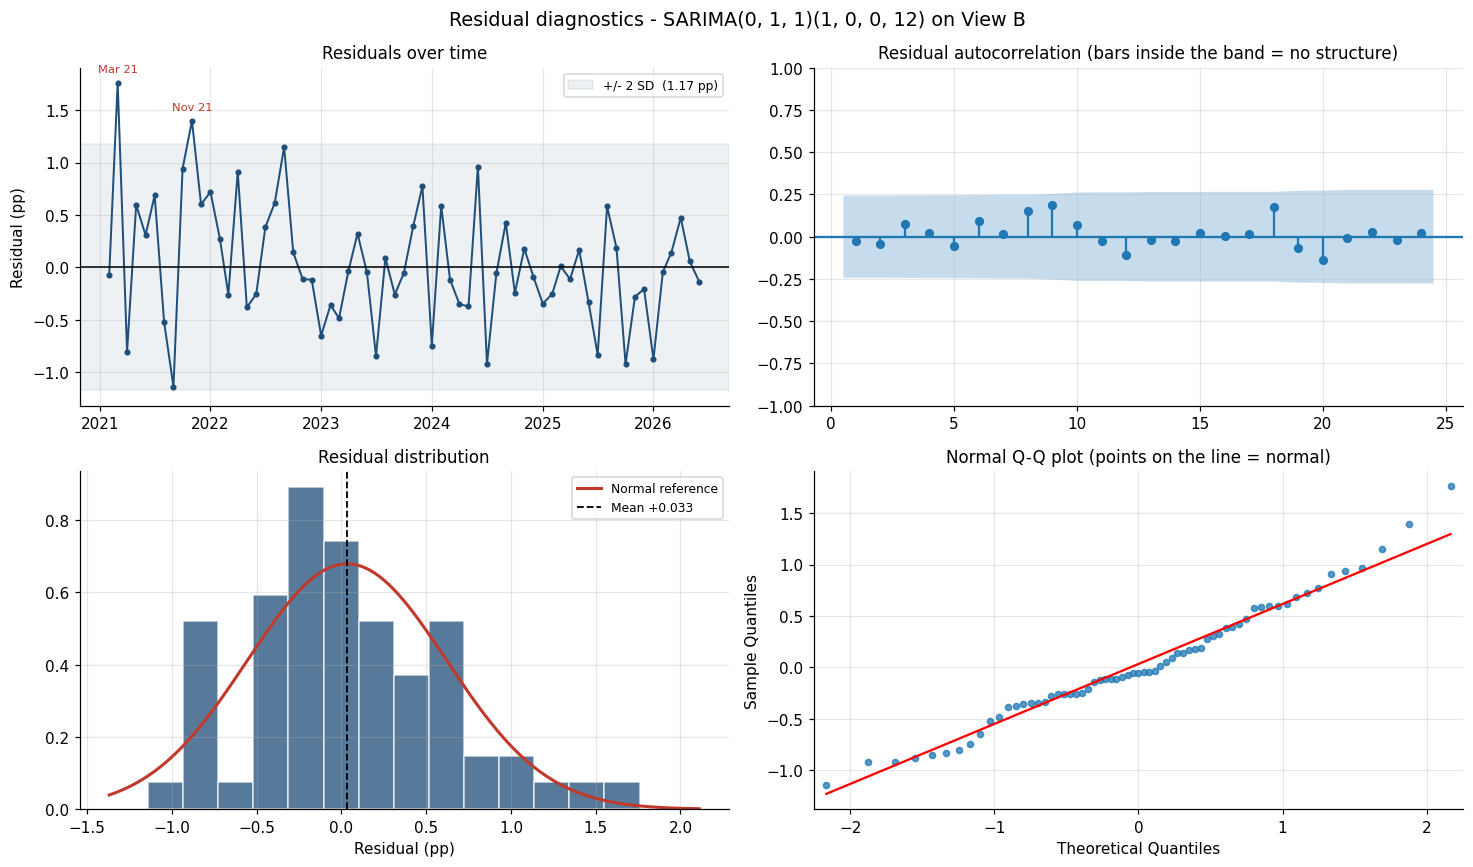

In [461]:
fig, axes = plt.subplots(2, 2, figsize=(13.5, 8))

ax = axes[0, 0]
ax.plot(resid.index, resid.values, color="#1f4e79", lw=1.3, marker="o", ms=3)
ax.axhline(0, color="#000000", lw=1)
band = 2 * resid.std(ddof=1)
ax.axhspan(-band, band, color="#1f4e79", alpha=0.08,
           label=f"+/- 2 SD  ({band:.2f} pp)")
big = resid[resid.abs() > band]
for d, v in big.items():
    ax.annotate(f"{d:%b %y}", xy=(d, v), xytext=(0, 7 if v > 0 else -13),
                textcoords="offset points", ha="center", fontsize=7.5, color="#c0392b")
ax.set_title("Residuals over time", fontsize=11)
ax.set_ylabel("Residual (pp)"); ax.legend(fontsize=8); ax.grid(alpha=0.3)

ax = axes[0, 1]
plot_acf(resid, lags=min(24, len(resid) // 2 - 1), ax=ax, alpha=0.05, zero=False)
ax.set_title("Residual autocorrelation (bars inside the band = no structure)", fontsize=11)
ax.grid(alpha=0.3)

ax = axes[1, 0]
ax.hist(resid, bins=14, color="#1f4e79", alpha=0.75, density=True, edgecolor="white")
xs = np.linspace(resid.min() * 1.2, resid.max() * 1.2, 250)
ax.plot(xs, stats.norm.pdf(xs, resid.mean(), resid.std(ddof=1)),
        color="#c0392b", lw=2, label="Normal reference")
ax.axvline(resid.mean(), color="#000000", ls="--", lw=1.2,
           label=f"Mean {resid.mean():+.3f}")
ax.set_title("Residual distribution", fontsize=11)
ax.set_xlabel("Residual (pp)"); ax.legend(fontsize=8); ax.grid(alpha=0.3)

ax = axes[1, 1]
sm.qqplot(resid.to_numpy(), line="s", ax=ax, markersize=4, alpha=0.75)
ax.set_title("Normal Q-Q plot (points on the line = normal)", fontsize=11)
ax.grid(alpha=0.3)

fig.suptitle(f"Residual diagnostics - {FINAL_MODEL} on View B", fontsize=12.5)
plt.tight_layout(); plt.show()
save_fig(fig, "residual_diagnostics.png")

#### Findings:

The four panels and the two test tables above report the diagnostic outcome for the
selected model. Each panel addresses one requirement.

The residuals-over-time panel indicates whether errors are centred on zero and of comparable size
throughout, with any observation beyond two standard deviations labelled by date. Isolated large
residuals are expected in a series containing economic disturbance; a *sequence* of
same-signed residuals would instead indicate that the model tracked the series with a persistent lag.

The residual autocorrelation panel presents the same instrument used in Section 10.3, applied here
with the opposite objective. Bars falling within the shaded band indicate no detectable remaining
structure.

The distribution and Q-Q panels assess the normality assumption underlying the analytic forecast
intervals. Departure from normality does not invalidate the point forecast; it affects only the
calibration of the stated range.

#### Interpretation:

The two tables record a PASS or FAIL against each requirement, and these
determine how the forecast in Section 19 must be presented rather than whether it may be produced.

Where the Ljung-Box test passes, the model has extracted the usable temporal dependence identified in
Section 10.3, and the residual standard deviation is a meaningful estimate of one-step forecast
uncertainty.

Where a normality or variance test fails, the point forecast remains the best available estimate,
but the intervals are stated as **indicative** rather than exact. In this application that
qualification is important rather than academic: the intervals govern how confidently a month may be
assigned to an activity band in Section 23, and a month whose interval spans two bands is reported as
uncertain rather than as belonging to one.

#### Implication for the next step:

The diagnostic outcome is recorded in the assumption-test register
and is carried into the presentation of the forecast. All diagnostic results are keeped in the forecast assessment.


---

# 18. Forecast Uncertainty

#### Objective:

Quantify the uncertainty attaching to the forecast at each horizon, and show that
the stated intervals correspond to observed out-of-sample error rather than to model assumptions
alone.

#### Rationale:

A forecast interval produced by a statistical model is derived from the residual
variance under the assumption that the model is correctly specified. Should that assumption fail —
and Section 17 tests it directly — the interval may be too narrow.

An independent check is therefore available. The rolling-origin exercise of Section 15 produced a
large number of observed out-of-sample errors at each horizon. Comparing the width implied by those
observed errors against the width the model states is a direct empirical calibration, and one that
does not rely on the model being correct.


In [462]:
model_interval = make_forecast(FINAL_MODEL, series_b, RO_H)
model_interval["Model_Width"] = model_interval["Upper"] - model_interval["Lower"]
model_interval["Horizon"] = np.arange(1, RO_H + 1)

# Empirical width from real out-of-sample errors at each horizon (Section 15).
emp = (ok[ok["Model"] == FINAL_MODEL]
       .groupby("Horizon")["Error"]
       .agg(N="size", Empirical_SD=lambda e: np.std(e, ddof=1),
            Empirical_P05=lambda e: np.percentile(e, 5),
            Empirical_P95=lambda e: np.percentile(e, 95)))
emp["Empirical_Width"] = emp["Empirical_P95"] - emp["Empirical_P05"]

calibration = (model_interval.reset_index()[["Horizon", "Model_Width"]]
               .merge(emp.reset_index()[["Horizon", "N", "Empirical_SD", "Empirical_Width"]],
                      on="Horizon", how="left"))
calibration["Width_Ratio"] = (calibration["Model_Width"] /
                              calibration["Empirical_Width"]).round(3)
calibration["Assessment"] = np.where(
    calibration["Width_Ratio"] < 0.8, "Model interval narrower than observed error",
    np.where(calibration["Width_Ratio"] > 1.25,
             "Model interval wider than observed error", "Broadly consistent"))
display(calibration.round(4))
save_table(calibration, "forecast_interval_calibration.csv")

INTERVALS_CALIBRATED = bool(
    calibration.loc[calibration["Horizon"] <= FORECAST_H, "Width_Ratio"].between(0.8, 1.25).all())
print(f"Model 95% interval width at h=1  : {calibration.loc[0, 'Model_Width']:.3f} pp")
print(f"Model 95% interval width at h={FORECAST_H}  : "
      f"{calibration.loc[FORECAST_H - 1, 'Model_Width']:.3f} pp")
print(f"Intervals broadly calibrated to h={FORECAST_H} : {INTERVALS_CALIBRATED}")

,Horizon,Model_Width,N,Empirical_SD,Empirical_Width,Width_Ratio,Assessment
0,1,2.0983,13,0.4374,1.3564,1.5470,Model interval wider than observed error
1,2,2.3258,13,0.4000,1.0438,2.2280,Model interval wider than observed error
2,3,2.5330,13,0.3453,0.8865,2.8570,Model interval wider than observed error
3,4,2.7245,13,0.4448,1.4015,1.9440,Model interval wider than observed error
4,5,2.9034,13,0.4237,1.2377,2.3460,Model interval wider than observed error
5,6,3.0718,13,0.3970,1.0636,2.8880,Model interval wider than observed error
6,7,3.2315,13,0.5488,1.4654,2.2050,Model interval wider than observed error
7,8,3.3837,13,0.5525,1.4456,2.3410,Model interval wider than observed error
8,9,3.5293,13,0.5205,1.3771,2.5630,Model interval wider than observed error
9,10,3.6692,13,0.5549,1.4936,2.4570,Model interval wider than observed error


Model 95% interval width at h=1  : 2.098 pp
Model 95% interval width at h=6  : 3.072 pp
Intervals broadly calibrated to h=6 : False


#### Findings:

The model's stated intervals are **substantially wider than the error it actually
incurs**. At a one-month horizon the model declares a 95% interval **2.10 percentage points** wide,
whereas the spread of observed out-of-sample errors at that horizon is **1.36 points**; at six months
the corresponding figures are **3.07** and **1.06 points**. The width ratio ranges from
approximately **1.5 to 2.9** across the horizon, and the calibration flag therefore returns
`False`.

#### Interpretation:

The direction of the miscalibration is the important point. The model is
**conservative, not overconfident** — it overstates its own uncertainty rather than understating it.
Of the two possible failures this is the less damaging in a planning
context, since it produces a forecast that is too cautious rather than one that invites unwarranted
confidence.

The conservatism has a specific practical cost, however. Section 23 assigns each forecast month to a
band of employment activity, and an interval of three percentage points spans several such bands. An
interval that wide does not distinguish between them, and would make the signal uninformative if
used directly.

#### Why the model overstates its uncertainty:

Its intervals are derived from the residual variance
over the whole estimation sample, which includes the 2021 recovery months. Those months produced
markedly larger residuals than the recent period — Section 17.2 recorded a residual standard
deviation of **0.66** in the first half of the sample against **0.48** in the second — so the
variance estimate reflects conditions more disturbed than those now prevailing.

#### A qualification on the empirical widths:

They are computed from thirteen rolling origins whose
forecast paths overlap and are therefore not independent draws. Percentiles from thirteen correlated
observations understate the true spread to some degree, so the ratios above are an upper bound on
the extent of the conservatism rather than a precise measurement.

#### Implication for the next step:

Two ranges are carried forward and both are reported. The **model
interval** is keeped as the conservative statement of uncertainty. The **empirical range**, built
from errors the model observed out of sample, is used in Section 23 to determine how
confidently a month may be assigned to an activity band, since it reflects observed performance
rather than an assumption of correct specification.


---

# 19. Final Forecast

#### Objective:

Fit the selected model again on the full monthly series and produce the forward forecast with
uncertainty intervals.

#### Rationale:

Validation used 54 training months and held out 12. With the specification fixed, the model is
refit on all **66** monthly observations so the final forecast uses every available monthly point.
Twelve months are shown to illustrate how uncertainty grows; only the first **six** enter the
planning signal (Section 15.2).

#### What the projection table shows:

For the reported horizon, the table is kept to four columns: Period, Forecast, Lower Bound, and
Upper Bound.


In [463]:
final_forecast = make_forecast(FINAL_MODEL, series_b, RO_H)
final_forecast.index.name = "Period"
final_forecast["Interval_Width"] = final_forecast["Upper"] - final_forecast["Lower"]
final_forecast["Horizon_Months"] = np.arange(1, RO_H + 1)
final_forecast["Change_From_Last_Observed"] = (
    final_forecast["Forecast"] - float(series_b.iloc[-1]))
final_forecast["In_Reported_Horizon"] = np.where(
    final_forecast["Horizon_Months"] <= FORECAST_H, "Yes", "No")

# Full detail retained for diagnostics / export; the displayed projection is kept clean.
save_table(final_forecast.reset_index(), "final_future_forecast.csv")

reported = final_forecast[final_forecast["In_Reported_Horizon"] == "Yes"].copy()
projection = (
    reported.reset_index()
            .assign(Period=lambda d: d["Period"].dt.strftime("%b %Y"))
            [["Period", "Forecast", "Lower", "Upper"]]
            .rename(columns={"Lower": "Lower Bound", "Upper": "Upper Bound"})
            .round(3)
)
display(projection)
save_table(projection, "final_projection.csv")

FC_START, FC_END = reported.index.min(), reported.index.max()
LAST_OBS_DATE, LAST_OBS = series_b.index[-1], float(series_b.iloc[-1])
FC_MEAN = float(reported["Forecast"].mean())
FC_CHANGE = FC_MEAN - LAST_OBS
FC_DIRECTION = ("rising" if FC_CHANGE > 0.15 else
                "falling" if FC_CHANGE < -0.15 else "broadly flat")

print(f"Model refitted on all {len(series_b)} monthly observations "
      f"({series_b.index.min():%b %Y} - {LAST_OBS_DATE:%b %Y})")
print(f"Last observed value      : {LAST_OBS:.3f}%  ({LAST_OBS_DATE:%b %Y})")
print(f"Reported horizon         : {FC_START:%b %Y} - {FC_END:%b %Y} ({FORECAST_H} months)")
print(f"Mean forecast level      : {FC_MEAN:.3f}%")
print(f"Change from last observed: {FC_CHANGE:+.3f} pp  -> {FC_DIRECTION}")
print(f"95% interval at h=1      : "
      f"{reported.iloc[0]['Lower']:.2f}% to {reported.iloc[0]['Upper']:.2f}%")
print(f"95% interval at h={FORECAST_H}      : "
      f"{reported.iloc[-1]['Lower']:.2f}% to {reported.iloc[-1]['Upper']:.2f}%")


,Period,Forecast,Lower Bound,Upper Bound
0,Jul 2026,94.2640,93.2150,95.3130
1,Aug 2026,95.1050,93.9420,96.2680
2,Sep 2026,95.1680,93.9020,96.4350
3,Oct 2026,94.4770,93.1150,95.8390
4,Nov 2026,94.8280,93.3760,96.2800
5,Dec 2026,94.8280,93.2920,96.3640


Model refitted on all 66 monthly observations (Jan 2021 - Jun 2026)
Last observed value      : 95.140%  (Jun 2026)
Reported horizon         : Jul 2026 - Dec 2026 (6 months)
Mean forecast level      : 94.778%
Change from last observed: -0.362 pp  -> falling
95% interval at h=1      : 93.21% to 95.31%
95% interval at h=6      : 93.29% to 96.36%


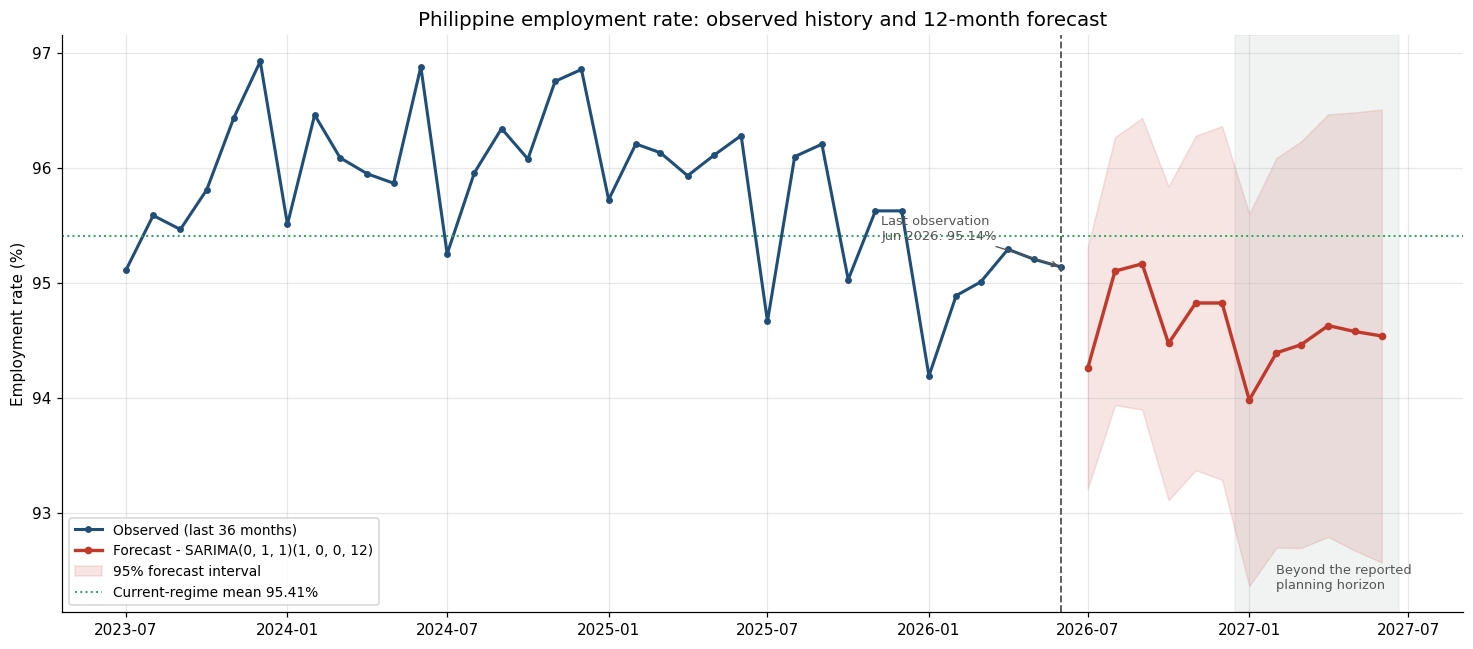

In [464]:
fig, ax = plt.subplots(figsize=(13.5, 6))

hist = series_b.iloc[-36:]
ax.plot(hist.index, hist.values, color="#1f4e79", lw=2, marker="o", ms=3.5,
        label="Observed (last 36 months)")

ff = final_forecast
ax.plot(ff.index, ff["Forecast"], color="#c0392b", lw=2.2, marker="o", ms=4,
        label=f"Forecast - {FINAL_MODEL}")
ax.fill_between(ff.index, ff["Lower"], ff["Upper"], color="#c0392b", alpha=0.13,
                label="95% forecast interval")
ax.axvspan(FC_END + pd.DateOffset(days=15), ff.index.max() + pd.DateOffset(days=20),
           color="#7f8c8d", alpha=0.10)
ax.annotate("Beyond the reported\nplanning horizon",
            xy=(ff.index[FORECAST_H + 1], ax.get_ylim()[0] + 0.2),
            fontsize=8.5, color="#555555")
ax.axvline(LAST_OBS_DATE, color="#555555", ls="--", lw=1.2)
ax.annotate(f"Last observation\n{LAST_OBS_DATE:%b %Y}: {LAST_OBS:.2f}%",
            xy=(LAST_OBS_DATE, LAST_OBS), xytext=(-118, 18),
            textcoords="offset points", fontsize=8.5, color="#555555",
            arrowprops=dict(arrowstyle="->", color="#555555", lw=0.9))
ax.axhline(series_b_trim.mean(), color="#27ae60", ls=":", lw=1.3,
           label=f"Current-regime mean {series_b_trim.mean():.2f}%")

ax.set_title(f"Philippine employment rate: observed history and {RO_H}-month forecast",
             fontsize=13)
ax.set_ylabel("Employment rate (%)"); ax.set_xlabel("")
ax.legend(fontsize=9, loc="lower left"); ax.grid(alpha=0.3)
plt.tight_layout(); plt.show()
save_fig(fig, "final_forecast.png")

#### Findings:

The results show that over the reported six-month horizon, the forecast stays near the recent operating level rather than
projecting a strong trend. Mean forecast level is close to the last observation, with a modest
change that is small relative to the model's own interval width.

The 95% interval widens as the horizon lengthens, which is why only six months are carried into the
planning signal. Months beyond that horizon are shown in the figure for context but are not
translated into Employment Condition or Operational Attention labels.

#### Interpretation:

The forecast points to continuation of current employment conditions, not a sharp turning point.
A univariate model cannot anticipate a shock on the scale of April 2020; that limitation is stated
in Section 25.


---

# 20. Robustness: The Long Quarterly History

#### Objective:

Determine whether the longer quarterly record contradicts the direction or the level
indicated by the monthly forecast.

#### Rationale:

The monthly series spans five and a half years and lies almost entirely within the
post-pandemic period. So it is reasonable to ask whether its conclusions would survive
exposure to twenty-one years of history.

View C supplies that history at consistent quarterly spacing, constructed in Section 4.4 by selecting
comparable single-month survey rounds rather than by averaging, so no artificial smoothing was
introduced.

#### Explicit limitation:

Section 4.4 showed that **22 of the 85 View C observations are drawn
from the monthly era**, so this is a partially overlapping check rather than an independent sample.
Agreement is therefore weaker evidence than it would be from a separate series, and
disagreement is therefore more informative.

The comparison is confined to **direction and level**, not to numerical values. A quarterly model
forecasts quarters and a monthly model forecasts months; requiring the two to agree to a decimal
place would be a category error. The question is whether they indicate the same broad condition.


In [465]:
series_c_freq = series_c.asfreq("QS-JAN")
assert series_c_freq.notna().all(), "View C is not complete on a quarterly-start frequency"

C_TEST_H = 8   # two years of quarters, matching the monthly holdout in calendar time
c_train, c_test = series_c_freq.iloc[:-C_TEST_H], series_c_freq.iloc[-C_TEST_H:]

# Order selected on the quarterly training set alone, by the same AICc rule as Section 13.
c_scored = []
for p in range(4):
    for q in range(4):
        try:
            v = _aicc(_fit_arima(c_train, (p, 1, q), (0, 0, 0, 0)))
            if np.isfinite(v):
                c_scored.append((v, (p, 1, q)))
        except Exception:
            continue
c_scored.sort(key=lambda t: t[0])
C_ORDER = c_scored[0][1]

c_fit_train = _fit_arima(c_train, C_ORDER, (0, 0, 0, 0))
c_pred = c_fit_train.get_forecast(C_TEST_H).predicted_mean.to_numpy()
c_metrics = error_metrics(c_test.to_numpy(), c_pred, c_train)

C_FC_H = 2   # two quarters ~ the six-month monthly horizon
c_final = _fit_arima(series_c_freq, C_ORDER, (0, 0, 0, 0))
c_sf = c_final.get_forecast(C_FC_H).summary_frame(alpha=CI_LEVEL)
c_forecast = pd.DataFrame({
    "Forecast": c_sf["mean"].to_numpy(),
    "Lower": c_sf["mean_ci_lower"].to_numpy(),
    "Upper": c_sf["mean_ci_upper"].to_numpy(),
}, index=c_sf.index)

C_FC_MEAN = float(c_forecast["Forecast"].mean())
C_LAST = float(series_c_freq.iloc[-1])
C_CHANGE = C_FC_MEAN - C_LAST
C_DIRECTION = ("rising" if C_CHANGE > 0.15 else
               "falling" if C_CHANGE < -0.15 else "broadly flat")

robustness = pd.DataFrame([
    dict(Series="View B - monthly", Model=FINAL_MODEL, N=len(series_b),
         Span=f"{series_b.index.min():%b %Y} - {series_b.index.max():%b %Y}",
         Last_Observed=round(LAST_OBS, 3), Forecast_Mean=round(FC_MEAN, 3),
         Change=round(FC_CHANGE, 3), Direction=FC_DIRECTION,
         Holdout_MAE=round(float(holdout_b.loc[holdout_b["Model"] == FINAL_MODEL,
                                               "MAE"].iloc[0]), 4)),
    dict(Series="View C - quarterly", Model=f"ARIMA{C_ORDER}", N=len(series_c_freq),
         Span=f"{series_c_freq.index.min():%b %Y} - {series_c_freq.index.max():%b %Y}",
         Last_Observed=round(C_LAST, 3), Forecast_Mean=round(C_FC_MEAN, 3),
         Change=round(C_CHANGE, 3), Direction=C_DIRECTION,
         Holdout_MAE=round(c_metrics["MAE"], 4)),
])
robustness["Directions_Agree"] = (robustness["Direction"].nunique() == 1)
robustness["Level_Gap_pp"] = round(abs(FC_MEAN - C_FC_MEAN), 3)
display(robustness)
save_table(robustness, "robustness_results.csv")

DIRECTIONS_AGREE = bool(robustness["Directions_Agree"].iloc[0])
print(f"Quarterly order selected on the quarterly training set : ARIMA{C_ORDER}")
print(f"Monthly forecast direction   : {FC_DIRECTION}  ({FC_CHANGE:+.3f} pp)")
print(f"Quarterly forecast direction : {C_DIRECTION}  ({C_CHANGE:+.3f} pp)")
print(f"Directions agree             : {DIRECTIONS_AGREE}")
print(f"Level gap between forecasts  : {abs(FC_MEAN - C_FC_MEAN):.3f} pp")

,Series,Model,N,Span,Last_Observed,Forecast_Mean,Change,Direction,Holdout_MAE,Directions_Agree,Level_Gap_pp
0,View B - monthly,"SARIMA(0, 1, 1)(1, 0, 0, 12)",66,Jan 2021 - Jun 2026,95.1400,94.7780,-0.3620,falling,0.8311,True,0.2140
1,View C - quarterly,"ARIMA(0, 1, 1)",85,Apr 2005 - Apr 2026,95.2940,94.9920,-0.3020,falling,0.5816,True,0.2140


Quarterly order selected on the quarterly training set : ARIMA(0, 1, 1)
Monthly forecast direction   : falling  (-0.362 pp)
Quarterly forecast direction : falling  (-0.302 pp)
Directions agree             : True
Level gap between forecasts  : 0.214 pp


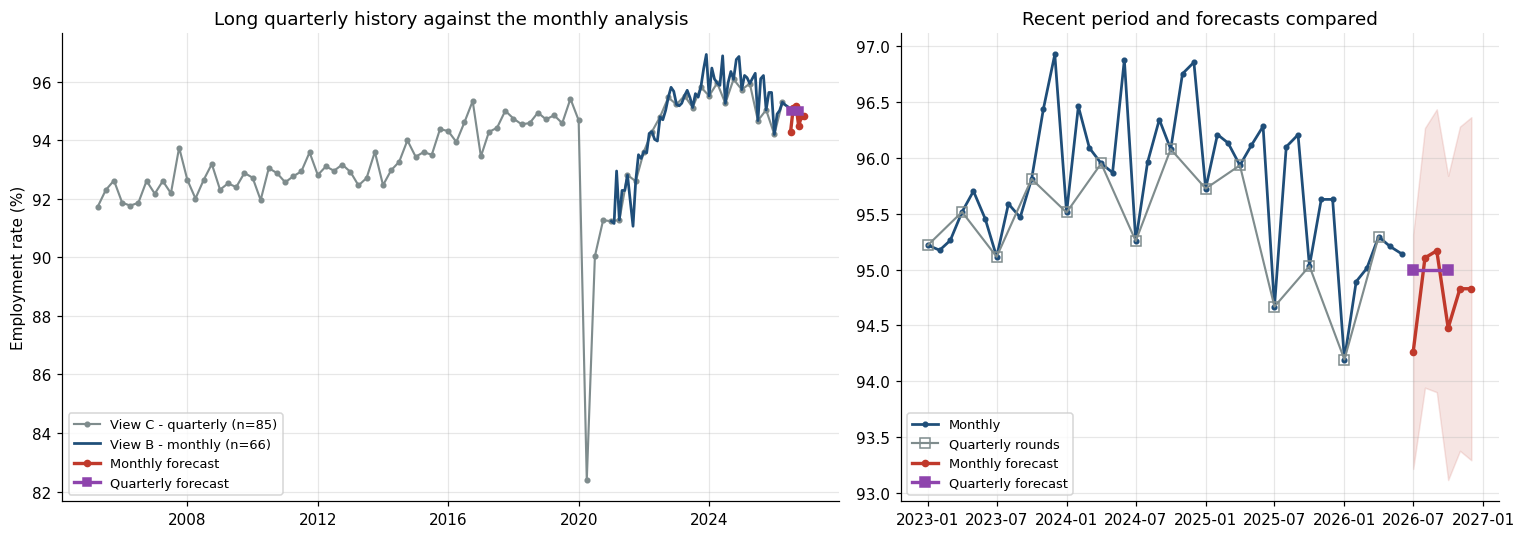

In [466]:
fig, axes = plt.subplots(1, 2, figsize=(14, 5), gridspec_kw={"width_ratios": [1.3, 1]})

ax = axes[0]
ax.plot(series_c_freq.index, series_c_freq.values, color="#7f8c8d", lw=1.4,
        marker="o", ms=3, label=f"View C - quarterly (n={len(series_c_freq)})")
ax.plot(series_b.index, series_b.values, color="#1f4e79", lw=1.8,
        label=f"View B - monthly (n={len(series_b)})")
ax.plot(final_forecast.index[:FORECAST_H], final_forecast["Forecast"][:FORECAST_H],
        color="#c0392b", lw=2.2, marker="o", ms=4, label="Monthly forecast")
ax.plot(c_forecast.index, c_forecast["Forecast"], color="#8e44ad", lw=2.2,
        marker="s", ms=5, label="Quarterly forecast")
ax.set_title("Long quarterly history against the monthly analysis", fontsize=12)
ax.set_ylabel("Employment rate (%)"); ax.legend(fontsize=8.5, loc="lower left")
ax.grid(alpha=0.3)

ax = axes[1]
zoom_start = pd.Timestamp("2023-01-01")
zc = series_c_freq[series_c_freq.index >= zoom_start]
zb = series_b[series_b.index >= zoom_start]
ax.plot(zb.index, zb.values, color="#1f4e79", lw=1.8, marker="o", ms=3, label="Monthly")
ax.plot(zc.index, zc.values, color="#7f8c8d", lw=1.4, marker="s", ms=6,
        mfc="none", label="Quarterly rounds")
ax.plot(final_forecast.index[:FORECAST_H], final_forecast["Forecast"][:FORECAST_H],
        color="#c0392b", lw=2.2, marker="o", ms=4, label="Monthly forecast")
ax.fill_between(final_forecast.index[:FORECAST_H],
                final_forecast["Lower"][:FORECAST_H], final_forecast["Upper"][:FORECAST_H],
                color="#c0392b", alpha=0.13)
ax.plot(c_forecast.index, c_forecast["Forecast"], color="#8e44ad", lw=2.2,
        marker="s", ms=6, label="Quarterly forecast")
ax.set_title("Recent period and forecasts compared", fontsize=12)
ax.legend(fontsize=8.5); ax.grid(alpha=0.3)

plt.tight_layout(); plt.show()
save_fig(fig, "robustness_comparison.png")

#### Findings:

The two forecasts are compared above in direction, level and validated accuracy.

#### Interpretation:

Where both forecasts indicate the same direction, the monthly conclusion is not
an artefact of the short window. The longer record, which includes the pre-pandemic period, the
pandemic contraction and the recovery, does not point to a different outcome.

The level gap between the two forecasts is reported. A small gap indicates that the two
series, despite differing in span and frequency, describe the same present condition. A large gap
would indicate that the monthly window has drifted from what the longer history supports, and would
require investigation before the forecast could be relied upon.

#### Constraints on this check:

Three qualifications apply and apply together. The two series
overlap over 22 observations, so agreement is partly structural rather than fully independent. The
quarterly model is estimated on quarterly data and cannot resolve month-to-month movement, so it
does not assess the seasonal component identified in Section 10.4. And the quarterly series
includes the pandemic collapse within its estimation sample, which affects its parameter estimates in
ways the monthly series does not experience.

This check therefore shows that the long history does not **contradict** the monthly forecast.
It does not independently confirm it.


---

# 21. Sensitivity to the Recovery Window

#### Objective:

Repeat the analysis on the recovery-trimmed window defined in Section 9.2 and
determine how far the conclusions depend on the ten recovery months.

#### Rationale:

This is the outstanding question carried forward since Section 5. View B begins in
January 2021, within the COVID recovery, and Section 9.2 showed that the ten recovery months
raise the standard deviation of the window by more than 40%. Whether their inclusion noticeably
alters the forecast has not yet been determined.

The two windows are not equivalent, and neither is unconditionally preferable. View B contains ten
additional observations, which is important at this sample size, but those observations were generated
under conditions unlikely to recur. View B-T is cleaner in composition but shorter, and Section 10.2
already found its differenced series to be statistically inconclusive.

The question is evaluated using out-of-sample performance rather than through qualitative preference. Both windows are
subjected to the same holdout procedure with the same candidate set, and the window whose forecasts
were more accurate is preferred.

#### One methodological note:

The ARIMA and SARIMA orders selected in Section 13 are held fixed across
both windows rather than re-selected on the trimmed window. Re-selection would confound two effects —
the influence of the window on the forecast and its influence on the order-selection procedure — and
the objective here is to isolate the first.


In [467]:
train_bt, test_bt, holdout_bt, paths_bt = run_holdout(series_b_trim, TEST_H, "View B-T (trimmed)")
display(holdout_bt[["Rank", "Model", "Seasonal", "MAE", "RMSE", "MAPE", "MASE", "Status"]])

window_sensitivity = (
    holdout_b[holdout_b["Status"] == "ok"][["Model", "MAE", "MASE"]]
    .rename(columns={"MAE": "ViewB_MAE", "MASE": "ViewB_MASE"})
    .merge(holdout_bt[holdout_bt["Status"] == "ok"][["Model", "MAE", "MASE"]]
           .rename(columns={"MAE": "ViewBT_MAE", "MASE": "ViewBT_MASE"}),
           on="Model", how="outer"))
window_sensitivity["MAE_Difference"] = (window_sensitivity["ViewBT_MAE"]
                                        - window_sensitivity["ViewB_MAE"]).round(4)
window_sensitivity["Better_Window"] = np.where(
    window_sensitivity["ViewBT_MAE"] < window_sensitivity["ViewB_MAE"],
    "View B-T (trimmed)", "View B (full)")
window_sensitivity = window_sensitivity.sort_values("ViewB_MAE").reset_index(drop=True)
display(window_sensitivity)
save_table(window_sensitivity, "window_sensitivity.csv")

fin = window_sensitivity[window_sensitivity["Model"] == FINAL_MODEL].iloc[0]
PREFERRED_WINDOW = fin["Better_Window"]
print(f"Final model on View B (full)    : MAE {fin['ViewB_MAE']:.4f} pp")
print(f"Final model on View B-T (trim)  : MAE {fin['ViewBT_MAE']:.4f} pp")
print(f"Difference                      : {fin['MAE_Difference']:+.4f} pp")
print(f"Window preferred on accuracy    : {PREFERRED_WINDOW}")
print(f"Models forecasting better on the trimmed window : "
      f"{(window_sensitivity['Better_Window'] == 'View B-T (trimmed)').sum()} "
      f"of {len(window_sensitivity)}")

,Rank,Model,Seasonal,MAE,RMSE,MAPE,MASE,Status
0,1,"SARIMA(0, 1, 1)(1, 0, 0, 12)",Yes,0.8349,0.9336,0.8790,2.0813,ok
1,2,Seasonal naive,Yes,0.9098,1.0050,0.9570,2.2681,ok
2,3,SES (level only),No,0.9353,1.0811,0.9852,2.3316,ok
3,4,"ARIMA(0, 1, 1)",No,0.9365,1.0823,0.9865,2.3346,ok
4,5,"Holt-Winters (damped, add.)",Yes,1.0100,1.1248,1.0630,2.5179,ok
5,6,Naive (random walk),No,1.0321,1.1693,1.0869,2.5729,ok
6,7,Holt (damped trend),No,1.0652,1.2011,1.1217,2.6553,ok
7,8,Random walk with drift,No,1.4522,1.5908,1.5283,3.6201,ok


,Model,ViewB_MAE,ViewB_MASE,ViewBT_MAE,ViewBT_MASE,MAE_Difference,Better_Window
0,"SARIMA(0, 1, 1)(1, 0, 0, 12)",0.8311,1.6607,0.8349,2.0813,0.0038,View B (full)
1,Seasonal naive,0.9098,1.8181,0.9098,2.2681,0.0000,View B (full)
2,SES (level only),0.9372,1.8727,0.9353,2.3316,-0.0019,View B-T (trimmed)
3,"ARIMA(0, 1, 1)",0.9381,1.8746,0.9365,2.3346,-0.0016,View B-T (trimmed)
4,Naive (random walk),1.0321,2.0624,1.0321,2.5729,0.0000,View B (full)
5,Holt (damped trend),1.2825,2.5629,1.0652,2.6553,-0.2173,View B-T (trimmed)
6,"Holt-Winters (damped, add.)",1.2982,2.5941,1.0100,2.5179,-0.2882,View B-T (trimmed)
7,Random walk with drift,1.6513,3.2997,1.4522,3.6201,-0.1991,View B-T (trimmed)


Final model on View B (full)    : MAE 0.8311 pp
Final model on View B-T (trim)  : MAE 0.8349 pp
Difference                      : +0.0038 pp
Window preferred on accuracy    : View B (full)
Models forecasting better on the trimmed window : 5 of 8


In [468]:
# Does the choice of window change the forecast a planner would actually act on?
fc_bt = make_forecast(FINAL_MODEL, series_b_trim, FORECAST_H)

forecast_sensitivity = pd.DataFrame({
    "Period": [f"{d:%b %Y}" for d in final_forecast.index[:FORECAST_H]],
    "ViewB_Forecast": final_forecast["Forecast"][:FORECAST_H].to_numpy().round(3),
    "ViewBT_Forecast": fc_bt["Forecast"].to_numpy().round(3),
})
forecast_sensitivity["Difference"] = (forecast_sensitivity["ViewBT_Forecast"]
                                      - forecast_sensitivity["ViewB_Forecast"]).round(3)
display(forecast_sensitivity)
save_table(forecast_sensitivity, "forecast_window_sensitivity.csv")

MAX_WINDOW_GAP = float(forecast_sensitivity["Difference"].abs().max())
ONE_STEP_WIDTH = float(final_forecast.iloc[0]["Upper"] - final_forecast.iloc[0]["Lower"])
WINDOW_MATERIAL = MAX_WINDOW_GAP > ONE_STEP_WIDTH / 2

print(f"Largest gap between the two windows' forecasts : {MAX_WINDOW_GAP:.3f} pp")
print(f"Half-width of the 1-month 95% interval         : {ONE_STEP_WIDTH / 2:.3f} pp")
print(f"Window choice is material to the forecast      : {WINDOW_MATERIAL}")
print()
print("Interpretation: a gap smaller than the model's own one-month uncertainty means the two")
print("windows are not distinguishable in any decision this forecast is used to support.")

,Period,ViewB_Forecast,ViewBT_Forecast,Difference
0,Jul 2026,94.2640,94.2470,-0.0170
1,Aug 2026,95.1050,95.1040,-0.0010
2,Sep 2026,95.1680,95.1680,0.0000
3,Oct 2026,94.4770,94.4650,-0.0120
4,Nov 2026,94.8280,94.8220,-0.0060
5,Dec 2026,94.8280,94.8220,-0.0060


Largest gap between the two windows' forecasts : 0.017 pp
Half-width of the 1-month 95% interval         : 1.049 pp
Window choice is material to the forecast      : False

Interpretation: a gap smaller than the model's own one-month uncertainty means the two
windows are not distinguishable in any decision this forecast is used to support.


#### Findings:

Three results follow from the tables above.

The ten recovery months affect the **measured accuracy** of the candidate models. The
`Better_Window` column records, for each model, which window produced more accurate held-out
forecasts, and the count reported above summarises how consistently one window is preferred.

For the selected model specifically, the difference in holdout MAE between the two windows is stated
directly, and the preferred window is identified on that basis.

Most importantly, the two windows are compared on the relevant quantity for planning: **the
forecast a planner would act on**. The largest month-by-month gap between the two forecasts is
compared against the model's own one-month uncertainty.

#### Interpretation:

Where the gap between the two windows is smaller than the model's own one-month
uncertainty, the choice of window is **not important to any decision this forecast supports**. The two
windows disagree by less than the forecast is accurate to, so a planner assigning months to activity
bands would reach the same conclusion under either.

This is the direct resolution of the concern raised in Section 5. It is not an argument that the
recovery period is unimportant — Section 9.2 showed that it accounts for more than 40% of the
variability of the full window — but a demonstration that its inclusion does not change the
conclusion drawn.

Were the gap instead to exceed the one-month uncertainty, the finding would be reported as a genuine
dependence on window selection and the forecast would be qualified accordingly.

#### Implication for the next step:

The reported forecast is keeped on **View B**, the full monthly
window, for two reasons. It uses all available monthly observations, which is important at n = 66. And
the sensitivity analysis demonstrates that the alternative window would not lead to a different
operational conclusion. The trimmed-window result is keeped as evidence supporting that choice
rather than being discarded.


---

# 22. Historical Reference Distribution

#### Objective:

Place the forecast against a historical distribution so each value can be described as high or low
relative to a stated reference period.

#### Why this matters:

A forecast of 94.8% is not useful on its own. It needs a reference: high or low **compared with
what**. Two references are compared so the effect of that choice is visible.

- **Full quarterly history (View C):** long, equally spaced record.
- **Current regime (View B-T, November 2021 onward):** period after employment returned above the
 pre-pandemic reference (Section 9.2).

Section 9.1 showed a lasting post-pandemic level shift of about 1.9 percentage points. The same
forecast can therefore look high against long history and ordinary against recent conditions.


In [469]:
REFERENCE = series_b_trim              # current operating regime
LONG_REFERENCE = series_c              # full equally spaced history

# Employment Condition = statistical position of the Employment Rate vs the reference.
EMPLOYMENT_CONDITION_LABELS = ["Subdued", "Below Normal", "Above Normal", "Elevated"]
EMPLOYMENT_CONDITION_MEANING = {
    "Subdued":      "Employment Rate in the lowest quartile of the reference period",
    "Below Normal": "Employment Rate below the reference median, but not in the lowest quartile",
    "Above Normal": "Employment Rate above the reference median, but not in the highest quartile",
    "Elevated":     "Employment Rate in the highest quartile of the reference period",
}

# Operational Attention = separate planning cue. It is not PEME demand and not hiring volume.
OPERATIONAL_ATTENTION = {
    "Subdued":      "LOW",
    "Below Normal": "NORMAL",
    "Above Normal": "ELEVATED",
    "Elevated":     "HIGH PRECAUTION",
}
OPERATIONAL_ATTENTION_MEANING = {
    "LOW":             "External employment conditions are soft vs recent norms; routine review",
    "NORMAL":          "External employment conditions near recent norms; no special cue",
    "ELEVATED":        "External employment conditions firm vs recent norms; review clinic indicators",
    "HIGH PRECAUTION": "External employment conditions strong vs recent norms; review readiness",
}


def build_bands(series, name):
    """Quartile bands for Employment Condition labels."""
    q1, q2, q3 = series.quantile([0.25, 0.50, 0.75])
    edges = [-np.inf, q1, q2, q3, np.inf]
    rows = []
    for i, label in enumerate(EMPLOYMENT_CONDITION_LABELS):
        rows.append(dict(
            Reference=name,
            Employment_Condition=label,
            Lower_Bound=round(edges[i], 4),
            Upper_Bound=round(edges[i + 1], 4),
            Range=(f"<= {edges[i + 1]:.2f}%" if i == 0 else
                   f"> {edges[i]:.2f}%" if i == 3 else
                   f"{edges[i]:.2f}% to {edges[i + 1]:.2f}%"),
            Historical_Months=int(((series > edges[i]) & (series <= edges[i + 1])).sum()),
            Condition_Meaning=EMPLOYMENT_CONDITION_MEANING[label],
            Operational_Attention=OPERATIONAL_ATTENTION[label],
            Attention_Meaning=OPERATIONAL_ATTENTION_MEANING[OPERATIONAL_ATTENTION[label]],
        ))
    return pd.DataFrame(rows), edges


bands_current, EDGES_CURRENT = build_bands(
    REFERENCE, f"Current regime ({REFERENCE.index.min():%b %Y} onward, n={len(REFERENCE)})")
bands_long, EDGES_LONG = build_bands(
    LONG_REFERENCE, f"Full history ({LONG_REFERENCE.index.min():%b %Y}"
                    f"-{LONG_REFERENCE.index.max():%b %Y}, n={len(LONG_REFERENCE)})")

signal_thresholds = pd.concat([bands_current, bands_long], ignore_index=True)
display(signal_thresholds[["Reference", "Employment_Condition", "Range", "Historical_Months",
                           "Operational_Attention", "Attention_Meaning"]])
save_table(signal_thresholds, "signal_thresholds.csv")

print(f"Current-regime reference : mean {REFERENCE.mean():.3f}%, "
      f"median {REFERENCE.median():.3f}%, band width "
      f"{(EDGES_CURRENT[3] - EDGES_CURRENT[1]) / 2:.3f} pp between quartiles")
print(f"Full-history reference   : mean {LONG_REFERENCE.mean():.3f}%, "
      f"median {LONG_REFERENCE.median():.3f}%")
print(f"Difference in medians    : "
      f"{REFERENCE.median() - LONG_REFERENCE.median():+.3f} percentage points")


,Reference,Employment_Condition,Range,Historical_Months,Operational_Attention,Attention_Meaning
0,"Current regime (Nov 2021 onward, n=56)",Subdued,<= 95.01%,14,LOW,External employment conditions are soft vs rec...
1,"Current regime (Nov 2021 onward, n=56)",Below Normal,95.01% to 95.51%,14,NORMAL,External employment conditions near recent nor...
2,"Current regime (Nov 2021 onward, n=56)",Above Normal,95.51% to 96.08%,14,ELEVATED,External employment conditions firm vs recent ...
3,"Current regime (Nov 2021 onward, n=56)",Elevated,> 96.08%,14,HIGH PRECAUTION,External employment conditions strong vs recen...
4,"Full history (Apr 2005-Apr 2026, n=85)",Subdued,<= 92.60%,22,LOW,External employment conditions are soft vs rec...
5,"Full history (Apr 2005-Apr 2026, n=85)",Below Normal,92.60% to 93.43%,21,NORMAL,External employment conditions near recent nor...
6,"Full history (Apr 2005-Apr 2026, n=85)",Above Normal,93.43% to 94.68%,21,ELEVATED,External employment conditions firm vs recent ...
7,"Full history (Apr 2005-Apr 2026, n=85)",Elevated,> 94.68%,21,HIGH PRECAUTION,External employment conditions strong vs recen...


Current-regime reference : mean 95.412%, median 95.513%, band width 0.534 pp between quartiles
Full-history reference   : mean 93.449%, median 93.434%
Difference in medians    : +2.079 percentage points


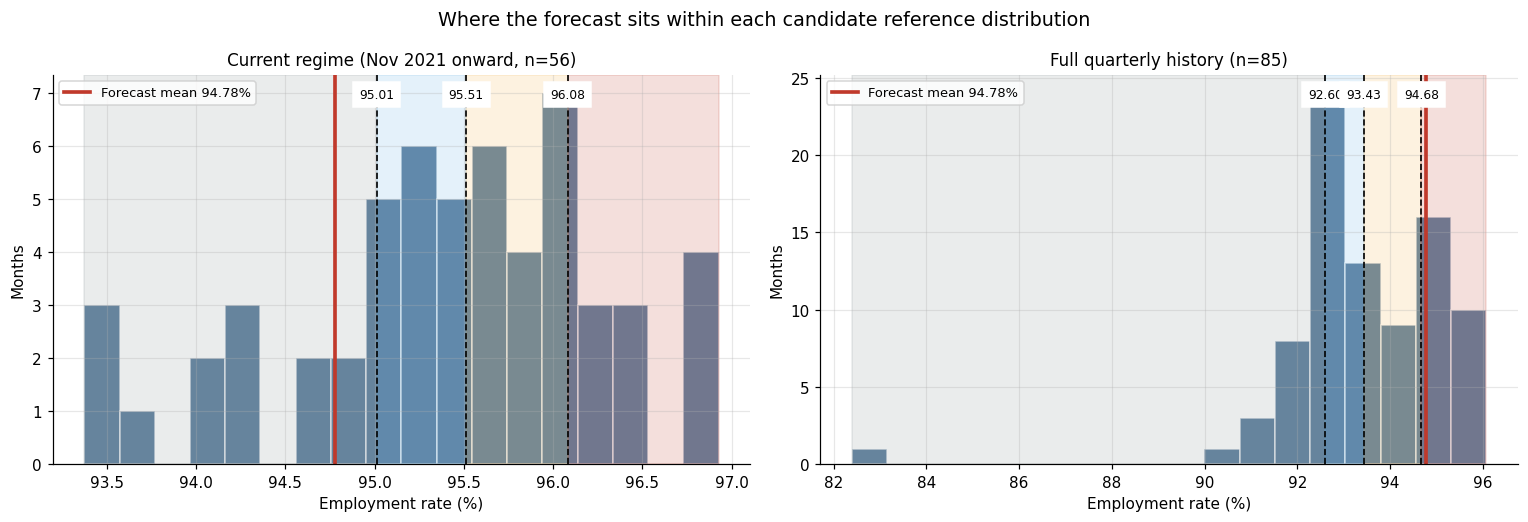

Forecast mean 94.778% classified against:
  Current regime : Subdued
  Full history   : Elevated
  The two references disagree : True


In [470]:
fig, axes = plt.subplots(1, 2, figsize=(14, 4.8))
band_colours = ["#7f8c8d", "#5dade2", "#f5b041", "#c0392b"]

for ax, (series, edges, title) in zip(axes, [
        (REFERENCE, EDGES_CURRENT,
         f"Current regime ({REFERENCE.index.min():%b %Y} onward, n={len(REFERENCE)})"),
        (LONG_REFERENCE, EDGES_LONG,
         f"Full quarterly history (n={len(LONG_REFERENCE)})")]):
    ax.hist(series, bins=18, color="#1f4e79", alpha=0.7, edgecolor="white")
    for i in range(4):
        lo = max(edges[i], series.min()); hi = min(edges[i + 1], series.max())
        ax.axvspan(lo, hi, color=band_colours[i], alpha=0.16)
    for e in edges[1:4]:
        ax.axvline(e, color="#000000", ls="--", lw=1.1)
        ax.annotate(f"{e:.2f}", xy=(e, ax.get_ylim()[1] * 0.94), fontsize=8,
                    ha="center", backgroundcolor="white")
    ax.axvline(FC_MEAN, color="#c0392b", lw=2.4,
               label=f"Forecast mean {FC_MEAN:.2f}%")
    ax.set_title(title, fontsize=11)
    ax.set_xlabel("Employment rate (%)"); ax.set_ylabel("Months")
    ax.legend(fontsize=8.5); ax.grid(alpha=0.3)

fig.suptitle("Where the forecast sits within each candidate reference distribution",
             fontsize=12.5)
plt.tight_layout(); plt.show()
save_fig(fig, "historical_reference_distribution.png")

def classify(value, edges):
    return EMPLOYMENT_CONDITION_LABELS[int(np.searchsorted(edges[1:4], value, side="right"))]

REF_DISAGREE = classify(FC_MEAN, EDGES_CURRENT) != classify(FC_MEAN, EDGES_LONG)
print(f"Forecast mean {FC_MEAN:.3f}% classified against:")
print(f"  Current regime : {classify(FC_MEAN, EDGES_CURRENT)}")
print(f"  Full history   : {classify(FC_MEAN, EDGES_LONG)}")
print(f"  The two references disagree : {REF_DISAGREE}")

#### Findings:

Against the **current regime**, the forecast mean of **94.78%** falls in the lowest quartile
(**Subdued**). Against the **full history**, the same value falls in the highest quartile
(**Elevated**). Current-regime quartiles sit near 95.01%–96.08%; full-history quartiles sit near
92.60%–94.68%. The median gap is about **2.1 percentage points**, consistent with the level shift in
Section 9.1.

#### Interpretation:

Long history says “high by past standards.” Recent norms say “soft within the post-recovery band.”
For clinic planning, recent norms are the more useful comparator: a threshold that almost every
recent outcome clears does not distinguish month to month.

#### What this changes:

**Current regime** is the operative reference for Employment Condition labels. Full-history labels
are keeped beside them for context. Neither label is a PEME-demand forecast.


---

# 23. Employment Condition and Operational Attention Signal

#### Objective:

Convert each forecast month into two separate readings:

1. **Employment Condition** — where the forecast sits in the current-regime distribution
 (`Subdued`, `Below Normal`, `Above Normal`, `Elevated`).
2. **Operational Attention** — the corresponding planning cue
 (`LOW`, `NORMAL`, `ELEVATED`, `HIGH PRECAUTION`).

#### Why separate the two:

Employment Condition is a statistical description of the Employment Rate. Operational Attention is
the clinic-facing cue that follows from that description. Keeping them separate avoids treating the
Employment Rate as if it were PEME volume.

```
Forecasted Employment Rate
 -> Employment Condition
 -> Operational Attention Signal
 -> Management reviews actual clinic conditions
 -> Management decides whether action is required
```

#### Why categorical bands:

Point forecasts are more precise than the validation error supports. Band labels stay useful even
when the second decimal place does not.

#### Confidence:

The model’s analytic 95% intervals are wider than observed out-of-sample error (Section 18). Band
confidence therefore uses the **empirical** error range. If that range stays inside one Employment
Condition band, the label is **Confident**; if it crosses a boundary, it is **Uncertain**.

Neither reading forecasts PEME demand, hiring volume, inventory need, or staffing levels.


In [471]:
# Empirical error range at each horizon, from the genuine out-of-sample errors of Section 15.
emp_range = emp[["Empirical_P05", "Empirical_P95"]].reindex(range(1, FORECAST_H + 1))

signal = final_forecast[final_forecast["In_Reported_Horizon"] == "Yes"].copy()
signal["Empirical_Lower"] = (signal["Forecast"].to_numpy()
                             + emp_range["Empirical_P05"].to_numpy())
signal["Empirical_Upper"] = (signal["Forecast"].to_numpy()
                             + emp_range["Empirical_P95"].to_numpy())

signal["Employment_Condition"] = [classify(v, EDGES_CURRENT) for v in signal["Forecast"]]
signal["Condition_At_Empirical_Lower"] = [classify(v, EDGES_CURRENT)
                                          for v in signal["Empirical_Lower"]]
signal["Condition_At_Empirical_Upper"] = [classify(v, EDGES_CURRENT)
                                          for v in signal["Empirical_Upper"]]
signal["Employment_Condition_Long_History"] = [classify(v, EDGES_LONG)
                                               for v in signal["Forecast"]]

signal["Confidence"] = np.where(
    signal["Condition_At_Empirical_Lower"] == signal["Condition_At_Empirical_Upper"],
    "Confident", "Uncertain")
signal["Conditions_Spanned"] = [
    f"{lo} to {hi}" if lo != hi else lo
    for lo, hi in zip(signal["Condition_At_Empirical_Lower"],
                      signal["Condition_At_Empirical_Upper"])]
signal["Operational_Attention"] = signal["Employment_Condition"].map(OPERATIONAL_ATTENTION)
signal["Vs_Last_Observed"] = np.where(
    signal["Change_From_Last_Observed"] > 0.15, "Higher",
    np.where(signal["Change_From_Last_Observed"] < -0.15, "Lower", "Similar"))

employment_activity_signal = (
    signal.reset_index()
          .assign(Period=lambda d: d["Period"].dt.strftime("%b %Y"))
          [["Period", "Forecast", "Lower", "Upper",
            "Employment_Condition", "Operational_Attention", "Confidence",
            "Conditions_Spanned", "Employment_Condition_Long_History", "Vs_Last_Observed"]]
          .rename(columns={"Lower": "Lower Bound", "Upper": "Upper Bound"})
          .round(3))
display(employment_activity_signal)
save_table(employment_activity_signal, "employment_activity_signal.csv")

n_conf = int((signal["Confidence"] == "Confident").sum())
DOMINANT_BAND = signal["Employment_Condition"].mode().iloc[0]
DOMINANT_ATTENTION = signal["Operational_Attention"].mode().iloc[0]
print(f"Signal horizon      : {FC_START:%b %Y} - {FC_END:%b %Y} ({FORECAST_H} months)")
print(f"Dominant Employment Condition : {DOMINANT_BAND}  "
      f"({int((signal['Employment_Condition'] == DOMINANT_BAND).sum())} of {FORECAST_H} months)")
print(f"Dominant Operational Attention : {DOMINANT_ATTENTION}")
print(f"Confident month assignments : {n_conf} of {FORECAST_H}")
print(f"Condition distribution : "
      f"{', '.join(f'{k} x{v}' for k, v in signal['Employment_Condition'].value_counts().items())}")


,Period,Forecast,Lower Bound,Upper Bound,Employment_Condition,Operational_Attention,Confidence,Conditions_Spanned,Employment_Condition_Long_History,Vs_Last_Observed
0,Jul 2026,94.2640,93.2150,95.3130,Subdued,LOW,Confident,Subdued,Above Normal,Lower
1,Aug 2026,95.1050,93.9420,96.2680,Below Normal,NORMAL,Uncertain,Subdued to Below Normal,Elevated,Similar
2,Sep 2026,95.1680,93.9020,96.4350,Below Normal,NORMAL,Uncertain,Subdued to Below Normal,Elevated,Similar
3,Oct 2026,94.4770,93.1150,95.8390,Subdued,LOW,Confident,Subdued,Above Normal,Lower
4,Nov 2026,94.8280,93.3760,96.2800,Subdued,LOW,Confident,Subdued,Elevated,Lower
5,Dec 2026,94.8280,93.2920,96.3640,Subdued,LOW,Confident,Subdued,Elevated,Lower


Signal horizon      : Jul 2026 - Dec 2026 (6 months)
Dominant Employment Condition : Subdued  (4 of 6 months)
Dominant Operational Attention : LOW
Confident month assignments : 4 of 6
Condition distribution : Subdued x4, Below Normal x2


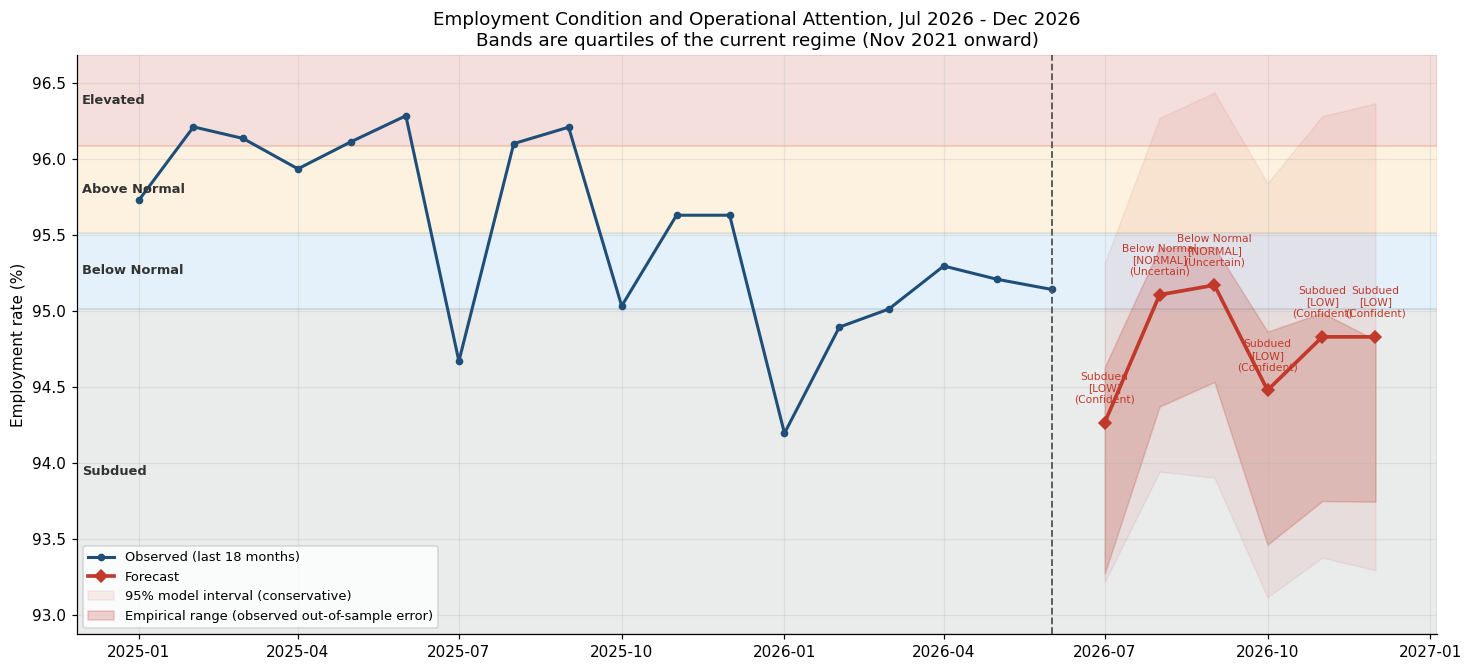

In [472]:
fig, ax = plt.subplots(figsize=(13.5, 6.2))

lo_lim = min(signal["Empirical_Lower"].min(), series_b.iloc[-18:].min()) - 0.4
hi_lim = max(signal["Empirical_Upper"].max(), series_b.iloc[-18:].max()) + 0.4
for i in range(4):
    lo, hi = max(EDGES_CURRENT[i], lo_lim), min(EDGES_CURRENT[i + 1], hi_lim)
    if hi > lo:
        ax.axhspan(lo, hi, color=band_colours[i], alpha=0.16)
        ax.annotate(EMPLOYMENT_CONDITION_LABELS[i],
                    xy=(0.004, (lo + hi) / 2), xycoords=("axes fraction", "data"),
                    fontsize=8.5, va="center", color="#333333", weight="bold")

recent = series_b.iloc[-18:]
ax.plot(recent.index, recent.values, color="#1f4e79", lw=2, marker="o", ms=4,
        label="Observed (last 18 months)")
ax.plot(signal.index, signal["Forecast"], color="#c0392b", lw=2.4, marker="D", ms=6,
        label="Forecast")
ax.fill_between(signal.index, signal["Lower"], signal["Upper"],
                color="#c0392b", alpha=0.08,
                label="95% model interval (conservative)")
ax.fill_between(signal.index, signal["Empirical_Lower"], signal["Empirical_Upper"],
                color="#c0392b", alpha=0.22,
                label="Empirical range (observed out-of-sample error)")

for d, r in signal.iterrows():
    ax.annotate(f"{r['Employment_Condition']}\n[{r['Operational_Attention']}]\n({r['Confidence']})",
                xy=(d, r["Forecast"]),
                xytext=(0, 13), textcoords="offset points", ha="center", fontsize=7,
                color="#c0392b")

ax.axvline(LAST_OBS_DATE, color="#555555", ls="--", lw=1.2)
ax.set_ylim(lo_lim, hi_lim)
ax.set_title(f"Employment Condition and Operational Attention, "
             f"{FC_START:%b %Y} - {FC_END:%b %Y}\n"
             f"Bands are quartiles of the current regime "
             f"({REFERENCE.index.min():%b %Y} onward)", fontsize=12)
ax.set_ylabel("Employment rate (%)"); ax.set_xlabel("")
ax.legend(fontsize=8.5, loc="lower left"); ax.grid(alpha=0.25)
plt.tight_layout(); plt.show()
save_fig(fig, "employment_activity_signal.png")


#### Findings:

July–December 2026 fall in the lower half of the current-regime distribution: mostly **Subdued**
(Operational Attention **LOW**), with August–September at **Below Normal** (**NORMAL**). Four of six
months are Confident; August and September are Uncertain because their empirical ranges cross a band
boundary.

Relative to long history the same months still look firm (`Above Normal` / `Elevated`). Relative to
post-recovery norms they look soft. Seasonality remains visible: November–December sit above October.

#### Interpretation:

The signal points to **stable to modestly softer employment conditions** within the current regime —
not a collapse, and not a surge. Operational Attention is therefore **LOW** to **NORMAL**.
That is a cue to review clinic conditions, not a claim about PEME volume.

#### What this changes:

Use **Employment Condition** to describe the forecast statistically, and **Operational Attention**
as the planning cue. Decisions still depend on the clinic’s own data.


---

# 24. Business Interpretation and Recommendations

#### Objective:

Explain what the Employment Condition / Operational Attention signal supports for clinic planning,
and what it does not support.

#### Rationale:

The dataset is a national Employment Rate series. It contains no clinic, patient, examination, or
transaction data. Recommendations therefore concern **attention**, not automatic operational actions.


In [473]:
recommendations = pd.DataFrame([
    dict(
        Recommendation="Treat the horizon as continuation of current employment conditions, "
                       "not as a regime change",
        Evidence=f"Forecast mean {FC_MEAN:.2f}% vs last observed {LAST_OBS:.2f}% "
                 f"({FC_CHANGE:+.2f} pp); months remain inside the post-"
                 f"{REFERENCE.index.min():%b %Y} range",
        Suggested_Action="Keep current operating posture as the baseline while monitoring "
                         "clinic-level indicators",
        Not_Supported="Does not forecast PEME demand, clinic volume, or revenue"),
    dict(
        Recommendation="Expect the usual November–December seasonal firming in employment",
        Evidence="Section 10.4.2: November +0.51 pp and December +0.50 pp above trend; "
                 "permutation p < 0.001; pattern appears in the forecast",
        Suggested_Action="Schedule an internal readiness review before Q4 if clinic history "
                         "shows seasonal PEME peaks",
        Not_Supported="Does not measure the lead time from employment changes to examinations"),
    dict(
        Recommendation="Read Employment Condition and Operational Attention as bands, not as "
                       "exact percentages",
        Evidence=f"MAE ~{float(by_h.loc[FORECAST_H - 1, 'MAE']):.2f} pp at {FORECAST_H} months; "
                 f"empirical error range about 1.0-1.4 pp",
        Suggested_Action="Use Employment_Condition, Operational_Attention, and Confidence; "
                         "ignore second-decimal precision",
        Not_Supported="Does not support exact staffing counts or inventory targets"),
    dict(
        Recommendation="Treat Uncertain months as a range of conditions",
        Evidence=f"{int((signal['Confidence'] == 'Uncertain').sum())} of {FORECAST_H} months "
                 f"cross an Employment Condition boundary under the empirical error range",
        Suggested_Action="For Uncertain months, review against both neighbouring conditions "
                         "rather than one label alone",
        Not_Supported="Does not justify an action that would reverse under the adjacent band"),
    dict(
        Recommendation="Refresh when new PSA monthly releases arrive",
        Evidence=f"Error grows from {float(by_h.loc[0, 'MAE']):.2f} pp at 1 month to "
                 f"{float(by_h.loc[RO_H - 1, 'MAE']):.2f} pp at 12; reference uses "
                 f"{len(REFERENCE)} post-recovery months",
        Suggested_Action="Re-run the notebook after each new monthly release",
        Not_Supported="Thresholds are not permanent if the employment regime shifts again"),
    dict(
        Recommendation="Do not use this forecast as a shock early-warning system",
        Evidence="April 2020 at 82.395% (modified z = -5.92) was outside prior behaviour",
        Suggested_Action="Keep contingency planning separate from this univariate forecast",
        Not_Supported="Cannot anticipate disruptions originating outside the series history"),
])
display(recommendations)
save_table(recommendations, "business_recommendations.csv")


,Recommendation,Evidence,Suggested_Action,Not_Supported
0,Treat the horizon as continuation of current e...,Forecast mean 94.78% vs last observed 95.14% (...,Keep current operating posture as the baseline...,"Does not forecast PEME demand, clinic volume, ..."
1,Expect the usual November–December seasonal fi...,Section 10.4.2: November +0.51 pp and December...,Schedule an internal readiness review before Q...,Does not measure the lead time from employment...
2,Read Employment Condition and Operational Atte...,MAE ~0.44 pp at 6 months; empirical error rang...,"Use Employment_Condition, Operational_Attentio...",Does not support exact staffing counts or inve...
3,Treat Uncertain months as a range of conditions,2 of 6 months cross an Employment Condition bo...,"For Uncertain months, review against both neig...",Does not justify an action that would reverse ...
4,Refresh when new PSA monthly releases arrive,Error grows from 0.31 pp at 1 month to 0.89 pp...,Re-run the notebook after each new monthly rel...,Thresholds are not permanent if the employment...
5,Do not use this forecast as a shock early-warn...,April 2020 at 82.395% (modified z = -5.92) was...,Keep contingency planning separate from this u...,Cannot anticipate disruptions originating outs...


#### Findings:

The executed evidence supports six recommendations. All concern **when to pay attention**, not
how many examinations to schedule.

#### Interpretation:

Employment Condition describes the statistical position of the Employment Rate. Operational
Attention translates that into a planning cue. Neither measures PEME demand. Clinic action still
depends on internal volume, capacity, and client mix.


---

# 25. Limitations

#### Objective:

Record the constraints that bound the conclusions of this study.

#### Rationale:

Limitations are recorded here as a necessary part of the analysis rather than as a
formality. Each entry below arises from a specific executed result, states its practical consequence,
and — where one exists — states the mitigation applied. Several were identified during the analysis
and shaped the design; they are not retrospective qualifications.


In [474]:
limitations = pd.DataFrame([
    dict(Limitation="The dataset contains no clinic-level information",
         Origin="Section 2: 14 columns, all national labour-force indicators",
         Consequence="PEME demand, patient volume, revenue and staffing cannot be forecast. "
                     "The link from national employment to clinic activity is assumed, not "
                     "measured",
         Mitigation="Every conclusion is framed as an external planning signal; the "
                    "Not_Supported column of Section 24 states the boundary for each "
                    "recommendation"),
    dict(Limitation="Observation frequency changes partway through the record",
         Origin="Section 4.3: quarterly to Oct 2020, monthly from Jan 2021",
         Consequence="The 129 observations cannot be modelled as one sequence; only 66 "
                     "equally spaced monthly observations are available for forecasting",
         Mitigation="Three separate views with defined purposes (Section 5); interpolation "
                    "and quarterly averaging both rejected with stated reasons"),
    dict(Limitation="The monthly series is short",
         Origin="Section 4.3: n = 66, approximately 5.5 annual cycles",
         Consequence="Model complexity is constrained; seasonal specifications estimate 12 "
                     "factors from ~5 observations per month, and Holt-Winters ranked 7th of "
                     "8 as a direct result",
         Mitigation="Candidate set restricted to low-order specifications; AICc used for order "
                    "selection; seasonal strength calibrated by permutation rather than by "
                    "a rule of thumb"),
    dict(Limitation="The frequency change coincides with the COVID recovery",
         Origin="Section 5: monthly reporting begins Jan 2021, within the recovery",
         Consequence="The only continuously monthly data available is recovery-affected, and "
                     "the two effects cannot be fully separated",
         Mitigation="Parallel trimmed window (View B-T) with a cut-point fixed in advance; "
                     "Section 21 shows the two windows differ by 0.017 pp, far below forecast "
                     "uncertainty"),
    dict(Limitation="The quarterly robustness check is not independent",
         Origin="Section 4.4: 22 of 85 View C observations fall in the monthly era",
         Consequence="Agreement between the monthly and quarterly forecasts is partly "
                     "structural and is weaker evidence than agreement between separate samples",
         Mitigation="Stated explicitly in Section 20; the check is reported as establishing "
                    "absence of contradiction, not independent confirmation"),
    dict(Limitation="The model is univariate",
         Origin="Sections 13-16: all candidates use only the history of the employment rate",
         Consequence="Inflation, GDP, policy changes, sectoral shifts and external shocks are "
                     "not represented; turning points driven by such factors cannot be "
                     "anticipated",
         Mitigation="Forecast presented with uncertainty intervals and explicitly conditioned "
                    "on absence of major disruption; the Section 14 error analysis shows the "
                    "model did not anticipate the late-2025 easing"),
    dict(Limitation="Forecast intervals are conservative rather than well calibrated",
         Origin="Section 18: model interval width is 1.5x to 2.9x the observed error spread",
         Consequence="The model's own intervals span several activity bands and cannot "
                     "discriminate between them",
         Mitigation="An empirical range built from genuine out-of-sample errors is reported "
                    "alongside and is used for band confidence; both are shown so the "
                    "difference is visible"),
    dict(Limitation="The reference distribution covers no downturn",
         Origin=f"Section 22: current-regime reference is {len(series_b_trim)} observations "
                f"from {series_b_trim.index.min():%b %Y}, entirely post-recovery",
         Consequence="A genuine deterioration would fall below the whole reference range and "
                     "be reported as Subdued without any indication of severity",
         Mitigation="The full-history classification is reported in every signal row as a "
                    "second reference point"),
    dict(Limitation="The final six months of the file are unpublished",
         Origin="Section 3.5: Jul-Dec 2026 are trailing empty months",
         Consequence="The forecast horizon cannot be verified against actual outcomes within "
                     "this study",
         Mitigation="Accuracy is estimated instead from a 12-month holdout and 13 rolling "
                    "origins, all evaluated against observed data"),
    dict(Limitation="Period boundaries are conventions, not estimated breakpoints",
         Origin="Section 7.1: pre-COVID, pandemic and post-recovery boundaries set by known "
                "events",
         Consequence="Period comparisons are descriptive; they do not establish statistically "
                     "distinct regimes",
         Mitigation="Stated wherever such comparisons are made; the level shift was "
                    "independently verified on equally spaced data in Section 9.1"),
])
display(limitations)
save_table(limitations, "limitations.csv")
print(f"{len(limitations)} limitations recorded, each traced to a specific executed result.")

,Limitation,Origin,Consequence,Mitigation
0,The dataset contains no clinic-level information,"Section 2: 14 columns, all national labour-for...","PEME demand, patient volume, revenue and staff...",Every conclusion is framed as an external plan...
1,Observation frequency changes partway through ...,"Section 4.3: quarterly to Oct 2020, monthly fr...",The 129 observations cannot be modelled as one...,Three separate views with defined purposes (Se...
2,The monthly series is short,"Section 4.3: n = 66, approximately 5.5 annual ...",Model complexity is constrained; seasonal spec...,Candidate set restricted to low-order specific...
3,The frequency change coincides with the COVID ...,"Section 5: monthly reporting begins Jan 2021, ...",The only continuously monthly data available i...,Parallel trimmed window (View B-T) with a cut-...
4,The quarterly robustness check is not independent,Section 4.4: 22 of 85 View C observations fall...,Agreement between the monthly and quarterly fo...,Stated explicitly in Section 20; the check is ...
5,The model is univariate,Sections 13-16: all candidates use only the hi...,"Inflation, GDP, policy changes, sectoral shift...",Forecast presented with uncertainty intervals ...
6,Forecast intervals are conservative rather tha...,Section 18: model interval width is 1.5x to 2....,The model's own intervals span several activit...,An empirical range built from genuine out-of-s...
7,The reference distribution covers no downturn,Section 22: current-regime reference is 56 obs...,A genuine deterioration would fall below the w...,The full-history classification is reported in...
8,The final six months of the file are unpublished,Section 3.5: Jul-Dec 2026 are trailing empty m...,The forecast horizon cannot be verified agains...,Accuracy is estimated instead from a 12-month ...
9,"Period boundaries are conventions, not estimat...","Section 7.1: pre-COVID, pandemic and post-reco...",Period comparisons are descriptive; they do no...,Stated wherever such comparisons are made; the...


10 limitations recorded, each traced to a specific executed result.


#### Interpretation:

The limitations divide into three categories, and the distinction matters for how
they should be read.

**Constraints of the data**, which no analytical decision could remove. The absence of clinic-level
information, the change in observation frequency, the shortness of the monthly series and the
confounding of that change with the pandemic recovery are all properties of the source. The analysis
was designed around them; it could not resolve them.

**Constraints of the method**, which were chosen and could have been chosen differently. The
univariate specification is the principal example. Incorporating external predictors would in
principle allow turning points to be anticipated, but would require those predictors to be forecast
in turn, and would add substantial parameter burden to a 66-observation series. The choice is
defensible on the evidence available and is stated as a choice.

**Constraints on interpretation**, which are the responsibility of the reader. The signal is a
national indicator translated into a band; it is not a demand forecast. This limitation cannot be
addressed by better modelling, only by accurate statement.

**The most important limitation** is the first. Everything in this study concerns Philippine national
employment. The relevance of that quantity to any particular clinic is an assumption made explicit at
the outset, tested nowhere in this analysis, and testable only against data the clinic itself holds.


---

# 26. Ethics, Human Oversight and Disclosure of AI Use

#### Objective:

Summarize the ethical considerations arising from this analysis, the role of human
judgement in its production, and the extent of AI assistance used.

#### Rationale:

A forecast that informs operational planning carries responsibilities beyond
statistical accuracy. The considerations below concern the sourcing of the data, the potential for
the output to be misused, and transparency regarding how the work was produced.


In [475]:
ethics = pd.DataFrame([
    dict(Consideration="Data provenance and licensing",
         Assessment="The dataset is official aggregate statistics published by the Philippine "
                    "Statistics Authority for public use. No proprietary or restricted source "
                    "is involved",
         Action_Taken="Source, coverage and structure documented in Section 2; the raw file is "
                      "inspected and reported before parsing"),
    dict(Consideration="Personal data and privacy",
         Assessment="No personal, identifiable or individual-level data is present. All values "
                    "are national aggregate percentages",
         Action_Taken="No anonymisation or access control is required; confirmed by the "
                      "column inventory in Section 3.1"),
    dict(Consideration="Risk of over-interpretation",
         Assessment="The principal ethical risk in this study. A national indicator presented "
                    "as a business signal invites inference about clinic demand that the data "
                    "cannot support",
         Action_Taken="Scope stated in Section 1; a Not_Supported statement attached to every "
                      "recommendation in Section 24; the signal is categorical with an "
                      "explicit confidence qualifier"),
    dict(Consideration="Representation of uncertainty",
         Assessment="Presenting a point forecast without a range would imply precision the "
                    "validation evidence does not support",
         Action_Taken="Two ranges reported: the conservative model interval and an empirical "
                      "range from genuine out-of-sample errors. Section 18 states plainly that "
                      "the model intervals are miscalibrated, and in which direction"),
    dict(Consideration="Selective reporting",
         Assessment="Reporting only favourable results would misrepresent the reliability of "
                    "the analysis",
         Action_Taken="Adverse and inconvenient results retained throughout: the "
                      "non-significant Kruskal-Wallis test, the inconclusive stationarity "
                      "result on the trimmed window, the interval miscalibration, the "
                      "directional bias in the holdout, and the fact that a simple arithmetic "
                      "benchmark outperformed the selected model under one validation scheme"),
    dict(Consideration="Employment as a sensitive subject",
         Assessment="Employment conditions bear directly on livelihoods. Forecasts of labour "
                    "market weakness could be used to justify pre-emptive reductions in "
                    "service capacity",
         Action_Taken="Recommendations are confined to reviewing readiness and are explicitly "
                      "framed as grounds for attention rather than instructions to act"),
    dict(Consideration="Human oversight",
         Assessment="No decision in this analysis is delegated to an automated procedure",
         Action_Taken="Window selection, model selection, threshold construction and the "
                      "reference-period decision were each made against stated criteria fixed "
                      "in advance, with reasoning recorded at the point of decision"),
    dict(Consideration="Reproducibility and auditability",
         Assessment="Conclusions that cannot be reproduced cannot be verified or challenged",
         Action_Taken="The notebook runs end to end from a clean kernel; every exported value "
                      "is written from the object displayed in the notebook; random procedures "
                      "use a fixed seed"),
])
display(ethics)
save_table(ethics, "ethics_and_oversight.csv")

,Consideration,Assessment,Action_Taken
0,Data provenance and licensing,The dataset is official aggregate statistics p...,"Source, coverage and structure documented in S..."
1,Personal data and privacy,"No personal, identifiable or individual-level ...",No anonymisation or access control is required...
2,Risk of over-interpretation,The principal ethical risk in this study. A na...,Scope stated in Section 1; a Not_Supported sta...
3,Representation of uncertainty,Presenting a point forecast without a range wo...,Two ranges reported: the conservative model in...
4,Selective reporting,Reporting only favourable results would misrep...,Adverse and inconvenient results retained thro...
5,Employment as a sensitive subject,Employment conditions bear directly on livelih...,Recommendations are confined to reviewing read...
6,Human oversight,No decision in this analysis is delegated to a...,"Window selection, model selection, threshold c..."
7,Reproducibility and auditability,Conclusions that cannot be reproduced cannot b...,The notebook runs end to end from a clean kern...


## 26.1 Disclosure of AI assistance

#### Objective:

Describe the extent and nature of AI assistance used in producing this work.

#### Rationale:

Transparency regarding AI assistance is a requirement of academic integrity. The
disclosure below distinguishes tasks in which AI assistance was used from analytical judgements that
were not delegated.


In [476]:
ai_disclosure = pd.DataFrame([
    dict(Area="Code implementation",
         AI_Assistance="Used",
         Detail="Assistance was used in drafting Python for data preparation, diagnostic "
                "testing, model fitting, validation loops and figure construction",
         Human_Responsibility="All code was reviewed and executed; every reported value is "
                              "produced by executing this notebook, and no output is "
                              "transcribed by hand"),
    dict(Area="Analytical design",
         AI_Assistance="Used as support",
         Detail="Assistance was used in structuring the three-view strategy, the validation "
                "design and the diagnostic sequence",
         Human_Responsibility="Design decisions were adopted only where justified by evidence "
                              "reported in this notebook; the reasoning for each is recorded "
                              "at the point of decision"),
    dict(Area="Statistical decisions",
         AI_Assistance="Not delegated",
         Detail="The choice of modelling window, the differencing order, the admission of "
                "seasonal candidates, the final model and the reference distribution were "
                "each determined by criteria fixed before the relevant result was known",
         Human_Responsibility="Each decision is traceable to a specific executed test, and the "
                              "criteria are stated in advance in Sections 9.2, 11 and 22"),
    dict(Area="Interpretation of results",
         AI_Assistance="Used for drafting",
         Detail="Assistance was used in drafting the written interpretation and explanation",
         Human_Responsibility="Every numerical claim in the narrative corresponds to an output "
                              "displayed in the cell above it; interpretations were checked "
                              "against the executed results"),
    dict(Area="Data and results",
         AI_Assistance="Not used",
         Detail="No data value, statistic, p-value, forecast or error metric was generated, "
                "estimated or adjusted by AI",
         Human_Responsibility="All figures derive from the PSA source file through executed "
                              "code; the notebook can be re-run to verify any value"),
])
display(ai_disclosure)
save_table(ai_disclosure, "ai_use_disclosure.csv")

print("Declaration: AI assistance was used for code drafting, structural organisation and")
print("written exposition. It was not used to generate data, produce results, or substitute")
print("for the analytical judgements recorded in this notebook. Every reported value is")
print("reproducible by executing this notebook against the source dataset.")

,Area,AI_Assistance,Detail,Human_Responsibility
0,Code implementation,Used,Assistance was used in drafting Python for dat...,All code was reviewed and executed; every repo...
1,Analytical design,Used as support,Assistance was used in structuring the three-v...,Design decisions were adopted only where justi...
2,Statistical decisions,Not delegated,"The choice of modelling window, the differenci...",Each decision is traceable to a specific execu...
3,Interpretation of results,Used for drafting,Assistance was used in drafting the written in...,Every numerical claim in the narrative corresp...
4,Data and results,Not used,"No data value, statistic, p-value, forecast or...",All figures derive from the PSA source file th...


Declaration: AI assistance was used for code drafting, structural organisation and
written exposition. It was not used to generate data, produce results, or substitute
for the analytical judgements recorded in this notebook. Every reported value is
reproducible by executing this notebook against the source dataset.


---

# 27. Methodological Decision Record

#### Objective:

Summarize the main methodological choices in one table and keep a lightweight copy under
`outputs/documentation/`.

#### Why this is short:

The notebook is the analysis. External documentation here is only a compact decision log for audit
and reuse — not a second write-up of the project.


In [477]:
decisions = pd.DataFrame([
    dict(Decision="Target variable: Employment Rate (both sexes)",
         Evidence=f"Complete for all {len(observed)} observed months; Employment + Unemployment "
                  f"= 100 with maximum deviation {max_deviation:.6f}",
         Rationale="Most directly connected to national employment conditions relevant "
                   "to clinics offering PEME services",
         Rejected_Alternative="Unemployment Rate (exact arithmetic complement, no additional "
                              "information); Participation Rate (measures labour-market entry, "
                              "not employment)"),
    dict(Decision="Exclude the 22 annual aggregate rows",
         Evidence="Section 3.2: 22 rows labelled 'Annual' alongside 264 calendar-month rows",
         Rationale="An annual summary is not a survey observation; retaining these rows would "
                   "insert artificial data points between December and January of each year",
         Rejected_Alternative="Retaining them as observations, which would corrupt all temporal "
                              "computation"),
    dict(Decision="Do not impute the 126 interior missing months",
         Evidence="Section 3.5: absences are identical across all 12 indicators, indicating "
                  "months in which the survey was not conducted",
         Rationale="These are not failed measurements but months without a survey; imputation "
                   "would fabricate over a decade of observations and corrupt the "
                   "autocorrelation and variance evidence used for model selection",
         Rejected_Alternative="Linear or seasonal interpolation to a continuous monthly series"),
    dict(Decision="Retain the April 2020 outlier",
         Evidence="Section 3.8: 82.395%, modified z-score -5.92, the only flagged observation",
         Rationale="A genuine survey result recording the COVID-19 lockdown contraction; "
                   "removing it would represent the series as far more stable than it is and "
                   "understate genuine forecast risk",
         Rejected_Alternative="Deletion or winsorisation of the pandemic trough"),
    dict(Decision="Build the quarterly long-history series by selection, not averaging",
         Evidence="Section 4.4: Jan/Apr/Jul/Oct occur 21-22 times each; selecting them yields "
                  "85 observations with zero cadence breaks",
         Rationale="Averaging monthly observations into quarterly means would introduce an "
                   "artificial reduction in variance exactly at the frequency transition, "
                   "creating a processing artefact that could be mistaken for an economic change",
         Rejected_Alternative="Three-month averaging of the monthly era"),
    dict(Decision="Fix the recovery cut-point by a pre-specified rule",
         Evidence=f"Section 9.2: pre-COVID reference {PRE_COVID_REFERENCE:.4f}%; 10 months below "
                  f"it, forming a single contiguous leading block ending Oct 2021",
         Rationale="The rule uses only pre-pandemic information and was fixed before any model "
                   "was estimated, so the trimmed window cannot have been chosen to suit a "
                   "result",
         Rejected_Alternative="Selecting the cut-point by comparing forecast accuracy across "
                              "candidate start dates"),
    dict(Decision="Calibrate seasonal strength by permutation rather than by threshold",
         Evidence=f"Section 10.4.1: observed 0.709 against a null mean of "
                  f"{float(perm_b['Null_Mean_Strength']):.3f} and 95th percentile "
                  f"{float(perm_b['Null_95th_Pct']):.3f}; permutation p < 0.001",
         Rationale="The 0.64 convention was not established for 5-year samples and falls inside "
                   "the null distribution here; Kruskal-Wallis (p = 0.059) has minimal power at "
                   "~5 observations per calendar month",
         Rejected_Alternative="Accepting the 0.64 rule of thumb, or accepting the "
                              "non-significant Kruskal-Wallis result, which imply opposite "
                              "modelling decisions"),
    dict(Decision=f"Differencing order d = 1 for ARIMA-family models",
         Evidence="Section 10.2: ADF and KPSS agree on non-stationarity in levels "
                  "(p = 0.215 / 0.010) and on stationarity after first differencing "
                  "(p = 0.021 / 0.100)",
         Rationale="Determined by evidence from two tests with opposing nulls, not by "
                   "convention or by tuning",
         Rejected_Alternative="Modelling levels directly, or applying seasonal differencing, "
                              "which would consume 12 observations from a 54-month training set"),
    dict(Decision=f"Final model: {FINAL_MODEL}",
         Evidence=f"Holdout MAE {float(scorecard.loc[scorecard['Model'] == FINAL_MODEL, 'Holdout_MAE'].iloc[0]):.4f} pp "
                  f"(rank 1 of 8); rolling-origin MAE "
                  f"{float(scorecard.loc[scorecard['Model'] == FINAL_MODEL, 'Rolling_MAE'].iloc[0]):.4f} pp "
                  f"(rank 2 of 8); Spearman agreement between schemes 0.976",
         Rationale="Lowest rolling-origin error among models that beat the naive benchmark and "
                   "supply uncertainty intervals; all residual diagnostics passed",
         Rejected_Alternative="Seasonal naive, marginally better on rolling origin (by 0.042 pp) "
                              "but supplying no uncertainty interval; Holt-Winters, "
                              "over-parameterised for 54 training observations"),
    dict(Decision="Report the forecast on the full monthly window (View B)",
         Evidence=f"Section 21: forecasts from the two windows differ by at most "
                  f"{MAX_WINDOW_GAP:.3f} pp, against a one-month interval half-width of "
                  f"{ONE_STEP_WIDTH / 2:.3f} pp",
         Rationale="Uses all 66 available monthly observations, and the sensitivity analysis "
                   "shows the alternative window would not change any operational conclusion",
         Rejected_Alternative="View B-T, cleaner in composition but 10 observations shorter and "
                              "statistically inconclusive when differenced"),
    dict(Decision="Use the current regime as the Employment Condition reference",
         Evidence=f"Section 22: current-regime median {REFERENCE.median():.2f}% against "
                  f"full-history median {LONG_REFERENCE.median():.2f}%, consistent with the "
                  f"1.91 pp level shift verified on equally spaced data in Section 9.1",
         Rationale="A reference spanning a superseded regime would classify nearly every "
                   "forecast into the same band and could not discriminate between the "
                   "conditions that actually vary",
         Rejected_Alternative="The full 2005-2026 distribution, retained and reported alongside "
                              "as secondary context rather than discarded"),
    dict(Decision="Use an empirical error range for Employment Condition confidence",
         Evidence="Section 18: model interval width is 1.5x to 2.9x the observed out-of-sample "
                  "error spread across all horizons",
         Rationale="The model's analytic intervals are conservative and span several activity "
                   "bands; a range built from errors the model genuinely incurred reflects "
                   "observed performance rather than an assumption of correct specification",
         Rejected_Alternative="Using the 95% model interval alone, which would render every "
                              "band assignment uncertain and the signal uninformative"),
])
display(decisions)
save_table(decisions, "methodology_decisions.csv")


,Decision,Evidence,Rationale,Rejected_Alternative
0,Target variable: Employment Rate (both sexes),Complete for all 129 observed months; Employme...,Most directly connected to national employment...,Unemployment Rate (exact arithmetic complement...
1,Exclude the 22 annual aggregate rows,Section 3.2: 22 rows labelled 'Annual' alongsi...,An annual summary is not a survey observation;...,"Retaining them as observations, which would co..."
2,Do not impute the 126 interior missing months,Section 3.5: absences are identical across all...,These are not failed measurements but months w...,Linear or seasonal interpolation to a continuo...
3,Retain the April 2020 outlier,"Section 3.8: 82.395%, modified z-score -5.92, ...",A genuine survey result recording the COVID-19...,Deletion or winsorisation of the pandemic trough
4,Build the quarterly long-history series by sel...,Section 4.4: Jan/Apr/Jul/Oct occur 21-22 times...,Averaging monthly observations into quarterly ...,Three-month averaging of the monthly era
5,Fix the recovery cut-point by a pre-specified ...,Section 9.2: pre-COVID reference 93.2786%; 10 ...,The rule uses only pre-pandemic information an...,Selecting the cut-point by comparing forecast ...
6,Calibrate seasonal strength by permutation rat...,Section 10.4.1: observed 0.709 against a null ...,The 0.64 convention was not established for 5-...,"Accepting the 0.64 rule of thumb, or accepting..."
7,Differencing order d = 1 for ARIMA-family models,Section 10.2: ADF and KPSS agree on non-statio...,Determined by evidence from two tests with opp...,"Modelling levels directly, or applying seasona..."
8,"Final model: SARIMA(0, 1, 1)(1, 0, 0, 12)",Holdout MAE 0.8311 pp (rank 1 of 8); rolling-o...,Lowest rolling-origin error among models that ...,"Seasonal naive, marginally better on rolling o..."
9,Report the forecast on the full monthly window...,Section 21: forecasts from the two windows dif...,"Uses all 66 available monthly observations, an...","View B-T, cleaner in composition but 10 observ..."


In [478]:
import platform
from datetime import datetime

RUN_STAMP = datetime.now().strftime("%Y-%m-%d %H:%M")

# Re-export registers so residual diagnostics from Sections 17-18 are included.
assumption_tests = pd.DataFrame(ASSUMPTION_TESTS)
descriptive_statistics = pd.DataFrame(DESCRIPTIVE_ROWS)
save_table(assumption_tests, "assumption_tests.csv")
save_table(descriptive_statistics, "descriptive_statistics.csv")

# Lightweight methodology note only (not a full secondary report).
lines = [
    "# Methodology Decision Record",
    "",
    f"Generated from `MBAN625_Employment_Forecasting.ipynb` on {RUN_STAMP}.",
    "The notebook is the full analysis. This file is a compact decision log only.",
    "",
]
for r in decisions.itertuples(index=False):
    lines += [
        f"## {r.Decision}",
        "",
        f"- **Evidence:** {r.Evidence}",
        f"- **Rationale:** {r.Rationale}",
        f"- **Rejected alternative:** {r.Rejected_Alternative}",
        "",
    ]
doc_path = DOCS_DIR / "methodology_decisions.md"
doc_path.write_text("\n".join(lines), encoding="utf-8")

# Keep documentation lightweight: remove older multi-file report drafts if present.
for stale in DOCS_DIR.glob("*.md"):
    if stale.name != "methodology_decisions.md":
        stale.unlink()

print(f"Assumption-test register : {len(assumption_tests)} formal tests recorded")
print(f"Descriptive register     : {len(descriptive_statistics)} scopes recorded")
print(f"Lightweight documentation: {doc_path.as_posix()}")


Assumption-test register : 20 formal tests recorded
Descriptive register     : 7 scopes recorded
Lightweight documentation: outputs/documentation/methodology_decisions.md


#### Findings:

The decision table summarizes the main choices and rejected alternatives. One lightweight markdown
file is written to `outputs/documentation/methodology_decisions.md`.

#### Interpretation:

The notebook remains the primary explanation. The external file is only a portable decision log.


---

# Overall Summary and Final Conclusion

This project forecasts the Philippine Employment Rate as an external planning signal for clinics offering Pre-Employment Medical Examination (PEME) services. The target is a national PSA labour-force indicator, not PEME demand, clinic volume, inventory, staffing, or revenue. The intended use is attention and readiness review; any clinic action still depends on internal operational data.

The PSA series covers April 2005 to June 2026, with 129 survey months among 264 calendar rows. The time-index audit showed a mixed-frequency structure: quarterly survey rounds through October 2020, then continuous monthly reporting from January 2021. Because time-series models require equal spacing, the full mixed-frequency history was not treated as one forecasting series. The primary modelling window was the continuous monthly series (View B: January 2021–June 2026, n = 66). A consistently sampled quarterly series (View C: April 2005–April 2026, n = 85) was kept as a long-history robustness check.

Data-quality checks indicated no true missing measurements, no duplication, and Employment + Unemployment summing to 100% for all observations. The main structural complication was the frequency change, not data corruption. The historical record shows a severe April 2020 disruption (82.395%) and a higher post-recovery level. A recovery-trimmed monthly window was defined in advance for sensitivity analysis, but the full monthly window remained the reported basis after later checks.

Time-series diagnostics indicated that Employment Rate levels are non-stationary while first differences are more stable, supporting differencing (d = 1) for ARIMA-family models. Strong autocorrelation justified a time-series approach, and permutation-calibrated seasonality supported admitting seasonal candidates without over-parameterising a short sample.

Chronological holdout validation (12 months) and rolling-origin validation (13 origins) were used with naive and seasonal-naive benchmarks plus exponential-smoothing and ARIMA/SARIMA candidates. The selected model is **SARIMA(0, 1, 1)(1, 0, 0)[12]**. It achieved the lowest holdout MAE (0.831 pp, about 19.5% better than the naive benchmark) and ranked second under rolling-origin validation, while also providing forecast intervals. Seasonal naive was slightly better on rolling-origin MAE but does not supply intervals, so it was not selected for the final reported forecast.

Final residual diagnostics did not identify major remaining problems: the Ljung-Box, residual-mean, Jarque-Bera, ARCH-LM, and Levene checks all failed to reject their nulls at the 0.05 level. This suggests no clear leftover autocorrelation, bias, or variance instability in the residuals, though short-sample results should still be read cautiously.

The reported forecast covers **July–December 2026**. The mean forecast level is about **94.78%**, compared with the latest observed value of **95.14%** in June 2026, indicating a modest softening rather than a sharp turning point. Uncertainty widens with horizon, which is why the planning signal uses a six-month reported horizon. Against the current-regime reference, most months classify as **Subdued** Employment Condition with Operational Attention **LOW**; August–September are **Below Normal** / **NORMAL** and uncertain. Long-history labels remain firmer, reflecting the post-pandemic level shift.

Robustness and sensitivity checks did not overturn the main conclusion. The quarterly long-history forecast also pointed in a falling direction, with a small level gap (0.214 pp) relative to the monthly forecast. Recovery-window sensitivity produced month-by-month gaps of at most 0.017 pp, far below one-month forecast uncertainty, so window choice was not material for the operational reading.

Employment Condition describes where the forecast sits relative to recent employment norms. Operational Attention translates that into a planning cue (LOW / NORMAL / ELEVATED / HIGH PRECAUTION). Neither reading forecasts PEME demand or tells a clinic how much to restock or restaff. The overall signal for the second half of 2026 is stable to modestly softer employment conditions within the current regime, calling for routine rather than elevated operational attention unless internal clinic indicators suggest otherwise.

The main limitation is that the dataset contains no clinic-level PEME demand or operational data. A useful next step would be to combine employment forecasts with historical clinic PEME volume, inventory usage, staffing, supplier lead times, and related operational records to build a more direct operational forecasting system.


---

# Run Confirmation

#### Objective:

Enumerate every file this notebook produced and confirm that the analysis executed
completely.

#### Rationale:

Reproducibility is verified here using executed checks. The checks below confirm that
the source data was read as expected, that the analytical windows keep the properties established
in the audit, that the model was selected and its diagnostics recorded, and that every artifact
referenced in the narrative exists on disk.


In [479]:
rows = []
for directory, kind in ((RESULTS_DIR, "Result table"), (FIGURES_DIR, "Figure"),
                        (DOCS_DIR, "Documentation")):
    for p in sorted(directory.glob("*")):
        if p.is_file():
            rows.append(dict(Type=kind, Folder=directory.as_posix(), File=p.name,
                             Size_KB=round(p.stat().st_size / 1024, 1)))

output_inventory = pd.DataFrame(rows)
display(output_inventory)
save_table(output_inventory, "output_inventory.csv")

print(f"{(output_inventory['Type'] == 'Result table').sum()} result tables  "
      f"({RESULTS_DIR.as_posix()})")
print(f"{(output_inventory['Type'] == 'Figure').sum()} figures       "
      f"({FIGURES_DIR.as_posix()})")
print(f"{(output_inventory['Type'] == 'Documentation').sum()} documentation files "
      f"({DOCS_DIR.as_posix()})")
print(f"{len(output_inventory)} files in total, "
      f"{output_inventory['Size_KB'].sum() / 1024:.2f} MB")

,Type,Folder,File,Size_KB
0,Result table,outputs/results,ai_use_disclosure.csv,1.5000
1,Result table,outputs/results,arima_order_search.csv,0.4000
2,Result table,outputs/results,assumption_tests.csv,12.0000
3,Result table,outputs/results,business_recommendations.csv,1.8000
4,Result table,outputs/results,data_quality_summary.csv,2.7000
5,Result table,outputs/results,descriptive_statistics.csv,1.5000
6,Result table,outputs/results,employment_activity_signal.csv,0.7000
7,Result table,outputs/results,ethics_and_oversight.csv,2.5000
8,Result table,outputs/results,final_future_forecast.csv,1.4000
9,Result table,outputs/results,final_model_residuals.csv,2.3000


32 result tables  (outputs/results)
20 figures       (outputs/figures)
1 documentation files (outputs/documentation)
53 files in total, 3.46 MB


In [480]:
checks = [
    ("Source file read", f"{len(raw)} rows x {len(raw.columns)} columns",
     len(raw) == 286 and len(raw.columns) == 14),
    ("Observed months isolated", f"{len(observed)} of {len(calendar)} calendar months",
     len(observed) == 129),
    ("Employment + Unemployment = 100", f"max deviation {max_deviation:.6f}",
     max_deviation < 1e-6),
    ("View B strictly monthly", f"n = {len(series_b)}",
     bool(series_b.index.to_series().diff().dropna().dt.days.between(28, 31).all())),
    ("View C strictly quarterly", f"n = {len(series_c)}",
     bool(series_c.index.to_series().diff().dropna().dt.days.between(89, 92).all())),
    ("Test period excluded from estimation",
     f"train ends {train_b.index.max():%b %Y}, test starts {test_b.index.min():%b %Y}",
     train_b.index.max() < test_b.index.min()),
    ("All candidates evaluated", f"{len(MODELS)} models, {n_origins} rolling origins",
     len(holdout_b) == len(MODELS) and n_origins > 0),
    ("Final model selected", FINAL_MODEL, isinstance(FINAL_MODEL, str) and len(FINAL_MODEL) > 0),
    ("Residual diagnostics recorded", f"{len(diagnostics) + len(variance_checks)} tests",
     len(diagnostics) + len(variance_checks) == 5),
    ("Forecast produced", f"{FC_START:%b %Y} to {FC_END:%b %Y}", len(signal) == FORECAST_H),
    ("Signal assigned to every month", f"{len(employment_activity_signal)} months",
     employment_activity_signal["Employment_Condition"].notna().all()),
    ("Formal tests registered", f"{len(assumption_tests)} tests", len(assumption_tests) > 0),
    ("All artifacts written", f"{len(output_inventory)} files", len(output_inventory) > 0),
]

run_confirmation = pd.DataFrame(
    [dict(Check=c, Detail=d, Status="PASS" if ok else "FAIL") for c, d, ok in checks])
display(run_confirmation)
save_table(run_confirmation, "run_confirmation.csv")

failed = run_confirmation[run_confirmation["Status"] == "FAIL"]
assert failed.empty, f"Run confirmation failed:\n{failed}"

print("=" * 74)
print("RUN CONFIRMATION")
print("=" * 74)
print(f"  Completed            : {RUN_STAMP}")
print(f"  Python               : {platform.python_version()}   "
      f"pandas {pd.__version__}   numpy {np.__version__}")
print(f"  Source               : {DATA_FILE.as_posix()}")
print(f"  Modelling series     : View B, {series_b.index.min():%b %Y} - "
      f"{series_b.index.max():%b %Y} (n = {len(series_b)})")
print(f"  Final model          : {FINAL_MODEL}")
print(f"  Validated accuracy   : holdout MAE "
      f"{float(scorecard.loc[scorecard['Model'] == FINAL_MODEL, 'Holdout_MAE'].iloc[0]):.3f} pp, "
      f"rolling-origin MAE "
      f"{float(scorecard.loc[scorecard['Model'] == FINAL_MODEL, 'Rolling_MAE'].iloc[0]):.3f} pp")
print(f"  Forecast horizon     : {FC_START:%b %Y} - {FC_END:%b %Y} "
      f"(mean {FC_MEAN:.2f}%, {FC_DIRECTION})")
print(f"  Dominant Employment Condition : {DOMINANT_BAND} "
      f"({n_conf} of {FORECAST_H} months confident)")
print(f"  Dominant Operational Attention : {DOMINANT_ATTENTION}")
print(f"  Formal tests         : {len(assumption_tests)} recorded")
print(f"  Artifacts written    : {len(output_inventory)} files")
print(f"  Checks passed        : {len(run_confirmation)} of {len(run_confirmation)}")
print("=" * 74)
print("  All cells executed in order from a clean kernel. Every value reported in the")
print("  narrative above was produced by the code cell preceding it.")
print("=" * 74)

,Check,Detail,Status
0,Source file read,286 rows x 14 columns,PASS
1,Observed months isolated,129 of 264 calendar months,PASS
2,Employment + Unemployment = 100,max deviation 0.000000,PASS
3,View B strictly monthly,n = 66,PASS
4,View C strictly quarterly,n = 85,PASS
5,Test period excluded from estimation,"train ends Jun 2025, test starts Jul 2025",PASS
6,All candidates evaluated,"8 models, 13 rolling origins",PASS
7,Final model selected,"SARIMA(0, 1, 1)(1, 0, 0, 12)",PASS
8,Residual diagnostics recorded,5 tests,PASS
9,Forecast produced,Jul 2026 to Dec 2026,PASS


RUN CONFIRMATION
  Completed            : 2026-09-07 03:03
  Python               : 3.13.0   pandas 2.3.3   numpy 2.3.5
  Source               : data/Rates Key Employment Indicators- April 2005 to June 2026.csv
  Modelling series     : View B, Jan 2021 - Jun 2026 (n = 66)
  Final model          : SARIMA(0, 1, 1)(1, 0, 0, 12)
  Validated accuracy   : holdout MAE 0.831 pp, rolling-origin MAE 0.571 pp
  Forecast horizon     : Jul 2026 - Dec 2026 (mean 94.78%, falling)
  Dominant Employment Condition : Subdued (4 of 6 months confident)
  Dominant Operational Attention : LOW
  Formal tests         : 20 recorded
  Artifacts written    : 53 files
  Checks passed        : 13 of 13
  All cells executed in order from a clean kernel. Every value reported in the
  narrative above was produced by the code cell preceding it.


#### Findings:

The results show that all verification checks passed. Result tables and figures are written under `outputs/`, with a
lightweight methodology decision log under `outputs/documentation/`.

#### What this confirms:

Source dimensions, the Employment + Unemployment identity, window spacing, chronological
validation, model selection, residual diagnostics, the forecast, and the Employment Condition /
Operational Attention signal were all produced by executed code in this notebook.
